### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20U-DiT.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FMNIST%2520U-DiT.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FMNIST%20U-DiT.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/MNIST%20U-DiT.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [ ]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, repository=REPOSITORY, revision=REVISION,
    runtime=RUNTIME, cuda=CUDA,
)


In [ ]:
import init

In [2]:
epochs = 200

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    dim_forced=False, 
    depth=11, 
    cross_attention_ids_dict={9: (3,), 11: (1,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 9, 11], 
    use_decoder_ids=[9, 11], 
    vit_block_mlp_output_dims={1: 32, 3: 64, 5: 64, 9: 32, 11: 32}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos"
    }, 
    upsample_ids=[8, 10], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }
)
model = DiffusionModel(network=vit)

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 32)          160       
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 32)               32000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 32)               352       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 32)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 32)

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
    # run_eagerly=True
)

In [ ]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/200
468/468 [==============================] - 69s 110ms/step - noise_loss: 0.4923 - val_loss: 1.0189 - val_noise_loss: 1.0189 - val_image_loss: 38.0708 - learning_rate: 0.0050


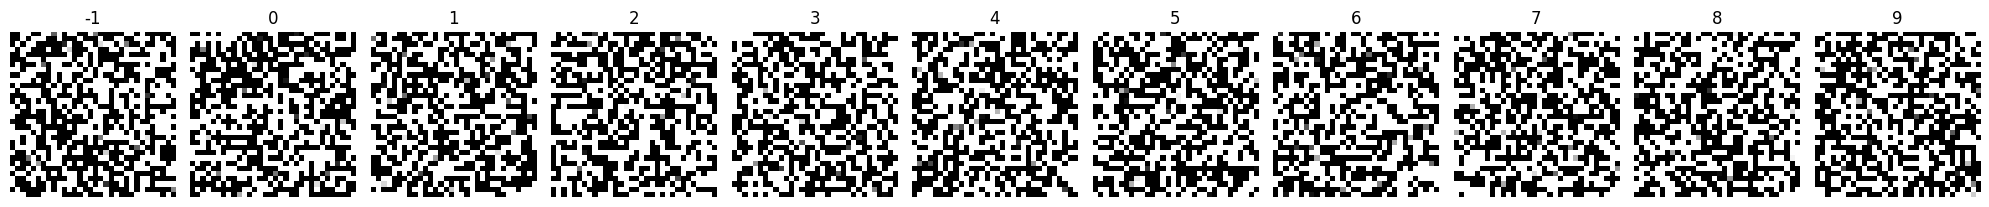

Epoch 2/200
468/468 [==============================] - 49s 103ms/step - noise_loss: 0.0461 - val_loss: 0.9447 - val_noise_loss: 0.9447 - val_image_loss: 34.1236 - learning_rate: 0.0050


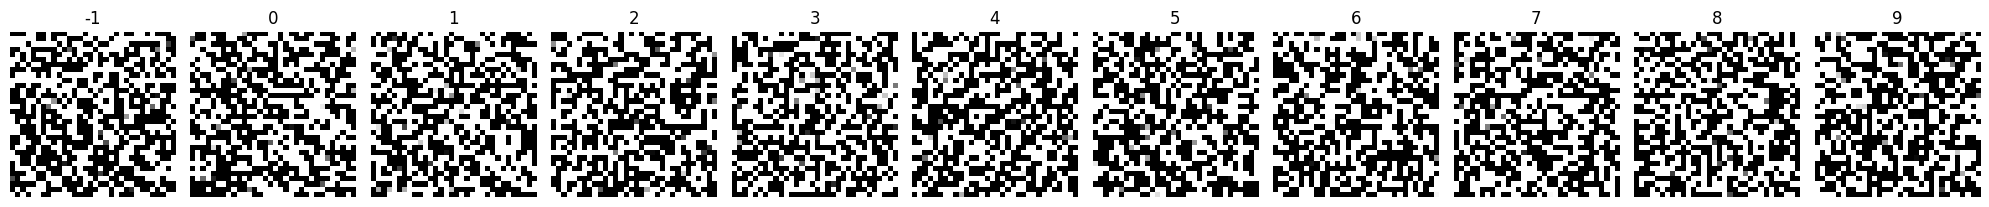

Epoch 3/200
468/468 [==============================] - 49s 104ms/step - noise_loss: 0.0353 - val_loss: 0.5041 - val_noise_loss: 0.5041 - val_image_loss: 19.5454 - learning_rate: 0.0050


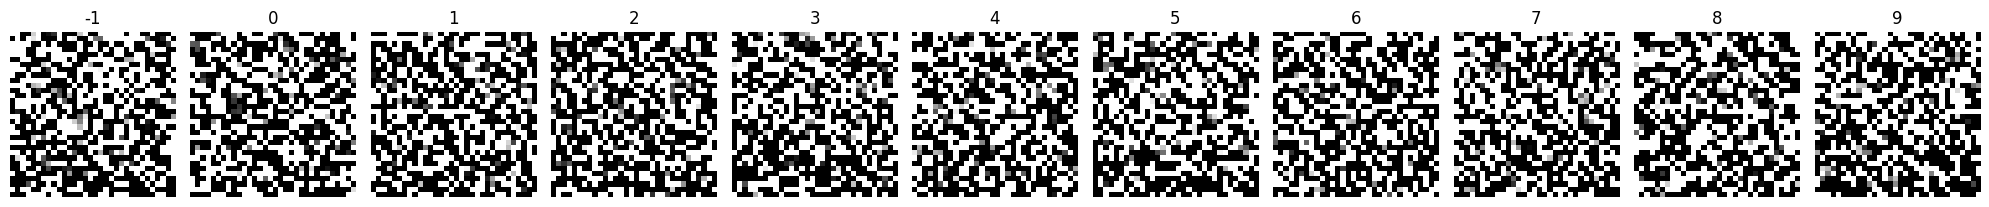

Epoch 4/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0318 - val_loss: 0.1943 - val_noise_loss: 0.1943 - val_image_loss: 5.8727 - learning_rate: 0.0050


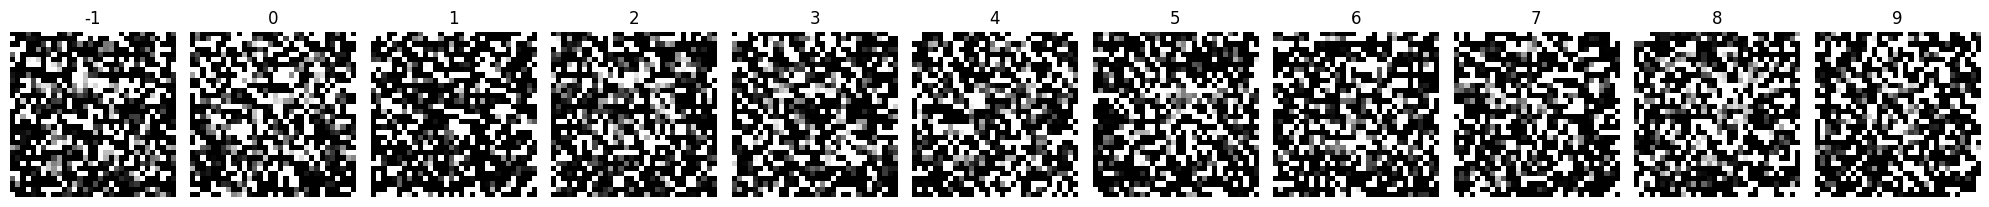

Epoch 5/200
468/468 [==============================] - 48s 103ms/step - noise_loss: 0.0297 - val_loss: 0.0917 - val_noise_loss: 0.0917 - val_image_loss: 1.7602 - learning_rate: 0.0050


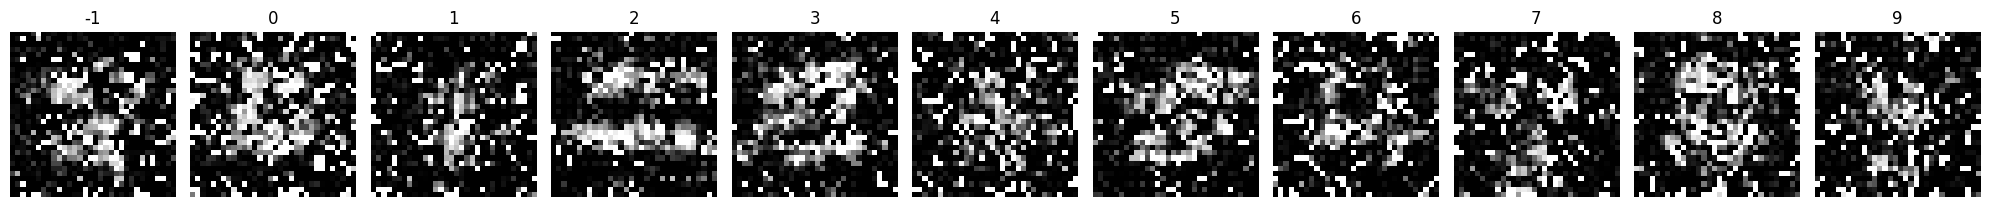

Epoch 6/200
468/468 [==============================] - 49s 104ms/step - noise_loss: 0.0285 - val_loss: 0.0564 - val_noise_loss: 0.0564 - val_image_loss: 0.7112 - learning_rate: 0.0050


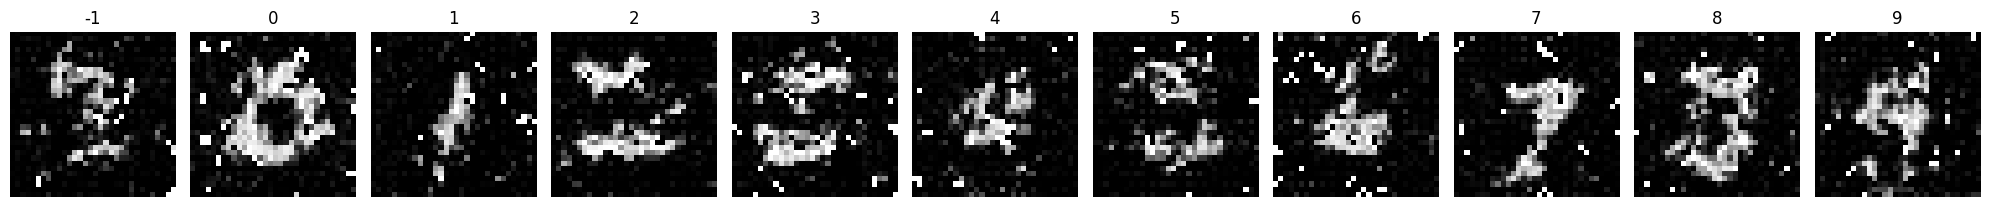

Epoch 7/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0274 - val_loss: 0.0429 - val_noise_loss: 0.0429 - val_image_loss: 0.3568 - learning_rate: 0.0050


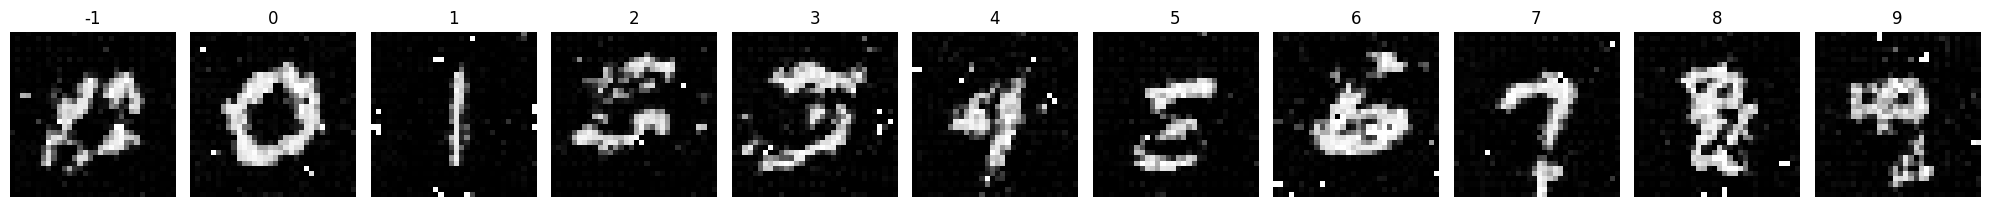

Epoch 8/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0269 - val_loss: 0.0380 - val_noise_loss: 0.0380 - val_image_loss: 0.2298 - learning_rate: 0.0050


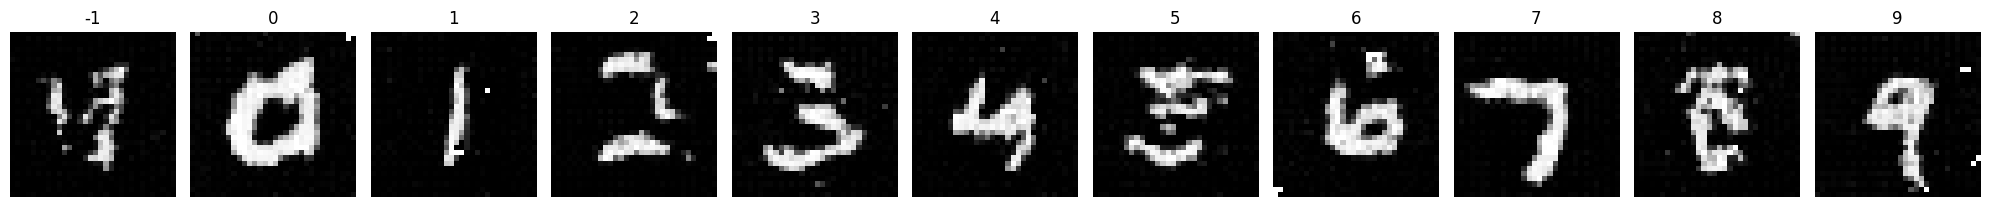

Epoch 9/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0264 - val_loss: 0.0363 - val_noise_loss: 0.0363 - val_image_loss: 0.1934 - learning_rate: 0.0050


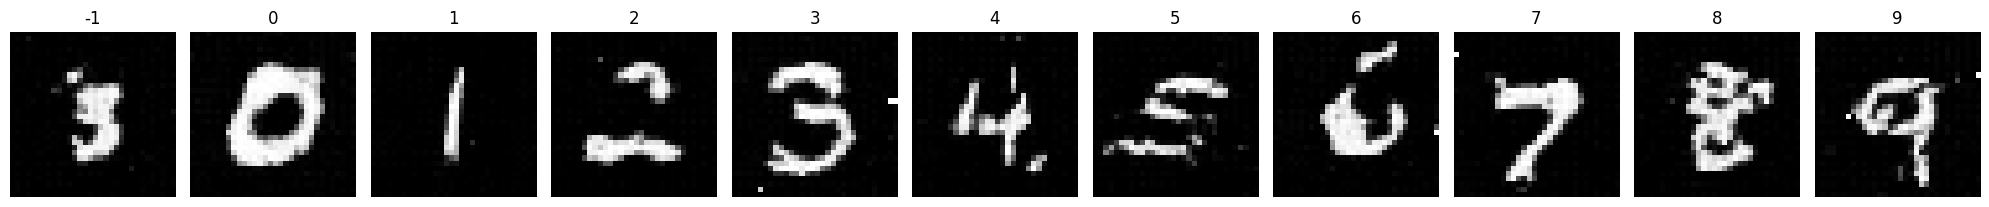

Epoch 10/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0260 - val_loss: 0.0363 - val_noise_loss: 0.0363 - val_image_loss: 0.1811 - learning_rate: 0.0050


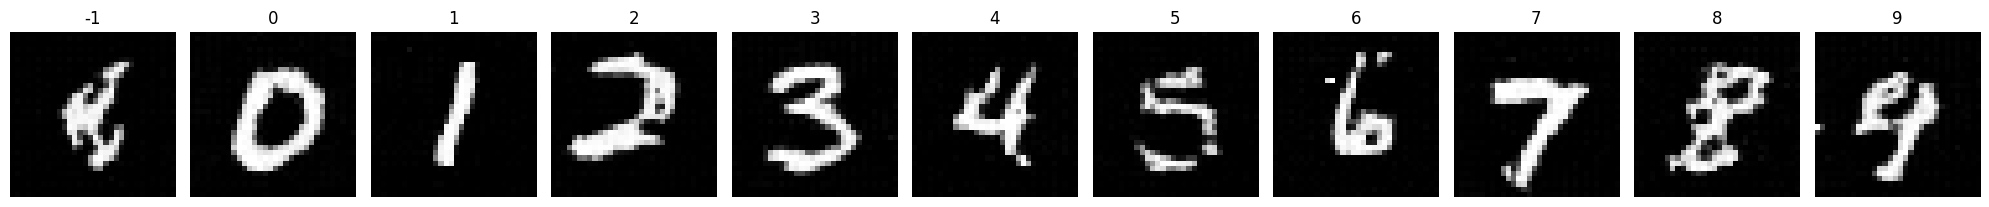

Epoch 11/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0258 - val_loss: 0.0369 - val_noise_loss: 0.0369 - val_image_loss: 0.1805 - learning_rate: 0.0050


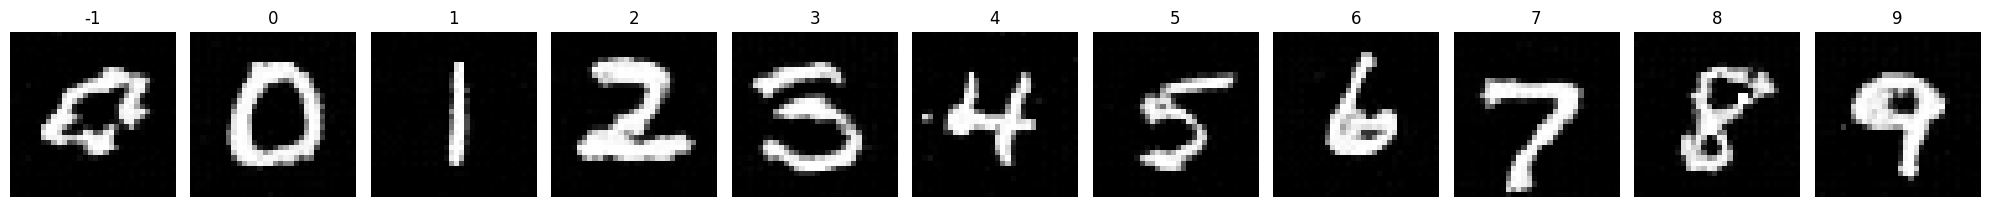

Epoch 12/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0255 - val_loss: 0.0384 - val_noise_loss: 0.0384 - val_image_loss: 0.1722 - learning_rate: 0.0050


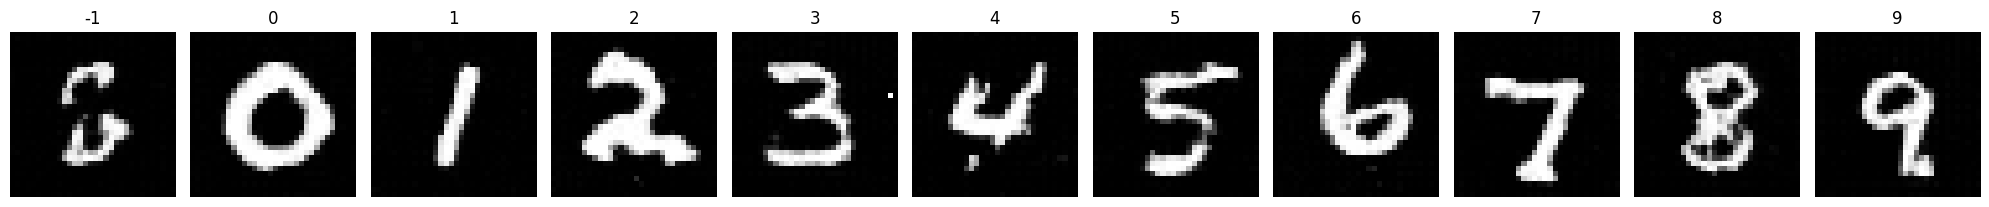

Epoch 13/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0253 - val_loss: 0.0382 - val_noise_loss: 0.0382 - val_image_loss: 0.1825 - learning_rate: 0.0049


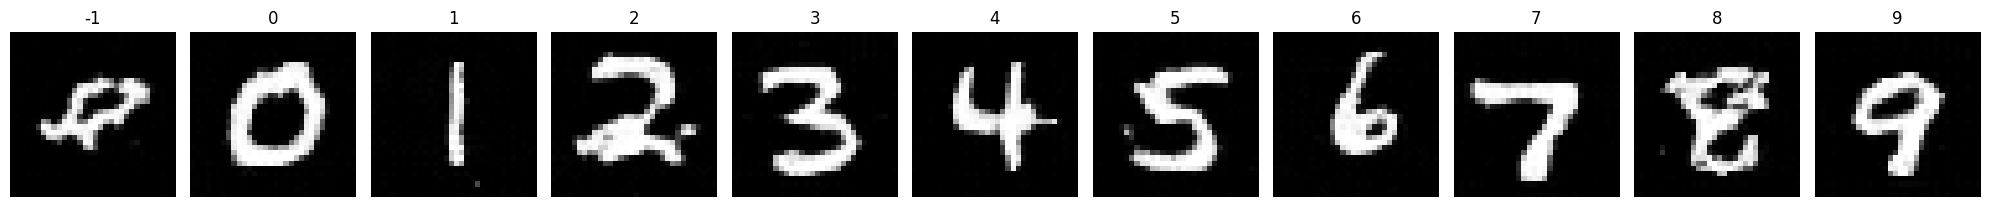

Epoch 14/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0249 - val_loss: 0.0388 - val_noise_loss: 0.0388 - val_image_loss: 0.1930 - learning_rate: 0.0049


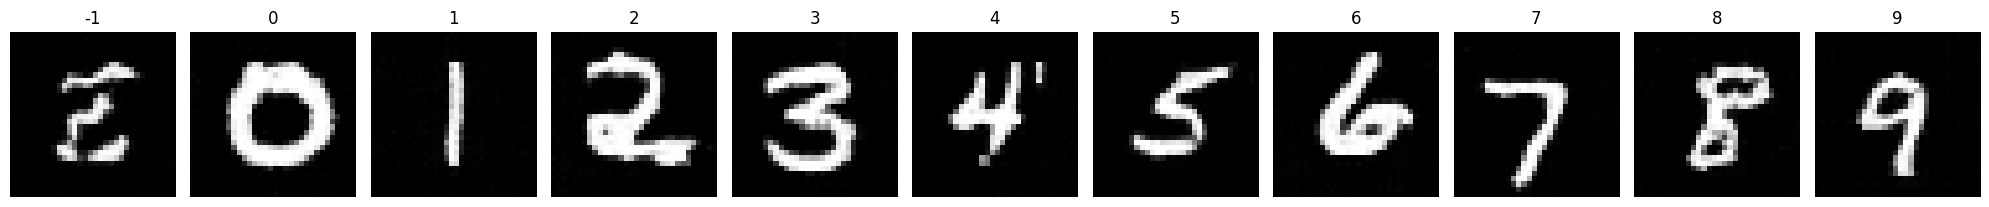

Epoch 15/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0248 - val_loss: 0.0386 - val_noise_loss: 0.0386 - val_image_loss: 0.1946 - learning_rate: 0.0049


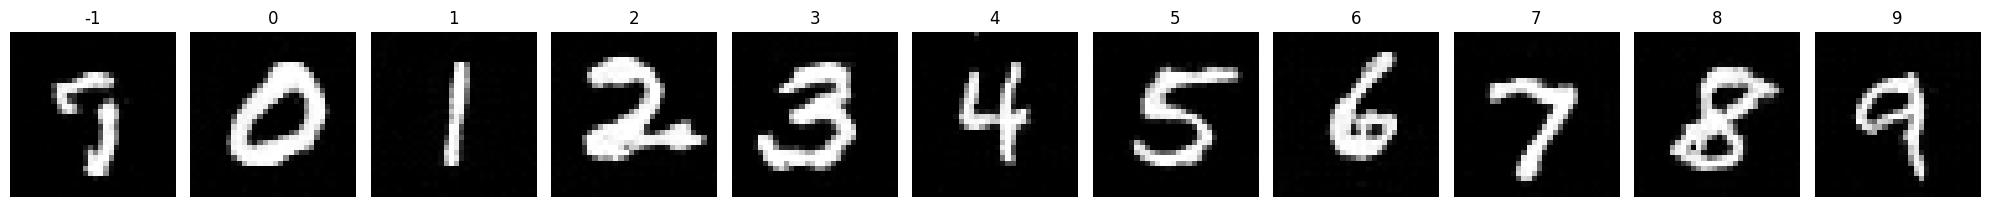

Epoch 16/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0246 - val_loss: 0.0387 - val_noise_loss: 0.0387 - val_image_loss: 0.1994 - learning_rate: 0.0049


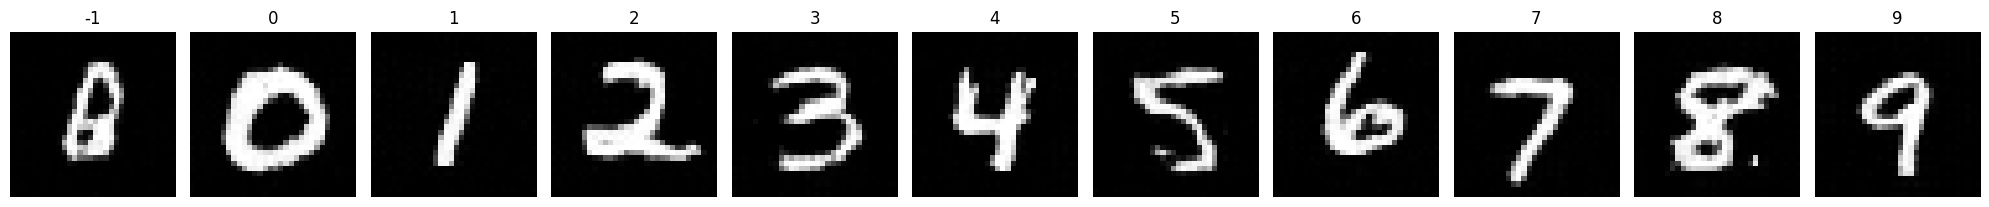

Epoch 17/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0245 - val_loss: 0.0385 - val_noise_loss: 0.0385 - val_image_loss: 0.1922 - learning_rate: 0.0049


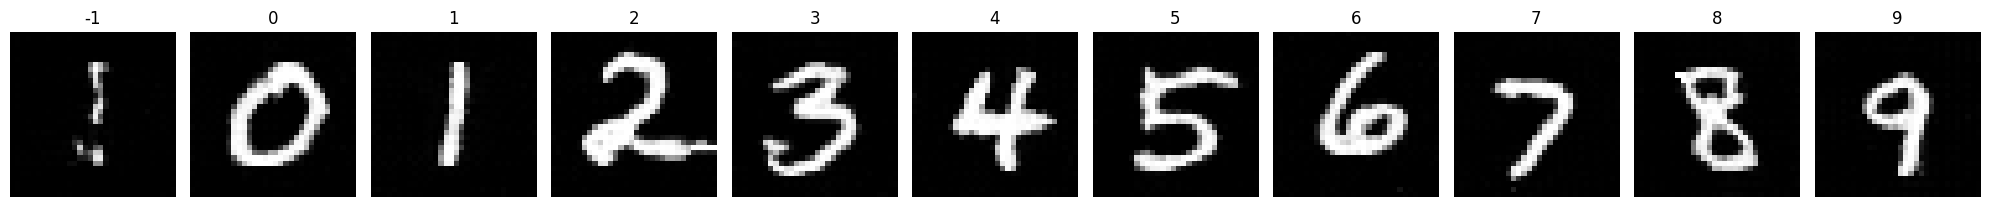

Epoch 18/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0242 - val_loss: 0.0382 - val_noise_loss: 0.0382 - val_image_loss: 0.1940 - learning_rate: 0.0049


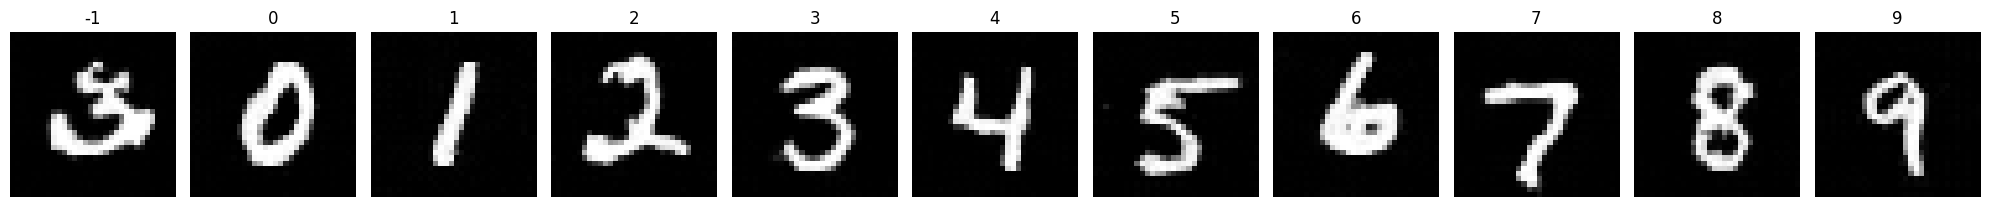

Epoch 19/200
468/468 [==============================] - 48s 103ms/step - noise_loss: 0.0243 - val_loss: 0.0384 - val_noise_loss: 0.0384 - val_image_loss: 0.1880 - learning_rate: 0.0049


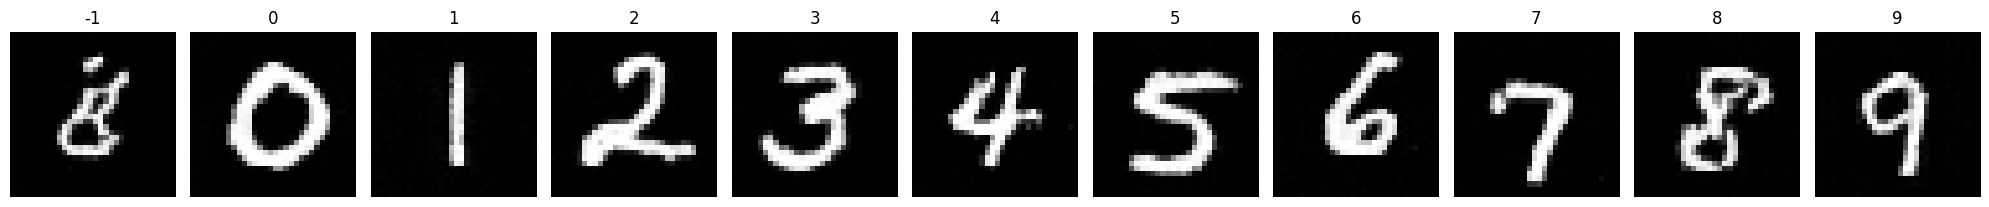

Epoch 20/200
468/468 [==============================] - 48s 103ms/step - noise_loss: 0.0398 - val_loss: 0.0444 - val_noise_loss: 0.0444 - val_image_loss: 0.3138 - learning_rate: 0.0049


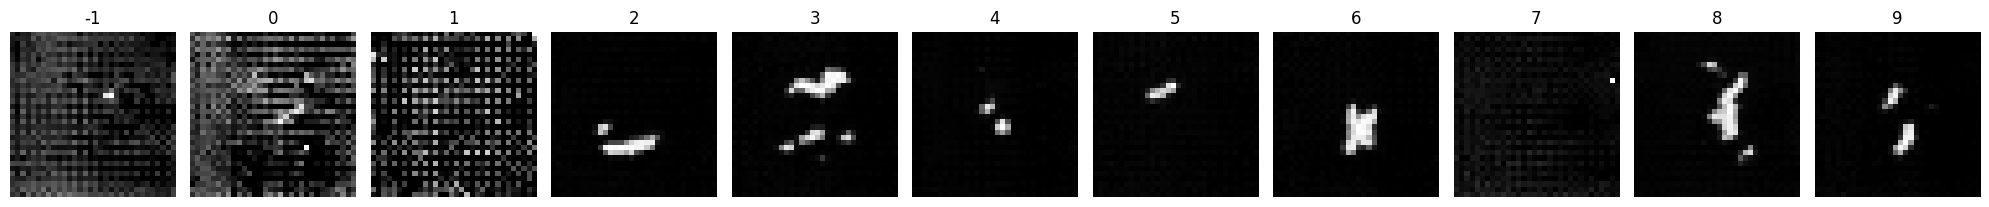

Epoch 21/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0288 - val_loss: 0.0415 - val_noise_loss: 0.0415 - val_image_loss: 0.2781 - learning_rate: 0.0049


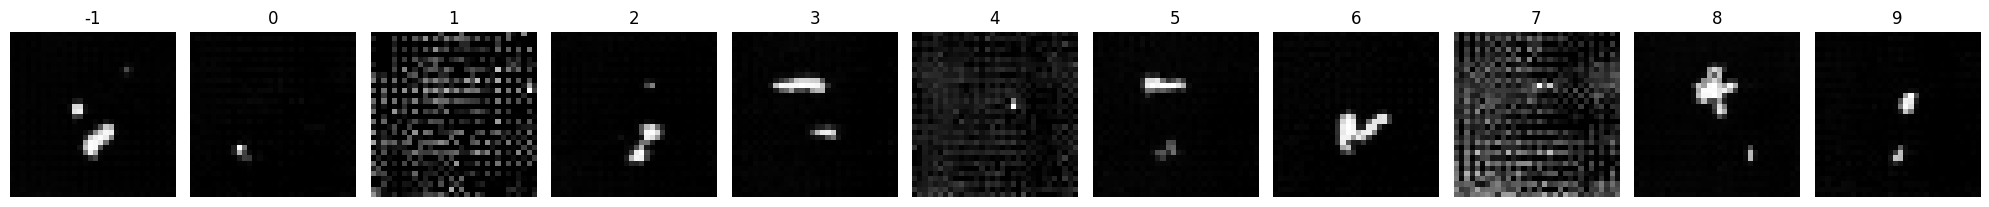

Epoch 22/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0273 - val_loss: 0.0369 - val_noise_loss: 0.0369 - val_image_loss: 0.2108 - learning_rate: 0.0049


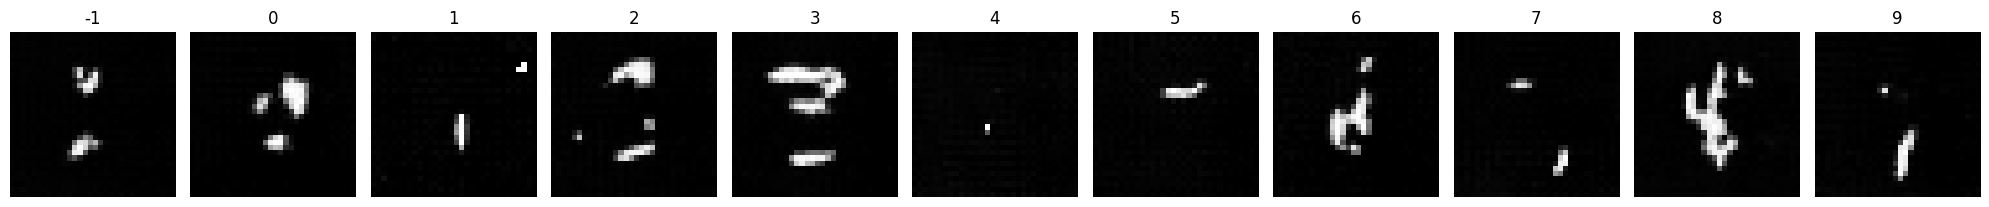

Epoch 23/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0269 - val_loss: 0.0357 - val_noise_loss: 0.0357 - val_image_loss: 0.1740 - learning_rate: 0.0048


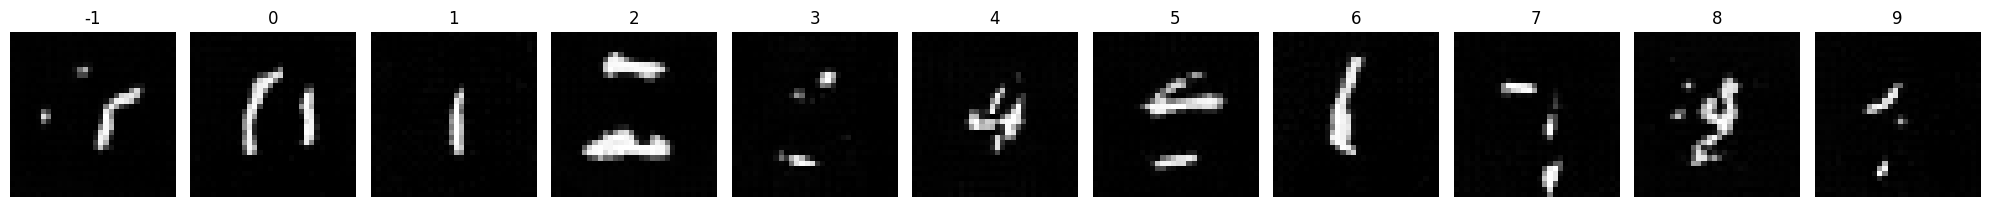

Epoch 24/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0266 - val_loss: 0.0359 - val_noise_loss: 0.0359 - val_image_loss: 0.1642 - learning_rate: 0.0048


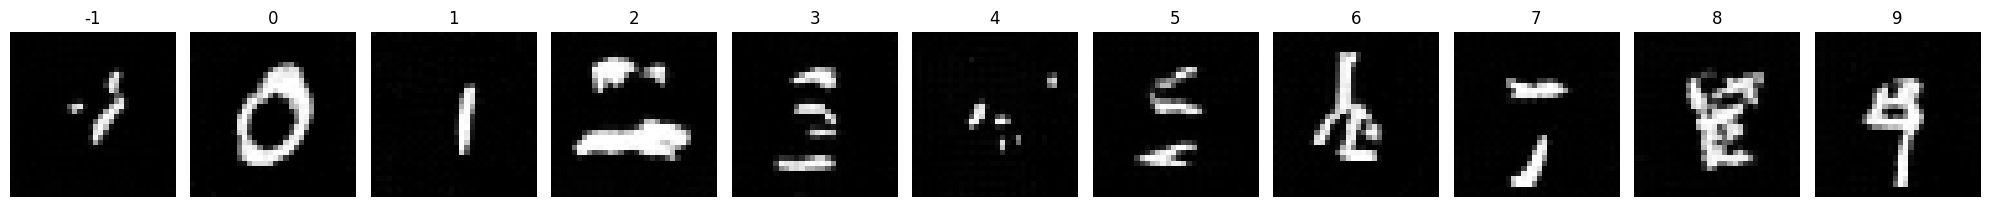

Epoch 25/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0264 - val_loss: 0.0374 - val_noise_loss: 0.0374 - val_image_loss: 0.1605 - learning_rate: 0.0048


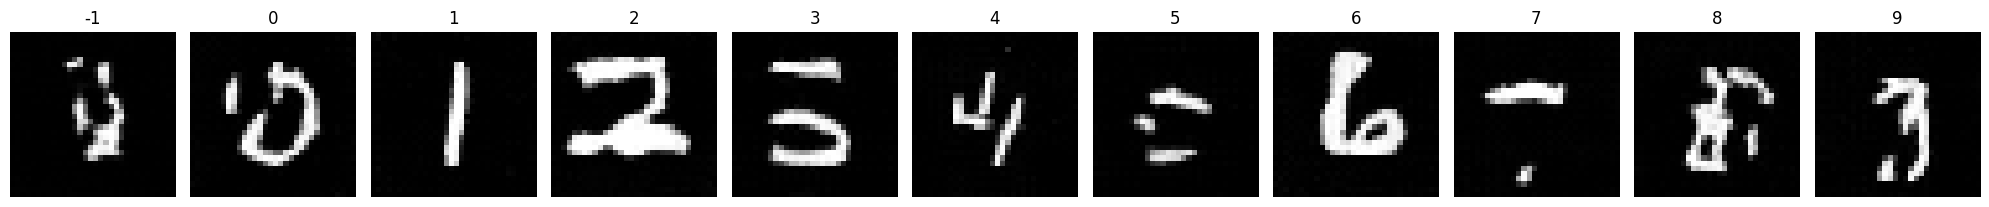

Epoch 26/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0262 - val_loss: 0.0389 - val_noise_loss: 0.0389 - val_image_loss: 0.1689 - learning_rate: 0.0048


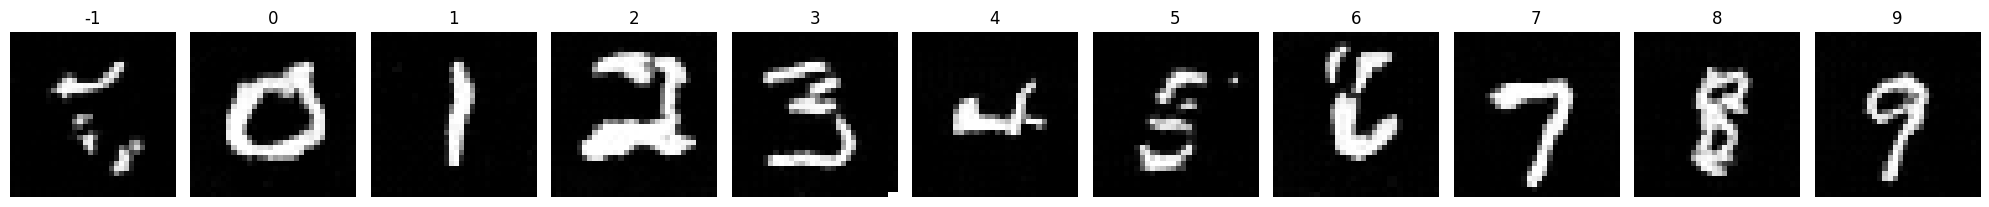

Epoch 27/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0260 - val_loss: 0.0409 - val_noise_loss: 0.0409 - val_image_loss: 0.1663 - learning_rate: 0.0048


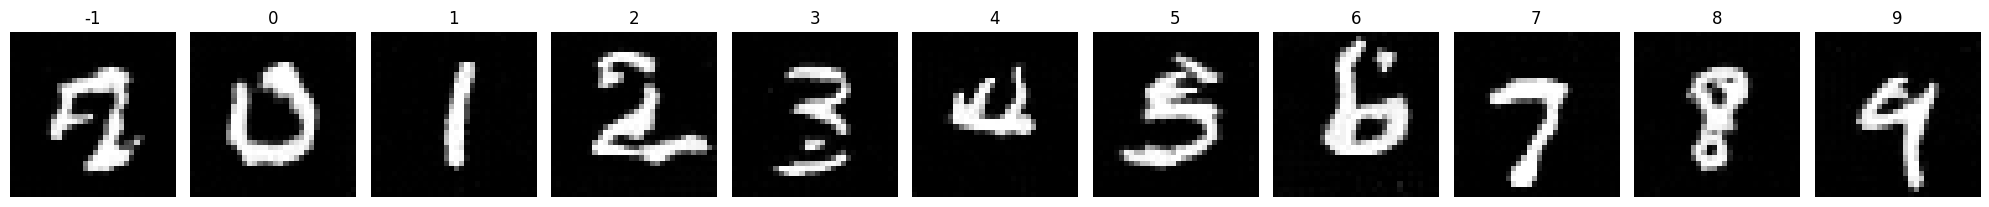

Epoch 28/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0258 - val_loss: 0.0420 - val_noise_loss: 0.0420 - val_image_loss: 0.1718 - learning_rate: 0.0048


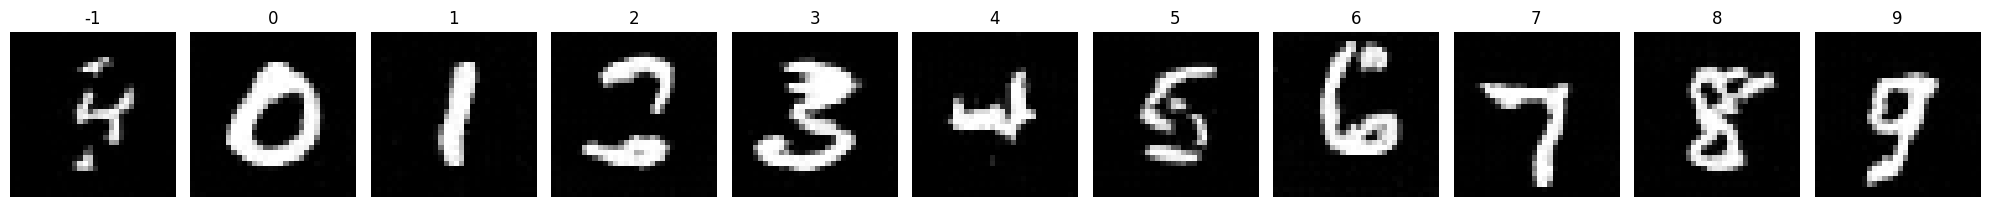

Epoch 29/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0256 - val_loss: 0.0422 - val_noise_loss: 0.0422 - val_image_loss: 0.1764 - learning_rate: 0.0047


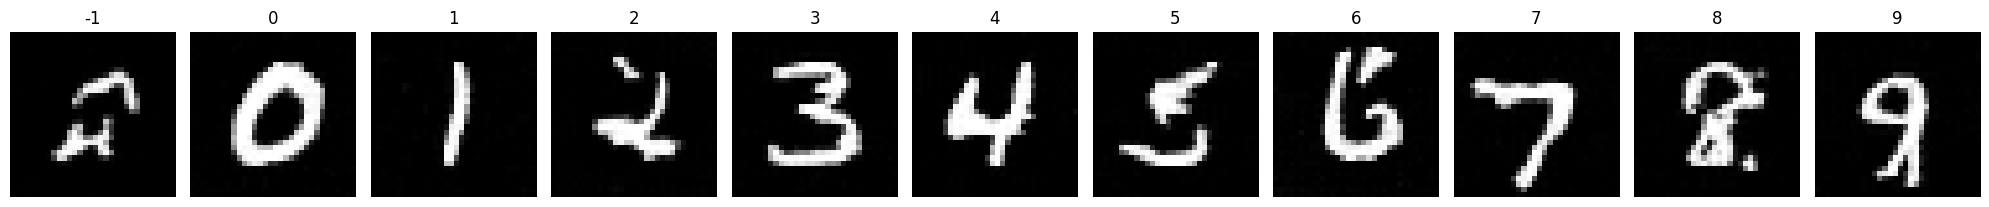

Epoch 30/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0254 - val_loss: 0.0429 - val_noise_loss: 0.0429 - val_image_loss: 0.1730 - learning_rate: 0.0047


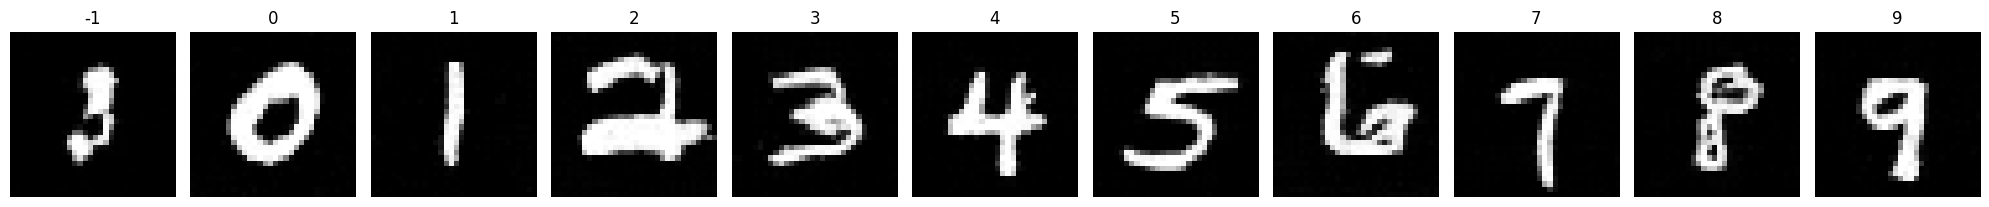

Epoch 31/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0252 - val_loss: 0.0432 - val_noise_loss: 0.0432 - val_image_loss: 0.1801 - learning_rate: 0.0047


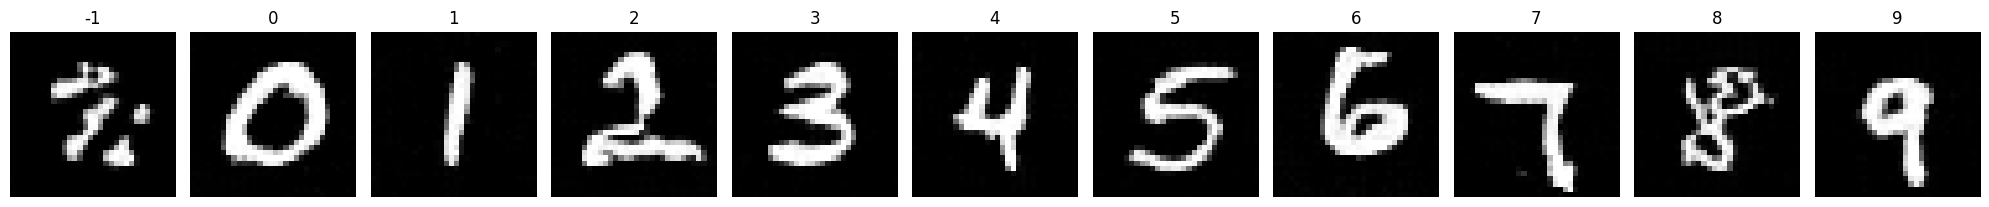

Epoch 32/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0248 - val_loss: 0.0433 - val_noise_loss: 0.0433 - val_image_loss: 0.1797 - learning_rate: 0.0047


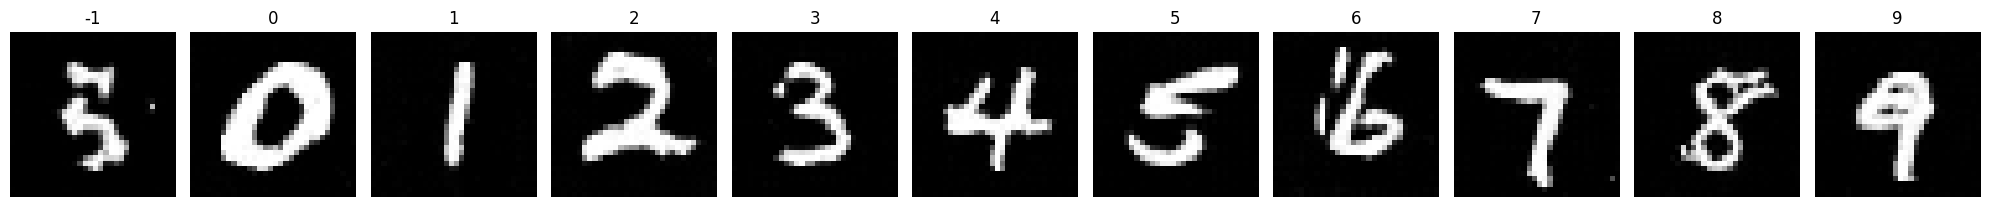

Epoch 33/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0249 - val_loss: 0.0430 - val_noise_loss: 0.0430 - val_image_loss: 0.1842 - learning_rate: 0.0047


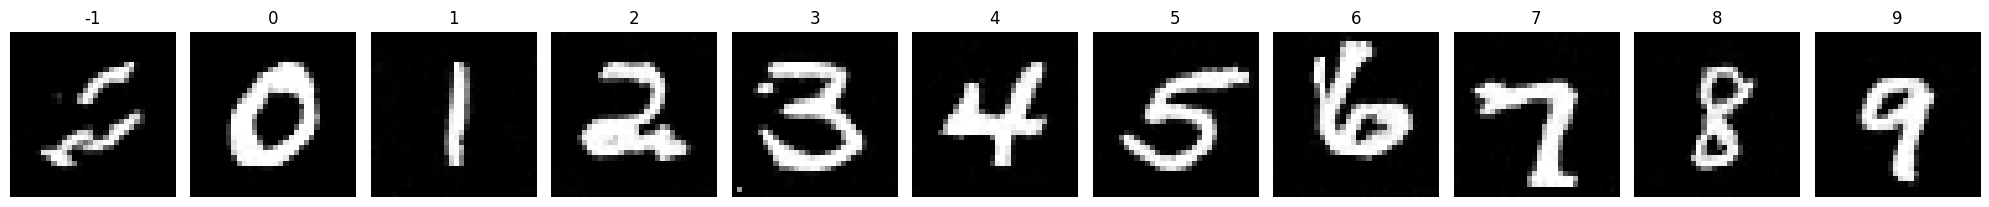

Epoch 34/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0249 - val_loss: 0.0431 - val_noise_loss: 0.0431 - val_image_loss: 0.1803 - learning_rate: 0.0047


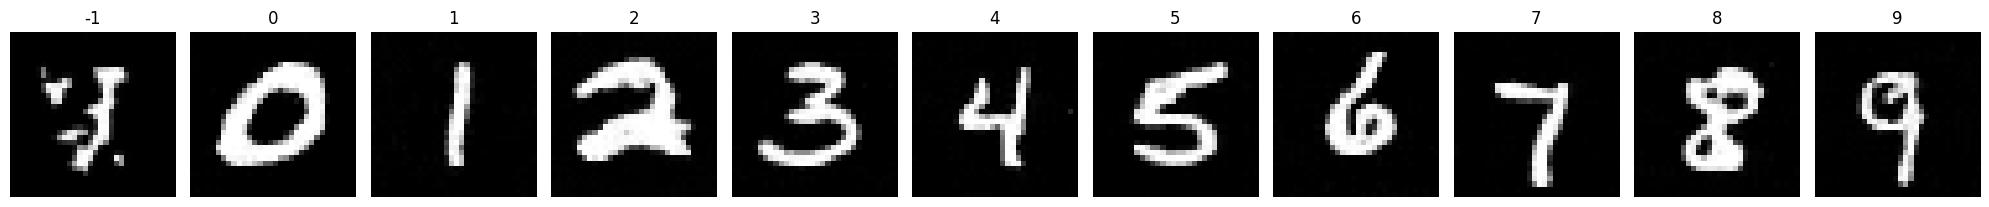

Epoch 35/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0246 - val_loss: 0.0430 - val_noise_loss: 0.0430 - val_image_loss: 0.1810 - learning_rate: 0.0046


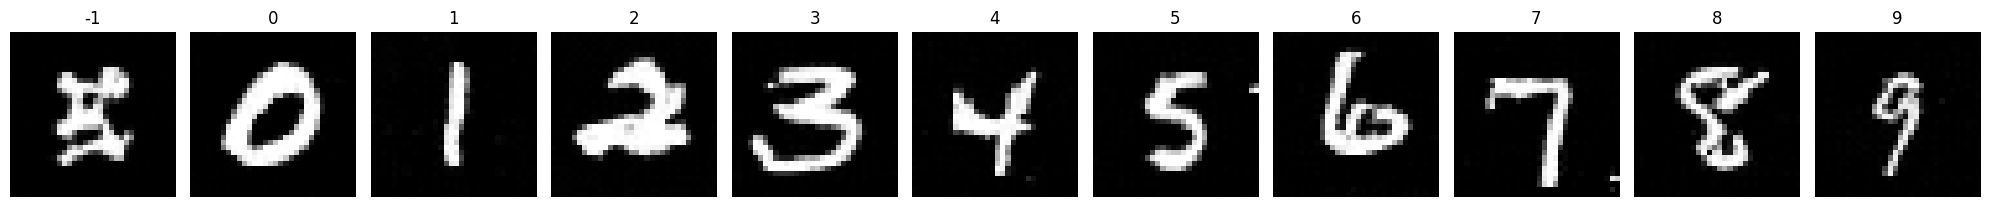

Epoch 36/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0246 - val_loss: 0.0436 - val_noise_loss: 0.0436 - val_image_loss: 0.1777 - learning_rate: 0.0046


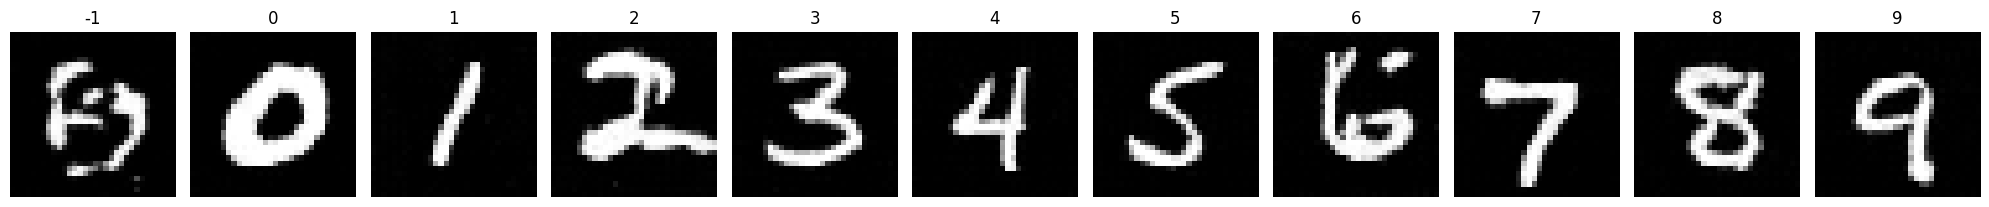

Epoch 37/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0244 - val_loss: 0.0425 - val_noise_loss: 0.0425 - val_image_loss: 0.1858 - learning_rate: 0.0046


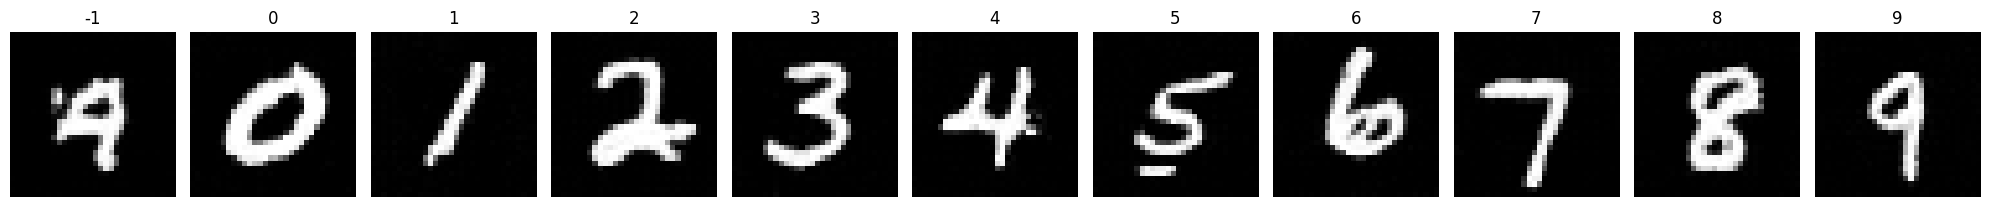

Epoch 38/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0243 - val_loss: 0.0427 - val_noise_loss: 0.0427 - val_image_loss: 0.1825 - learning_rate: 0.0046


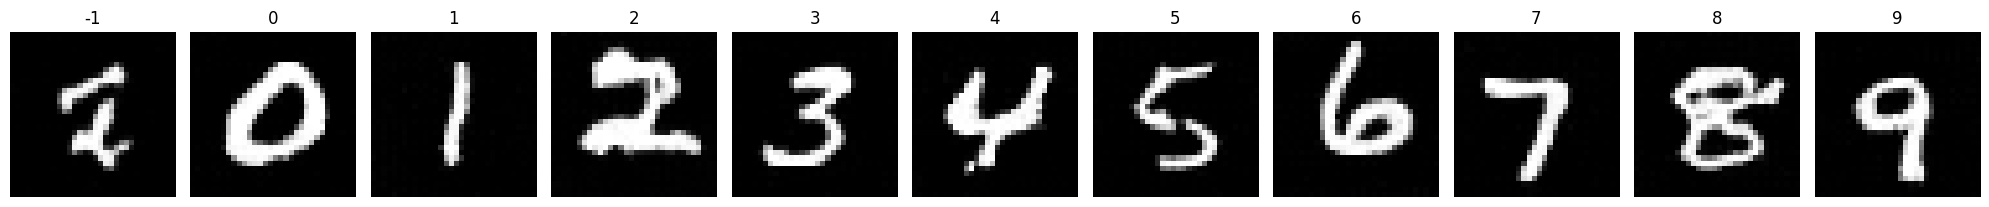

Epoch 39/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0242 - val_loss: 0.0421 - val_noise_loss: 0.0421 - val_image_loss: 0.1826 - learning_rate: 0.0045


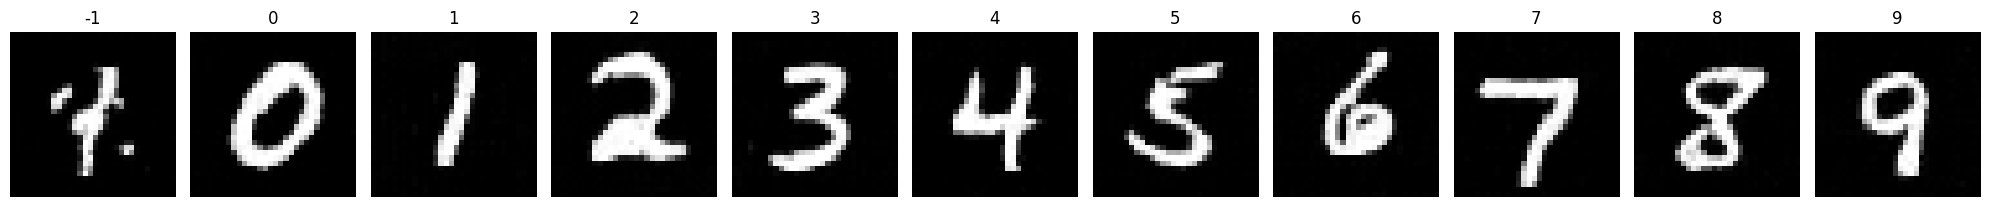

Epoch 40/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0241 - val_loss: 0.0418 - val_noise_loss: 0.0418 - val_image_loss: 0.1838 - learning_rate: 0.0045


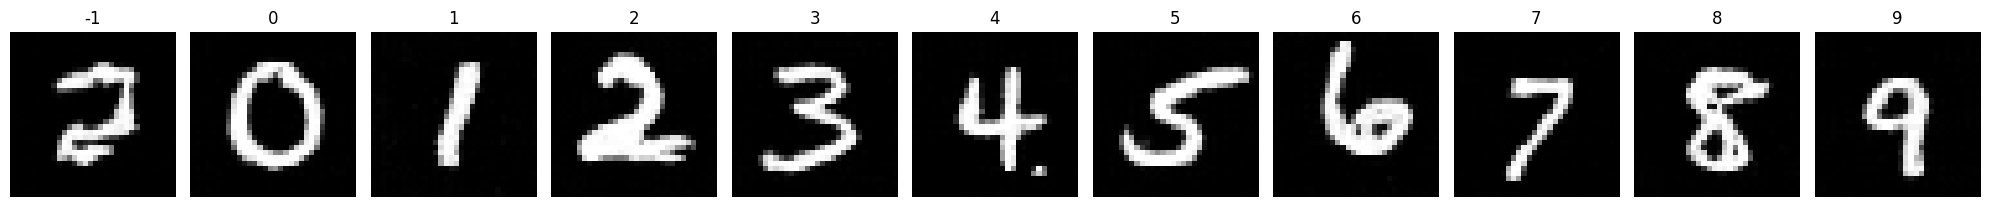

Epoch 41/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0239 - val_loss: 0.0418 - val_noise_loss: 0.0418 - val_image_loss: 0.1816 - learning_rate: 0.0045


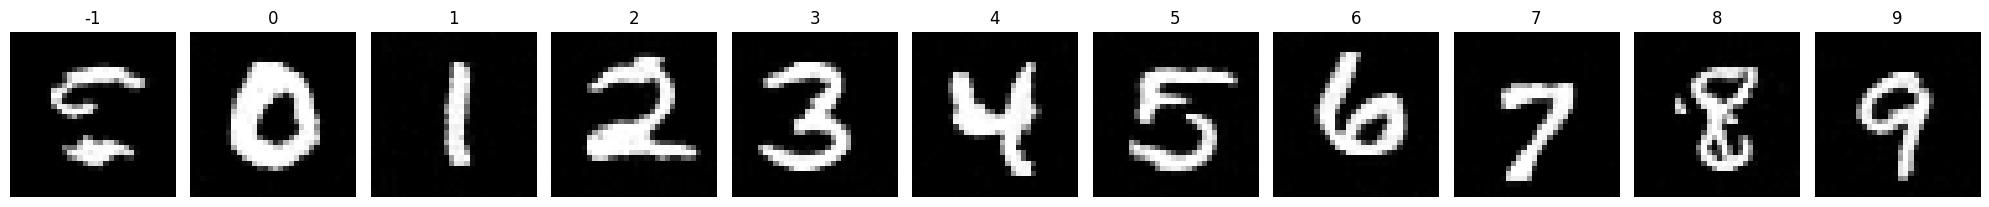

Epoch 42/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0239 - val_loss: 0.0416 - val_noise_loss: 0.0416 - val_image_loss: 0.1775 - learning_rate: 0.0045


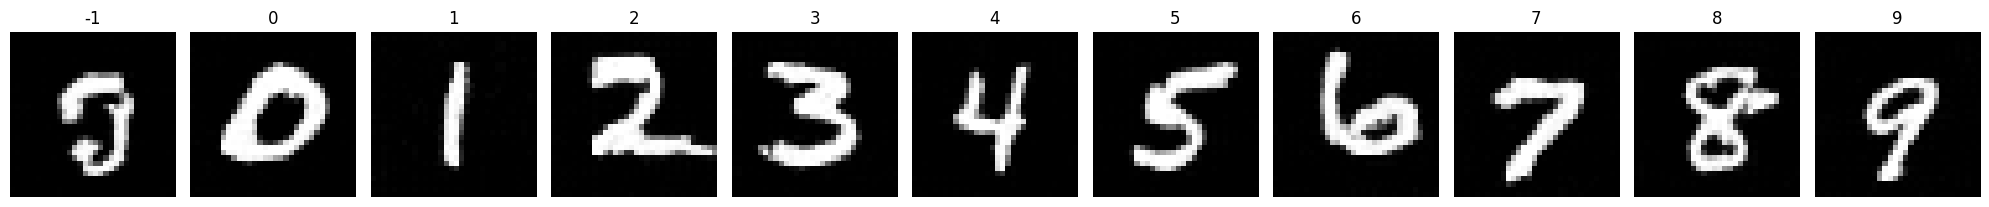

Epoch 43/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0237 - val_loss: 0.0408 - val_noise_loss: 0.0408 - val_image_loss: 0.1815 - learning_rate: 0.0045


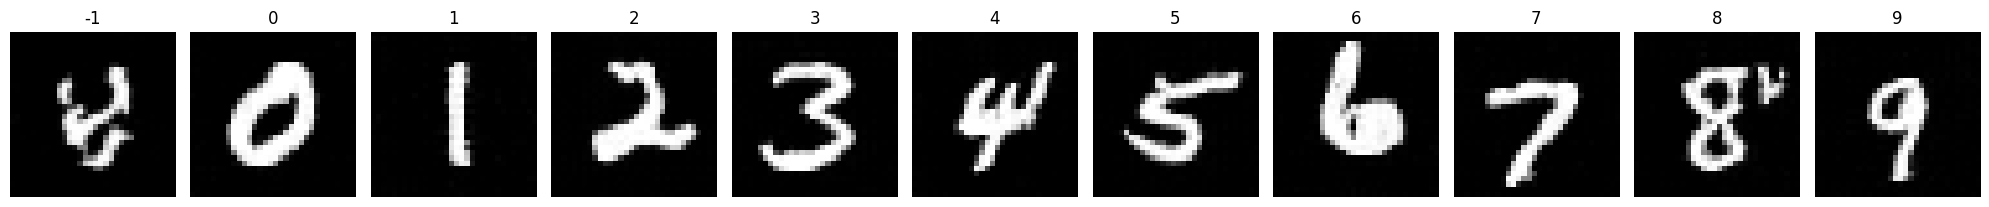

Epoch 44/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0237 - val_loss: 0.0409 - val_noise_loss: 0.0409 - val_image_loss: 0.1773 - learning_rate: 0.0044


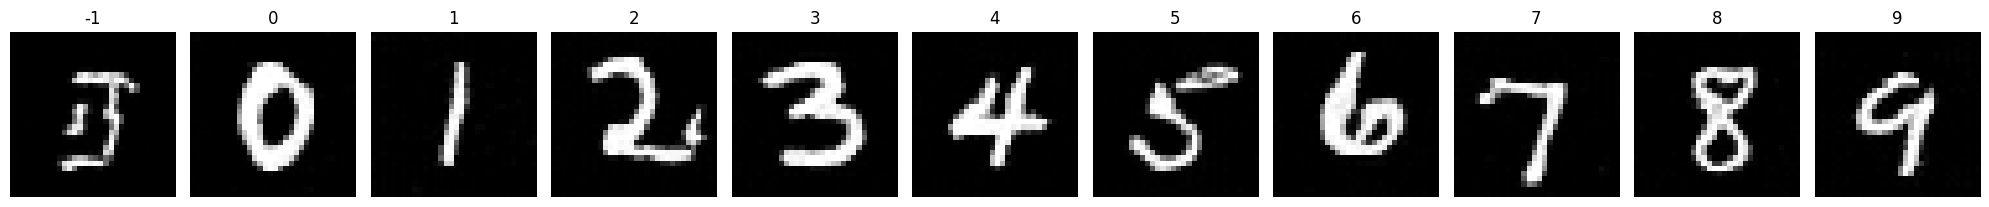

Epoch 45/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0237 - val_loss: 0.0405 - val_noise_loss: 0.0405 - val_image_loss: 0.1769 - learning_rate: 0.0044


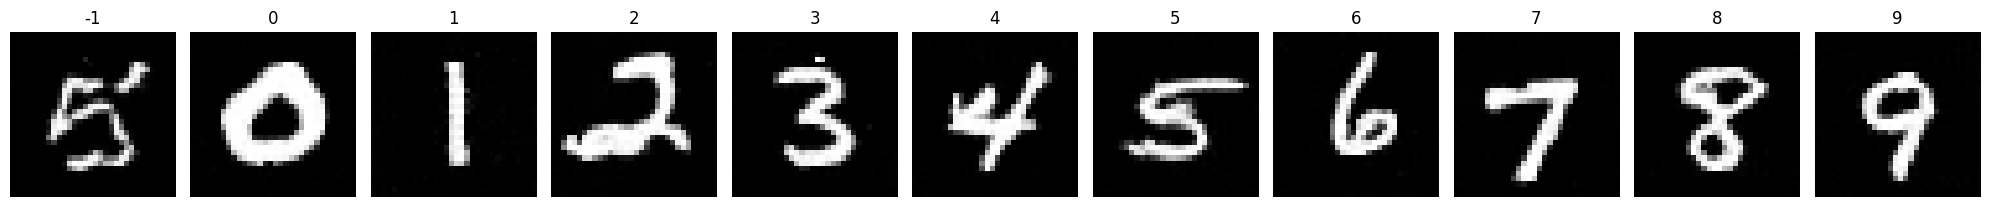

Epoch 46/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0236 - val_loss: 0.0400 - val_noise_loss: 0.0400 - val_image_loss: 0.1780 - learning_rate: 0.0044


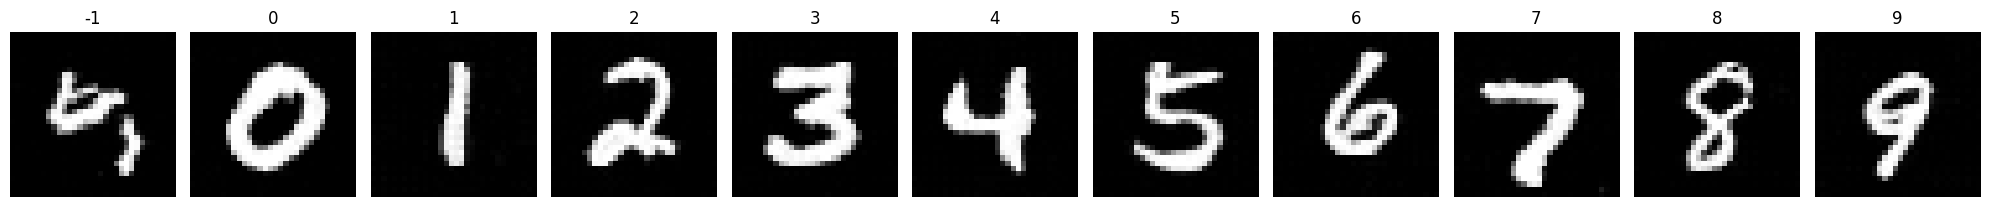

Epoch 47/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0237 - val_loss: 0.0395 - val_noise_loss: 0.0395 - val_image_loss: 0.1731 - learning_rate: 0.0043


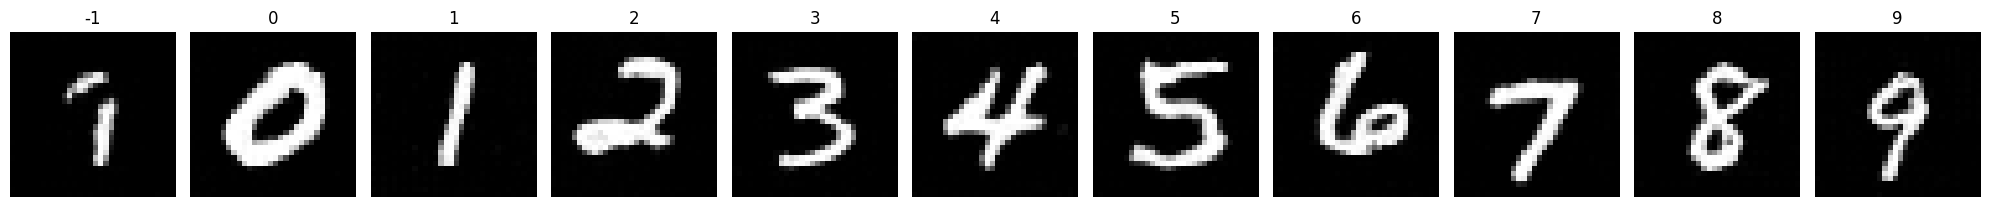

Epoch 48/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0235 - val_loss: 0.0392 - val_noise_loss: 0.0392 - val_image_loss: 0.1777 - learning_rate: 0.0043


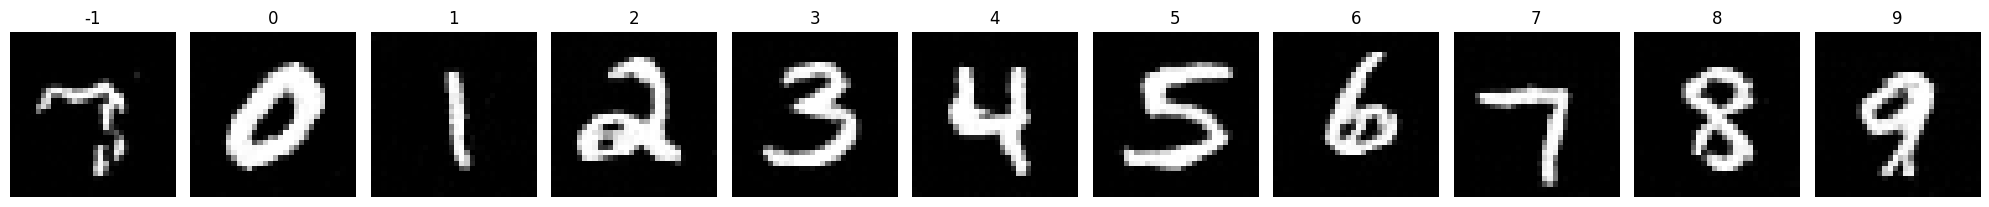

Epoch 49/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0234 - val_loss: 0.0392 - val_noise_loss: 0.0392 - val_image_loss: 0.1724 - learning_rate: 0.0043


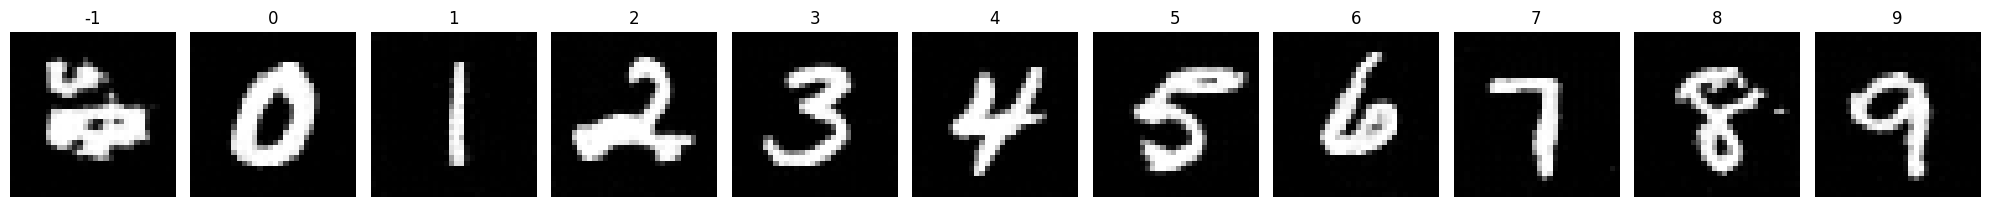

Epoch 50/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0233 - val_loss: 0.0392 - val_noise_loss: 0.0392 - val_image_loss: 0.1733 - learning_rate: 0.0043


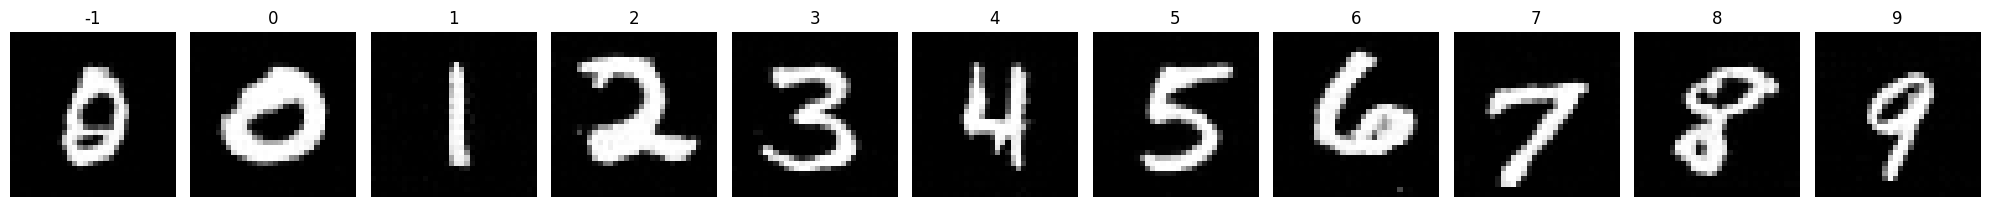

Epoch 51/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0233 - val_loss: 0.0383 - val_noise_loss: 0.0383 - val_image_loss: 0.1743 - learning_rate: 0.0042


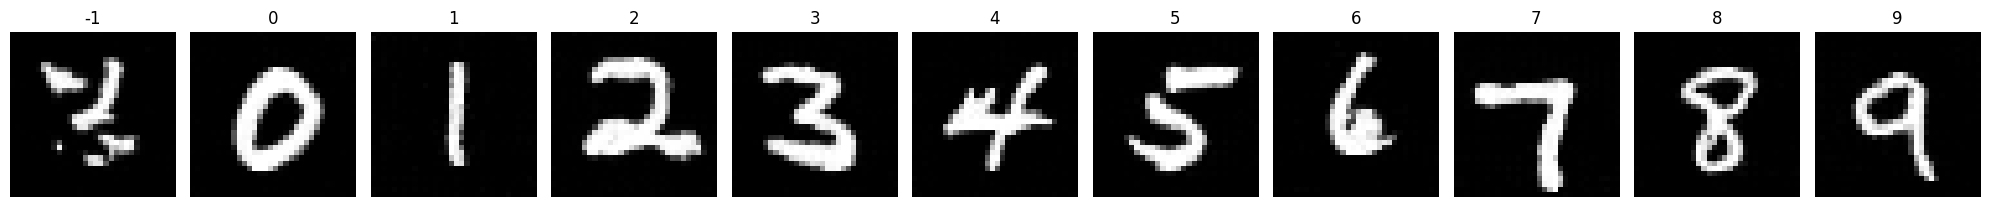

Epoch 52/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0231 - val_loss: 0.0382 - val_noise_loss: 0.0382 - val_image_loss: 0.1799 - learning_rate: 0.0042


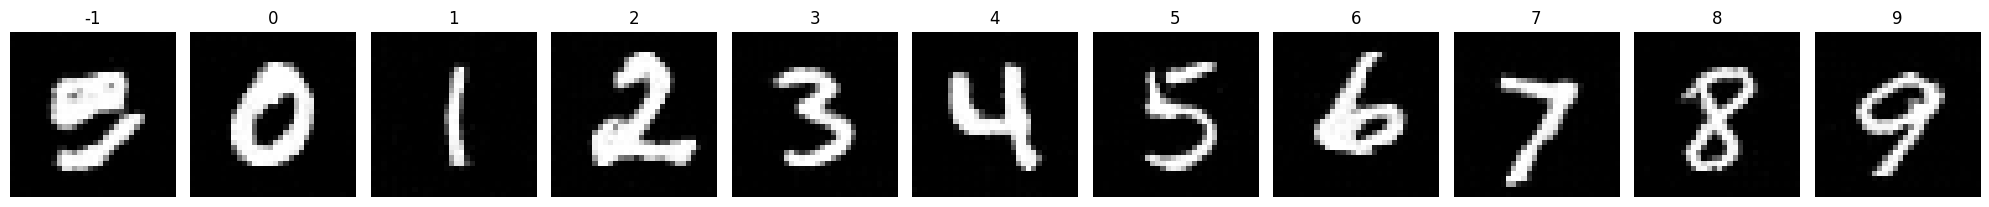

Epoch 53/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0232 - val_loss: 0.0383 - val_noise_loss: 0.0383 - val_image_loss: 0.1712 - learning_rate: 0.0042


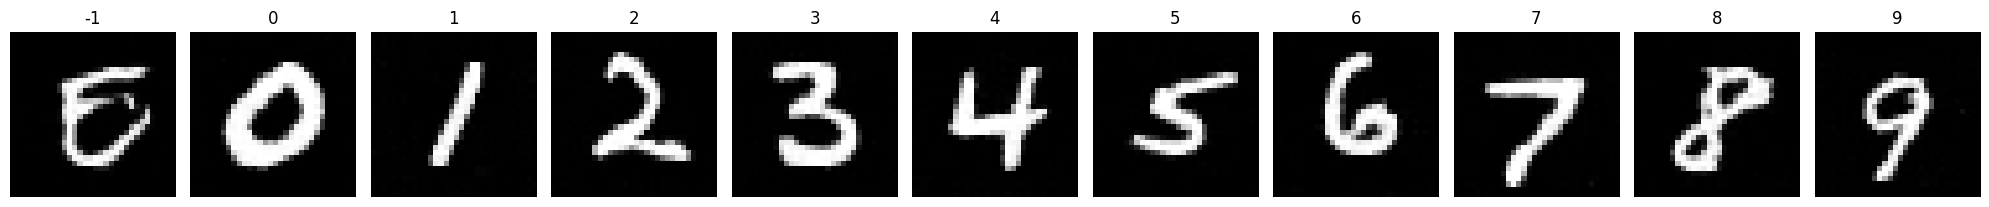

Epoch 54/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0231 - val_loss: 0.0376 - val_noise_loss: 0.0376 - val_image_loss: 0.1787 - learning_rate: 0.0042


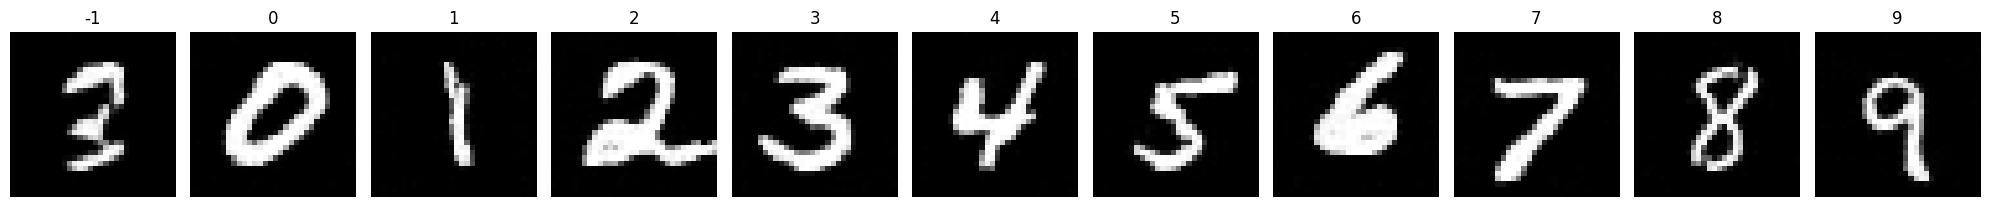

Epoch 55/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0229 - val_loss: 0.0377 - val_noise_loss: 0.0377 - val_image_loss: 0.1736 - learning_rate: 0.0041


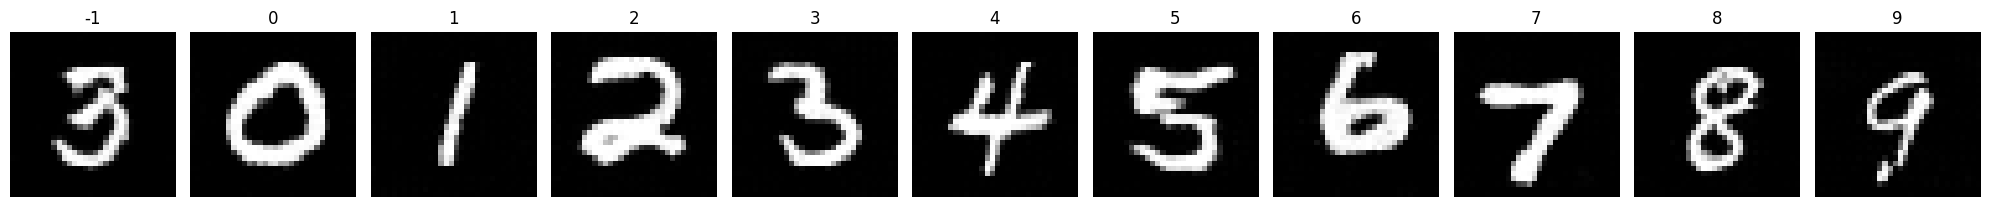

Epoch 56/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0229 - val_loss: 0.0375 - val_noise_loss: 0.0375 - val_image_loss: 0.1732 - learning_rate: 0.0041


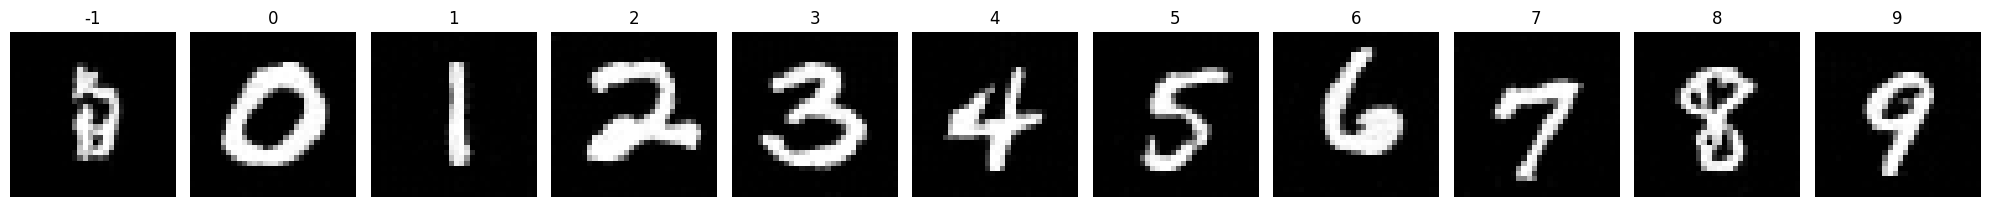

Epoch 57/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0229 - val_loss: 0.0370 - val_noise_loss: 0.0370 - val_image_loss: 0.1715 - learning_rate: 0.0041


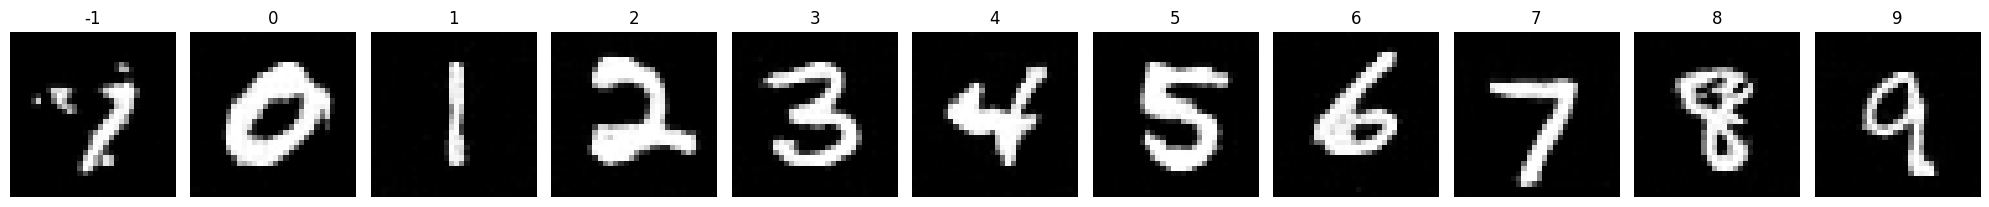

Epoch 58/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0228 - val_loss: 0.0370 - val_noise_loss: 0.0370 - val_image_loss: 0.1750 - learning_rate: 0.0040


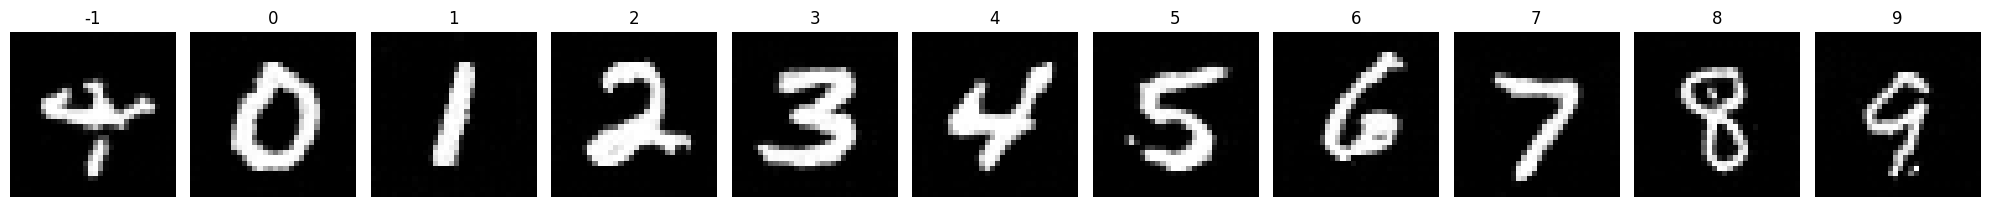

Epoch 59/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0227 - val_loss: 0.0369 - val_noise_loss: 0.0369 - val_image_loss: 0.1748 - learning_rate: 0.0040


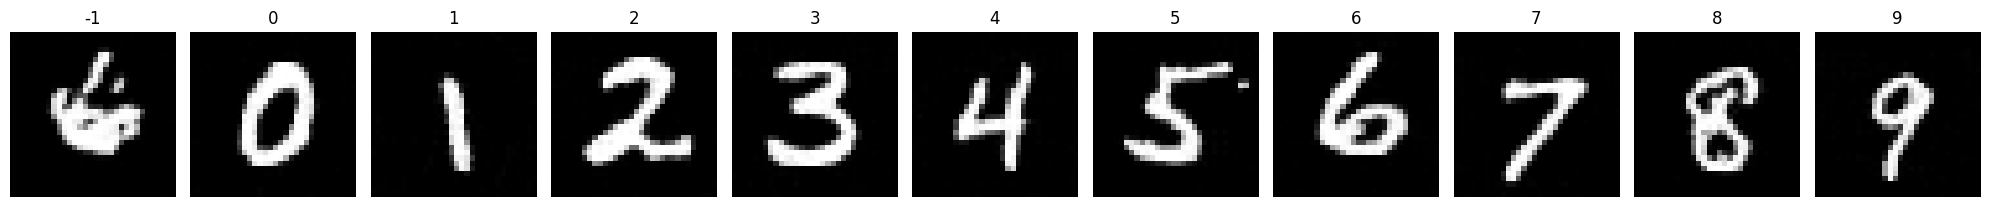

Epoch 60/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0228 - val_loss: 0.0365 - val_noise_loss: 0.0365 - val_image_loss: 0.1744 - learning_rate: 0.0040


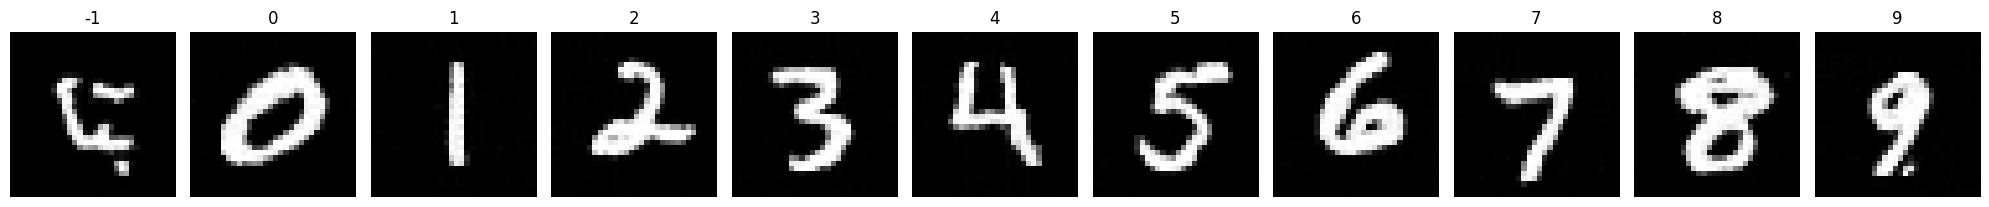

Epoch 61/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0226 - val_loss: 0.0365 - val_noise_loss: 0.0365 - val_image_loss: 0.1716 - learning_rate: 0.0039


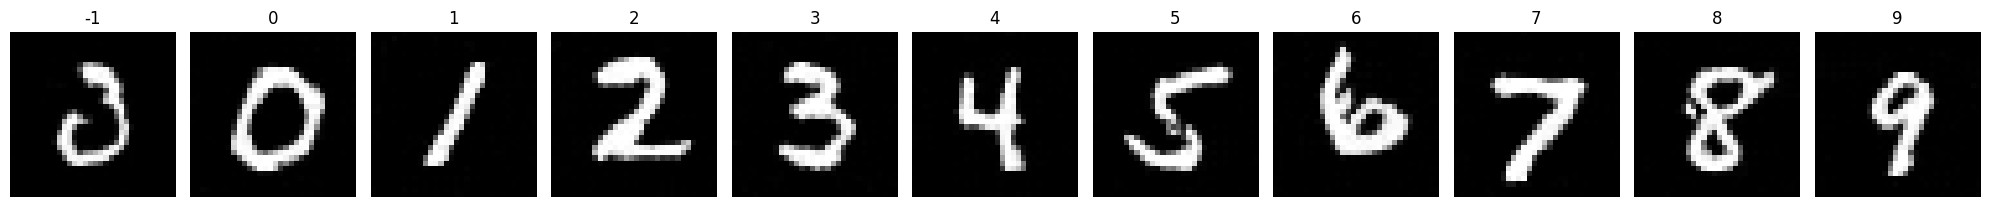

Epoch 62/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0226 - val_loss: 0.0365 - val_noise_loss: 0.0365 - val_image_loss: 0.1726 - learning_rate: 0.0039


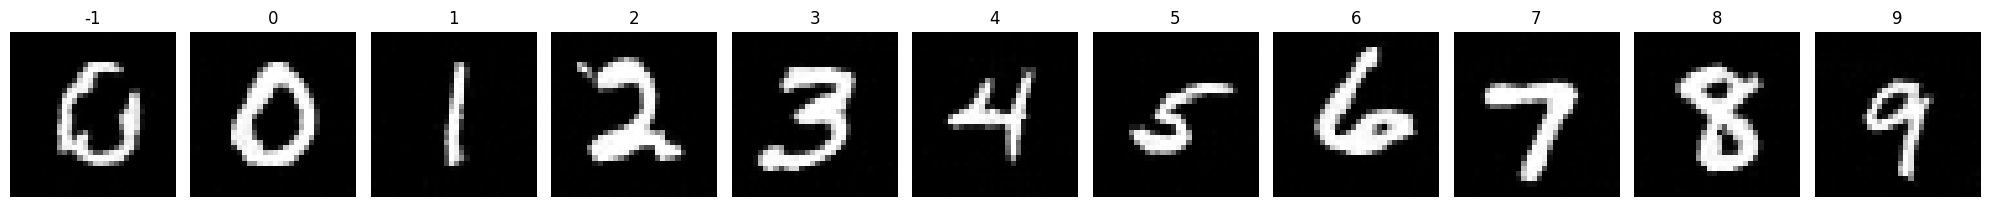

Epoch 63/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0226 - val_loss: 0.0366 - val_noise_loss: 0.0366 - val_image_loss: 0.1711 - learning_rate: 0.0039


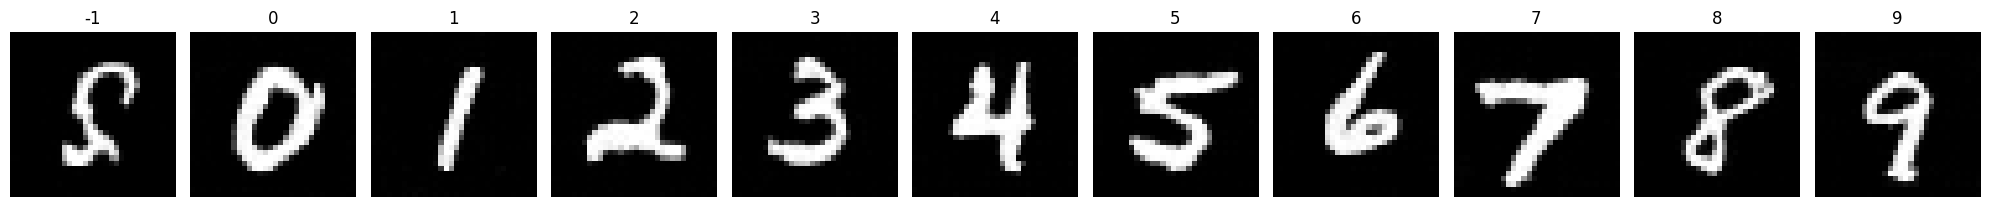

Epoch 64/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0224 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.1729 - learning_rate: 0.0038


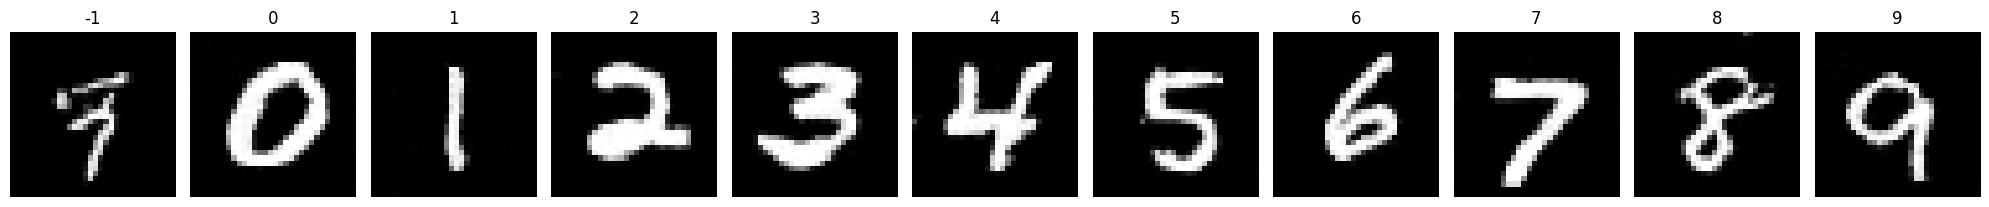

Epoch 65/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0224 - val_loss: 0.0360 - val_noise_loss: 0.0360 - val_image_loss: 0.1727 - learning_rate: 0.0038


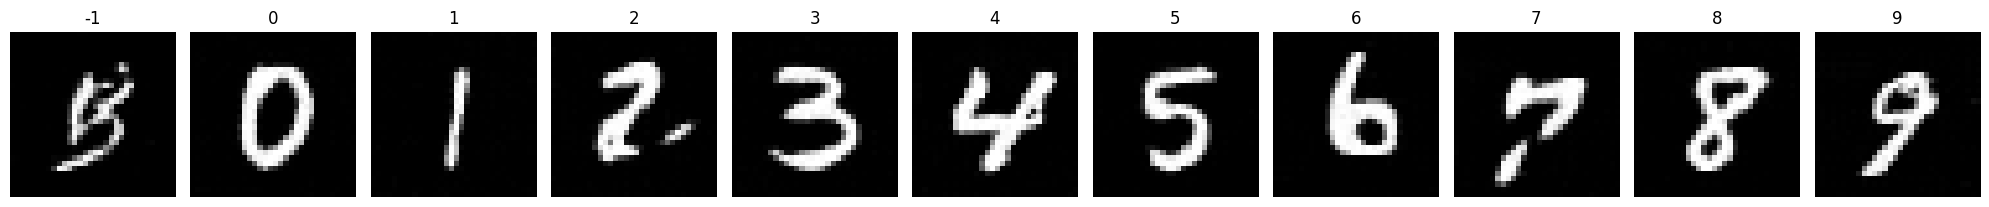

Epoch 66/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0225 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.1733 - learning_rate: 0.0038


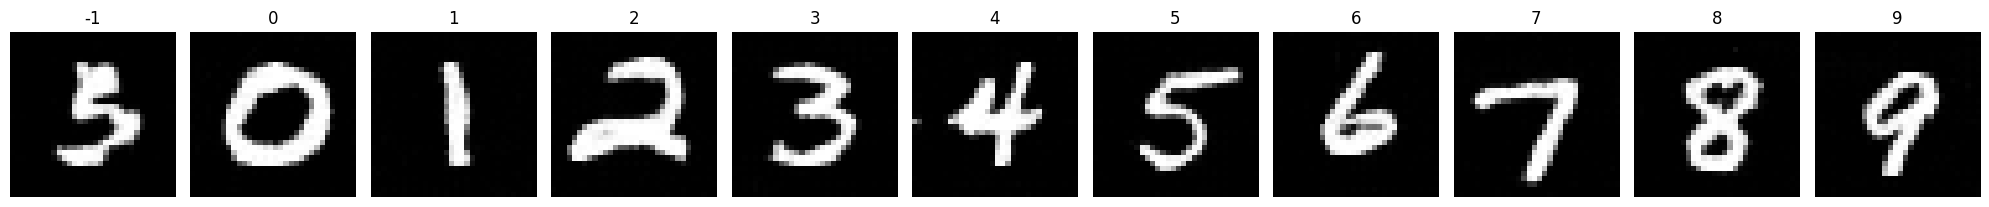

Epoch 67/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0223 - val_loss: 0.0361 - val_noise_loss: 0.0361 - val_image_loss: 0.1711 - learning_rate: 0.0037


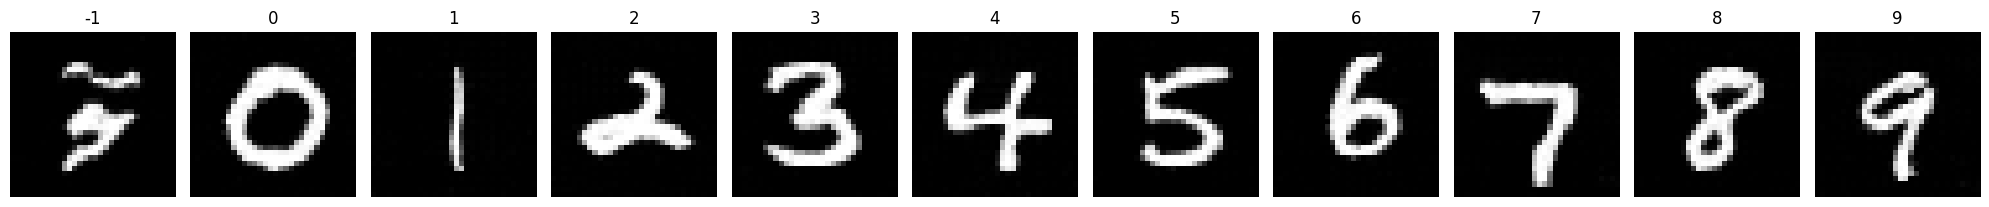

Epoch 68/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0224 - val_loss: 0.0357 - val_noise_loss: 0.0357 - val_image_loss: 0.1664 - learning_rate: 0.0037


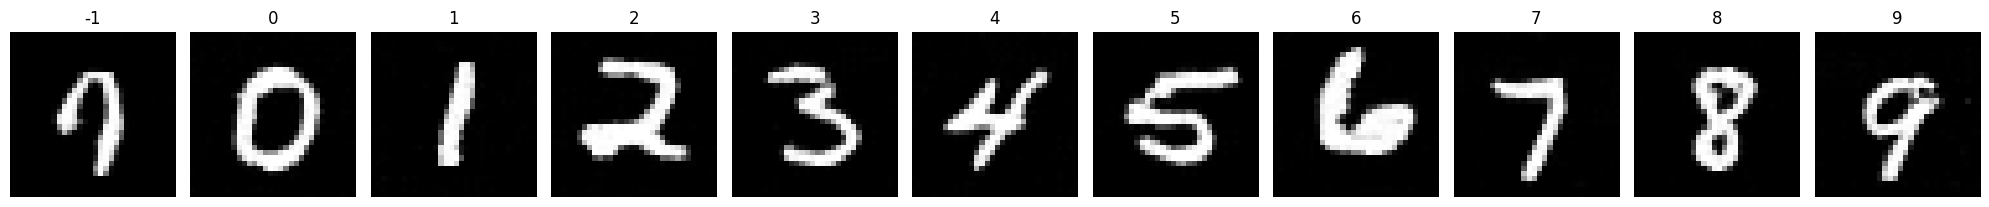

Epoch 69/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0223 - val_loss: 0.0360 - val_noise_loss: 0.0360 - val_image_loss: 0.1681 - learning_rate: 0.0037


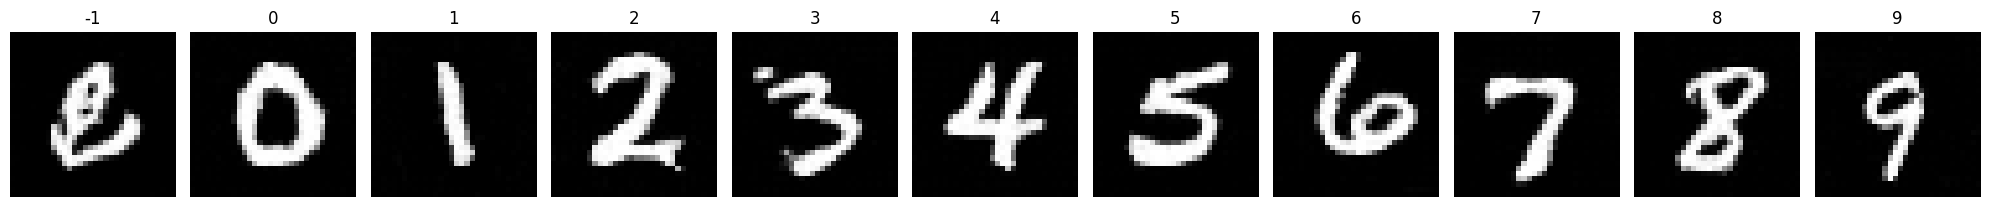

Epoch 70/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0223 - val_loss: 0.0359 - val_noise_loss: 0.0359 - val_image_loss: 0.1703 - learning_rate: 0.0036


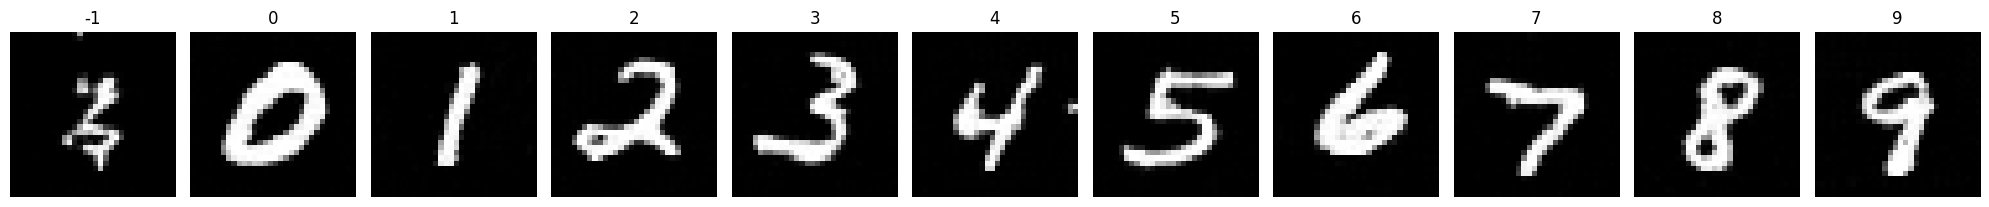

Epoch 71/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0223 - val_loss: 0.0358 - val_noise_loss: 0.0358 - val_image_loss: 0.1732 - learning_rate: 0.0036


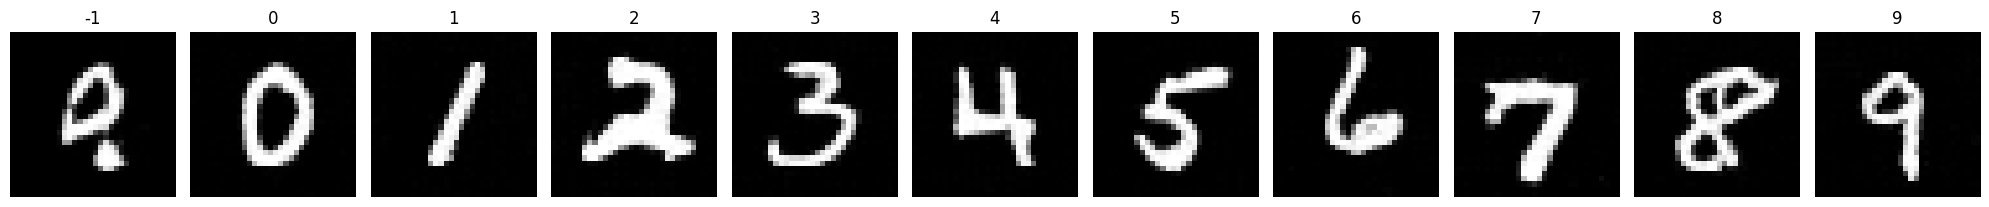

Epoch 72/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0223 - val_loss: 0.0356 - val_noise_loss: 0.0356 - val_image_loss: 0.1726 - learning_rate: 0.0036


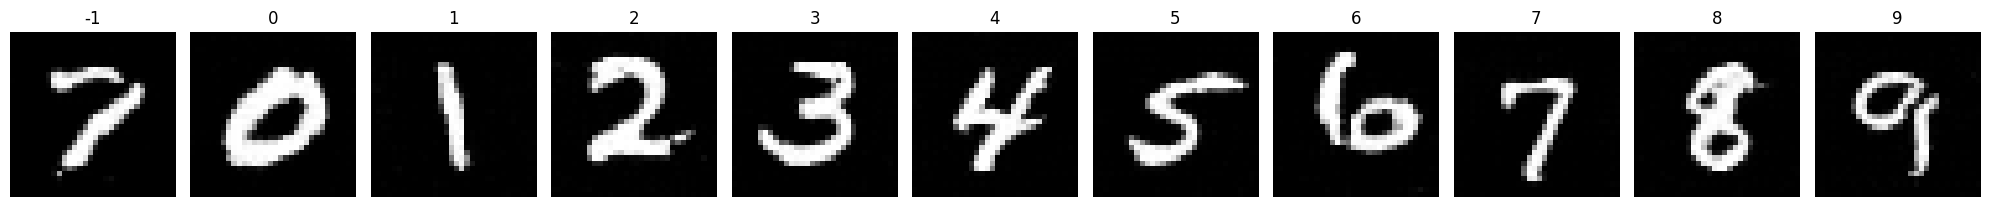

Epoch 73/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0221 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.1751 - learning_rate: 0.0035


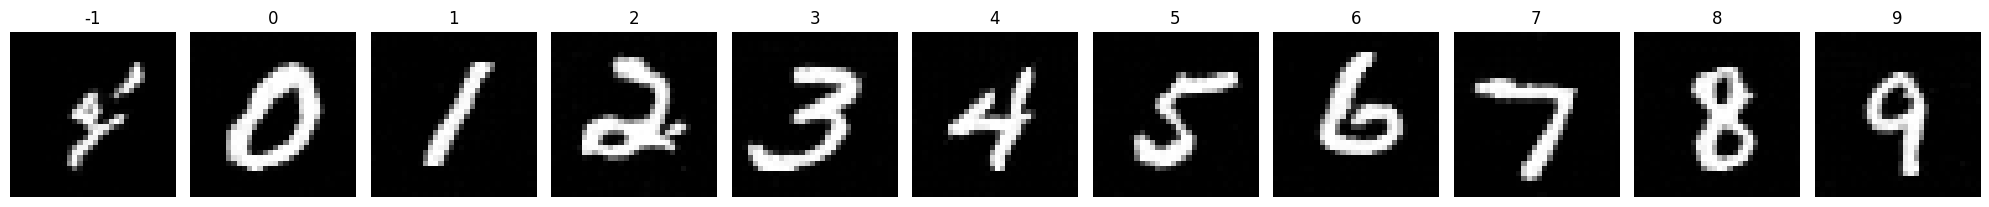

Epoch 74/200
468/468 [==============================] - 48s 103ms/step - noise_loss: 0.0222 - val_loss: 0.0356 - val_noise_loss: 0.0356 - val_image_loss: 0.1690 - learning_rate: 0.0035


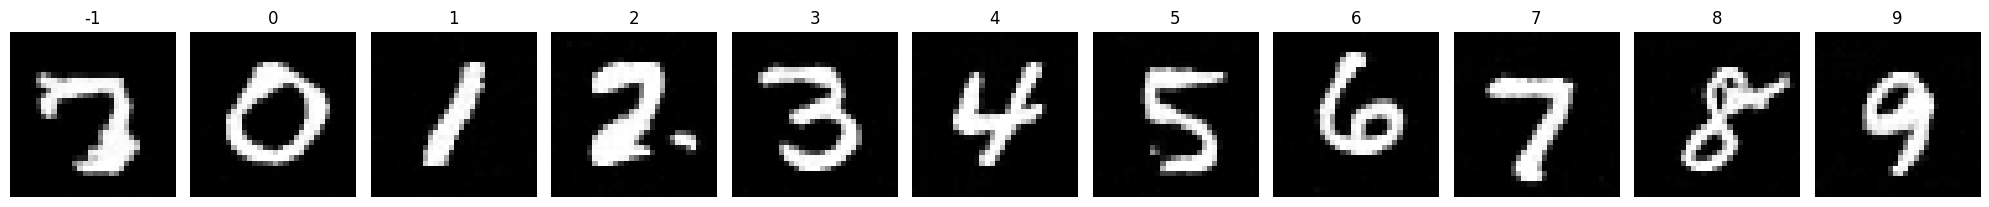

Epoch 75/200
468/468 [==============================] - 49s 104ms/step - noise_loss: 0.0220 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.1724 - learning_rate: 0.0035


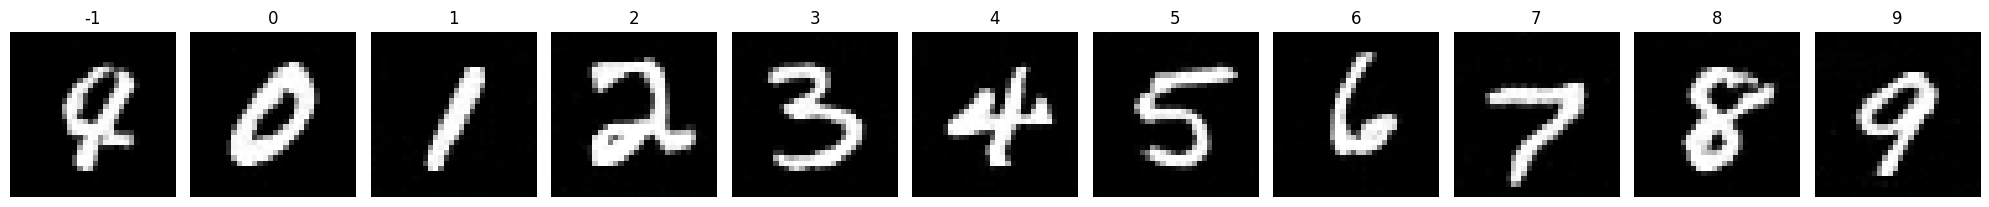

Epoch 76/200
468/468 [==============================] - 50s 106ms/step - noise_loss: 0.0222 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1698 - learning_rate: 0.0034


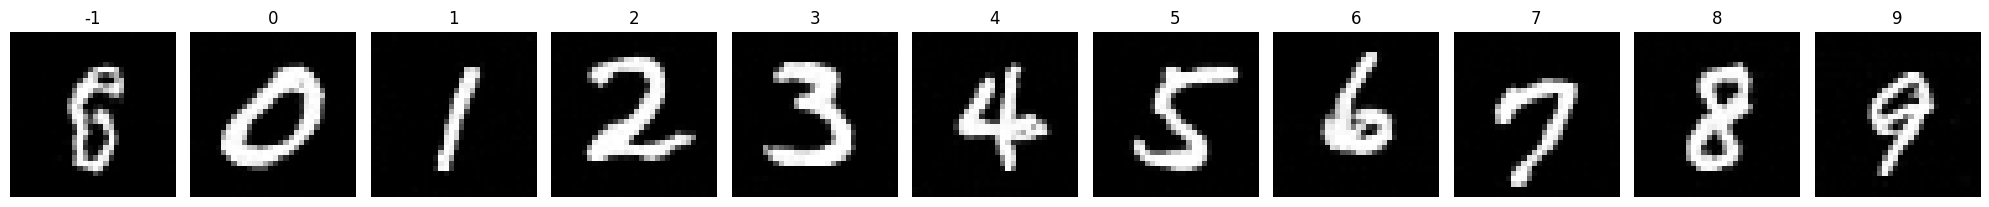

Epoch 77/200
468/468 [==============================] - 49s 105ms/step - noise_loss: 0.0221 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.1688 - learning_rate: 0.0034


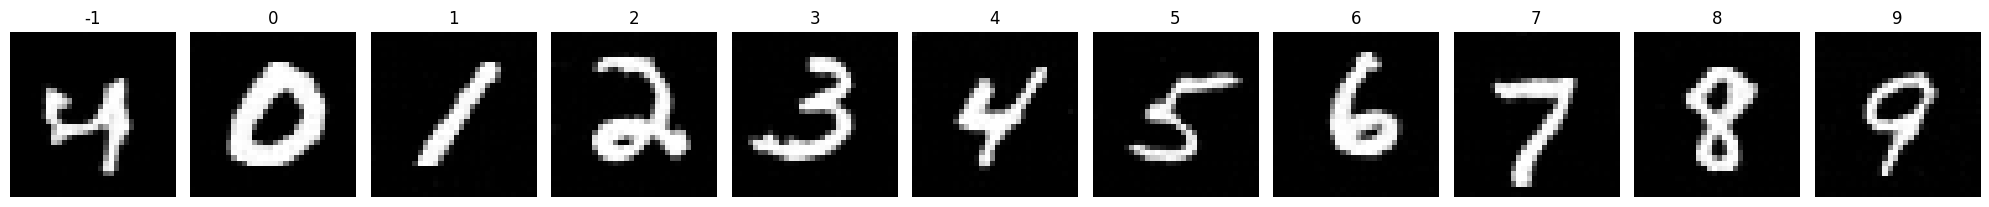

Epoch 78/200
468/468 [==============================] - 50s 106ms/step - noise_loss: 0.0220 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.1662 - learning_rate: 0.0033


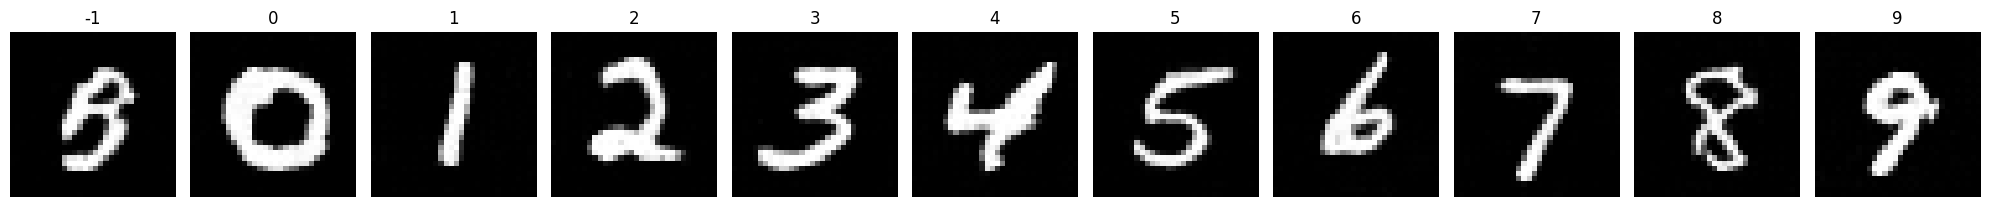

Epoch 79/200
468/468 [==============================] - 50s 106ms/step - noise_loss: 0.0219 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.1679 - learning_rate: 0.0033


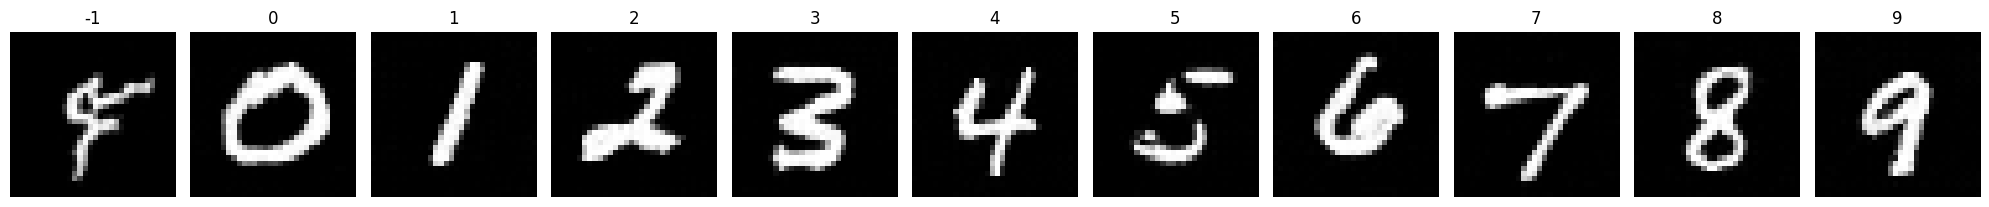

Epoch 80/200
468/468 [==============================] - 50s 106ms/step - noise_loss: 0.0221 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1717 - learning_rate: 0.0033


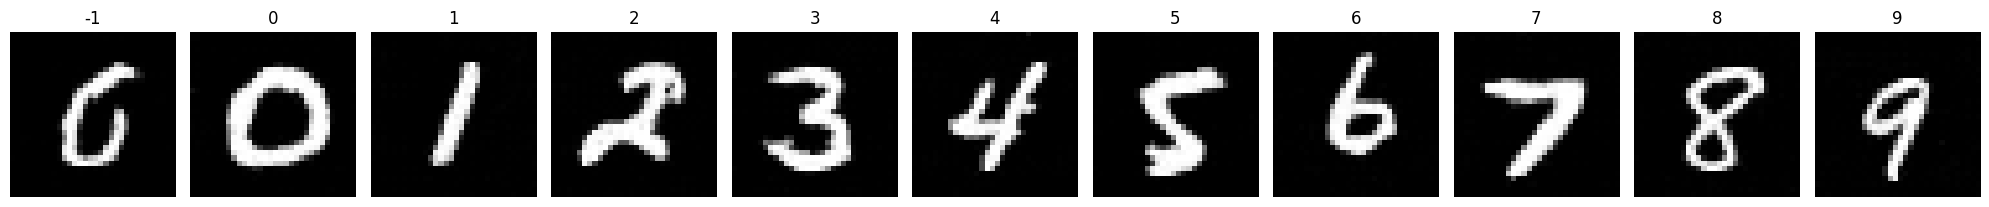

Epoch 81/200
468/468 [==============================] - 50s 107ms/step - noise_loss: 0.0220 - val_loss: 0.0354 - val_noise_loss: 0.0354 - val_image_loss: 0.1687 - learning_rate: 0.0032


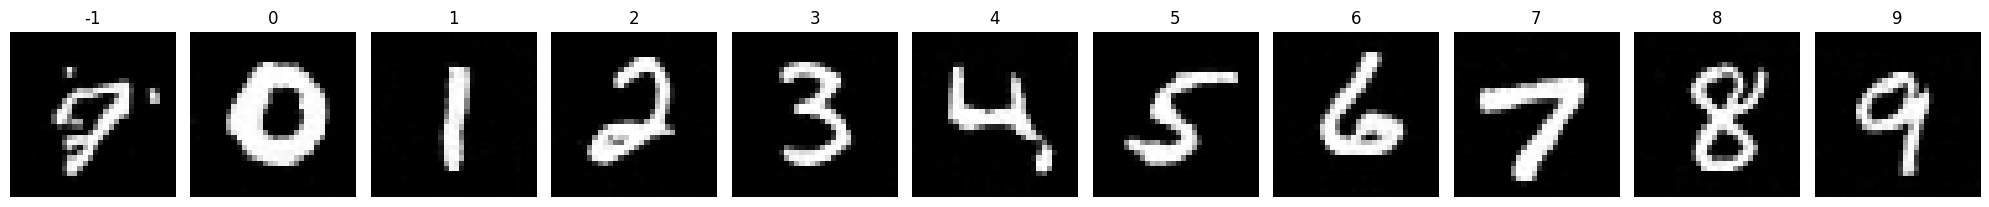

Epoch 82/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0219 - val_loss: 0.0352 - val_noise_loss: 0.0352 - val_image_loss: 0.1650 - learning_rate: 0.0032


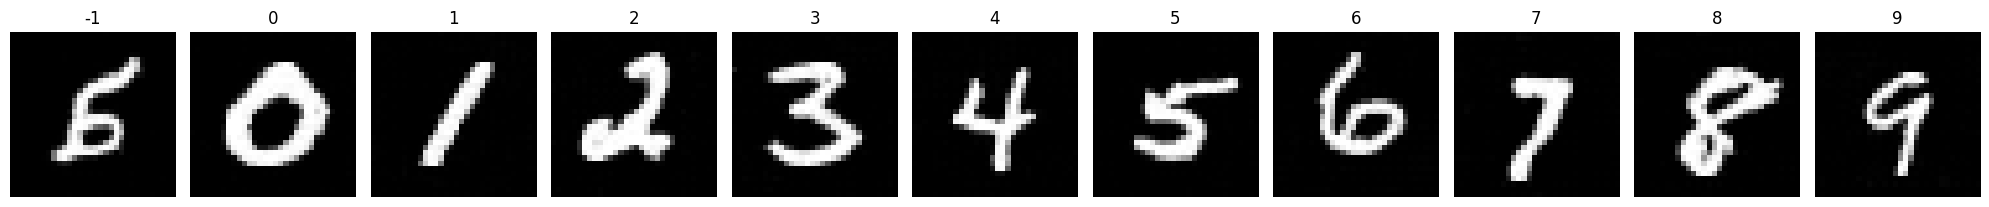

Epoch 83/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0218 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1702 - learning_rate: 0.0032


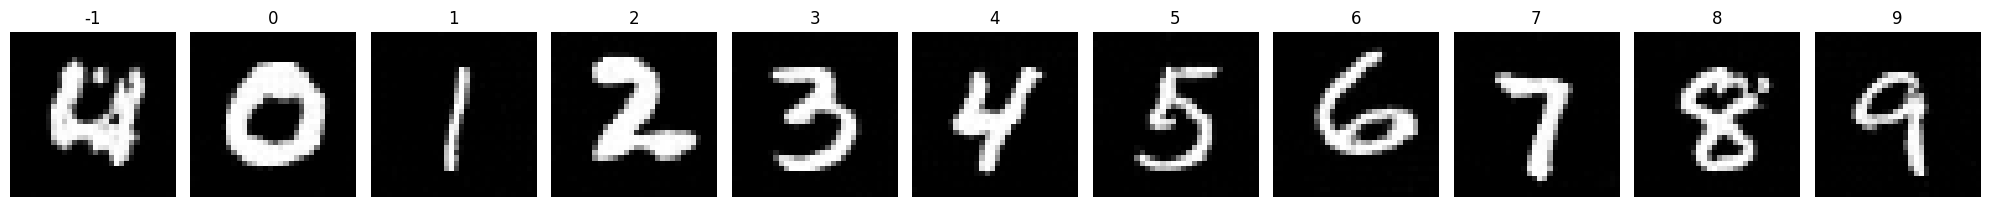

Epoch 84/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0219 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1700 - learning_rate: 0.0031


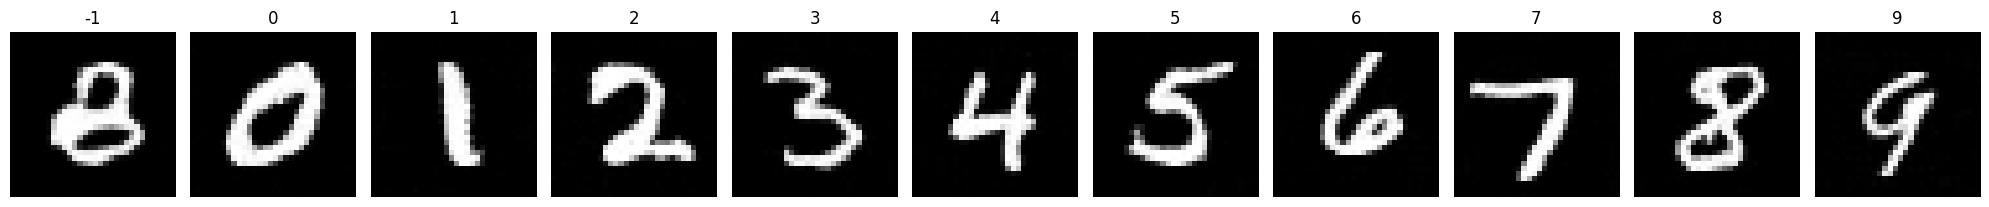

Epoch 85/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0217 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1697 - learning_rate: 0.0031


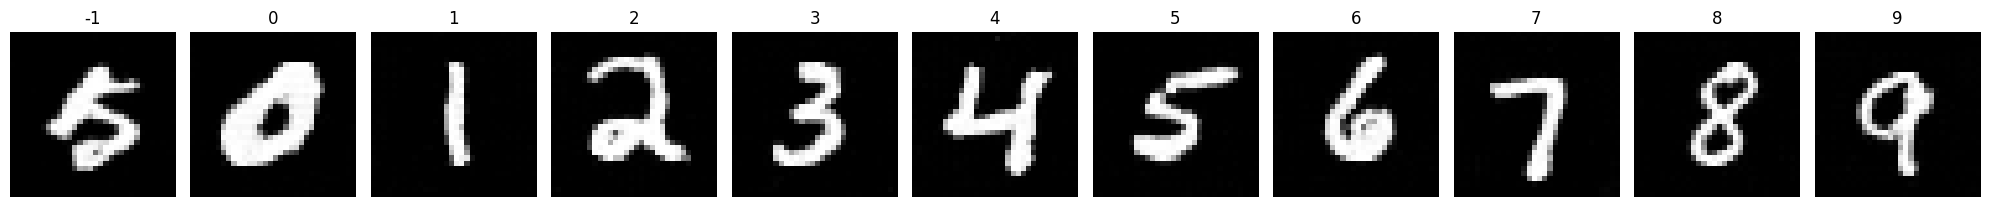

Epoch 86/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0218 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1660 - learning_rate: 0.0030


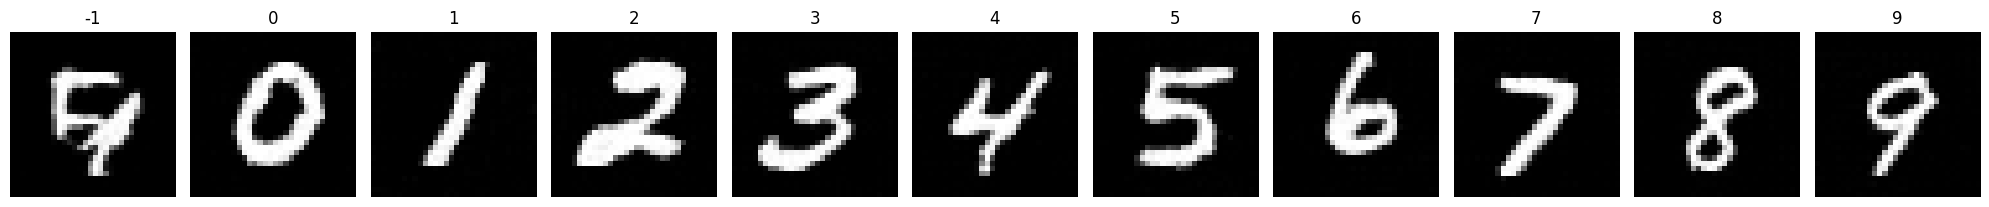

Epoch 87/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0217 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1663 - learning_rate: 0.0030


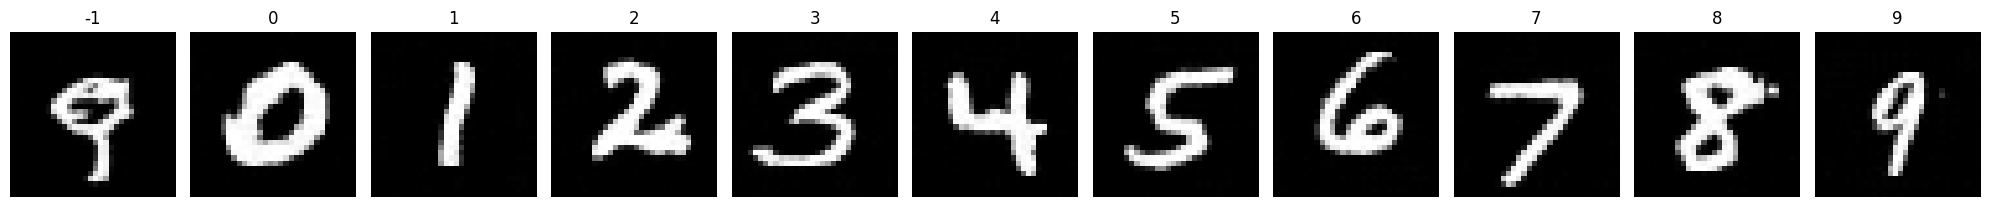

Epoch 88/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0219 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1693 - learning_rate: 0.0030


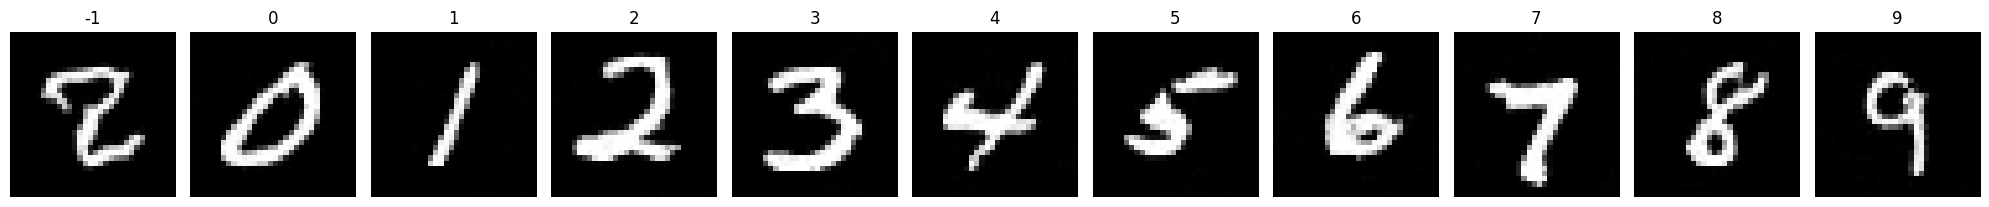

Epoch 89/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0217 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1675 - learning_rate: 0.0029


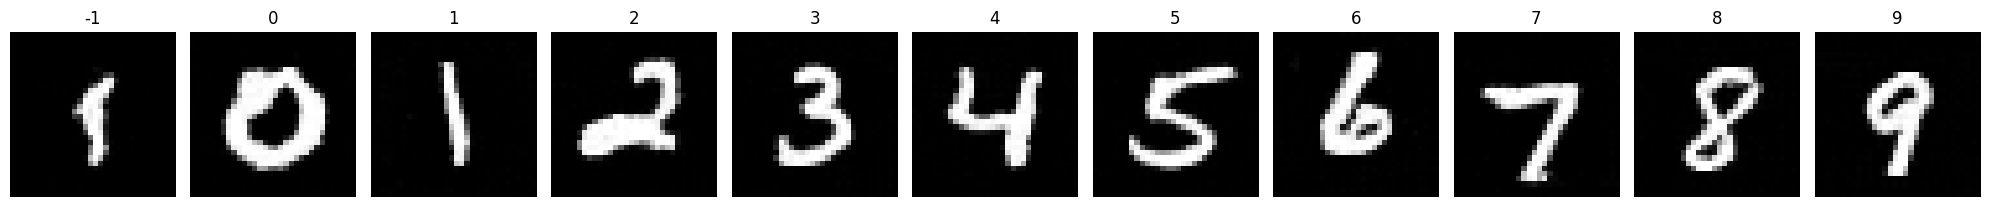

Epoch 90/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0216 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1689 - learning_rate: 0.0029


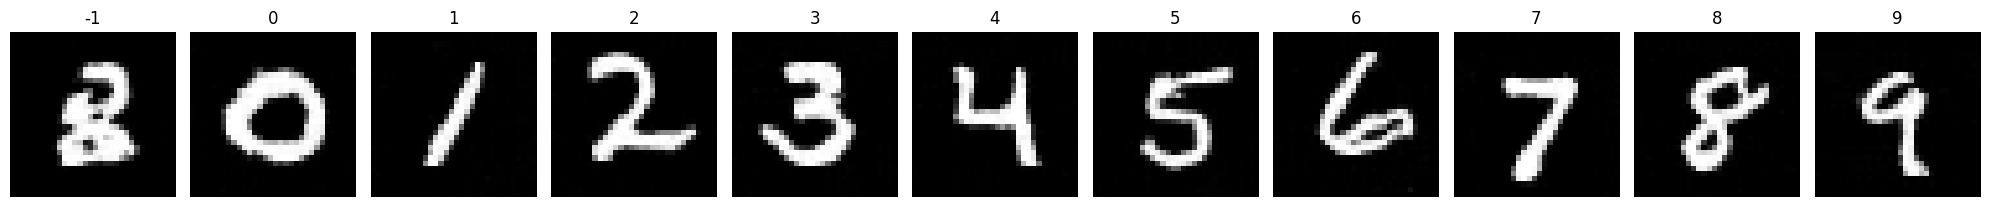

Epoch 91/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0217 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1682 - learning_rate: 0.0029


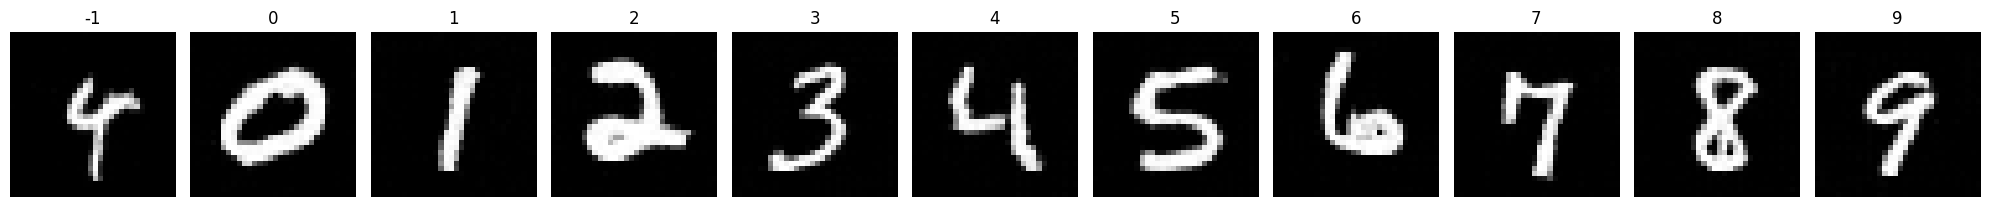

Epoch 92/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0217 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1656 - learning_rate: 0.0028


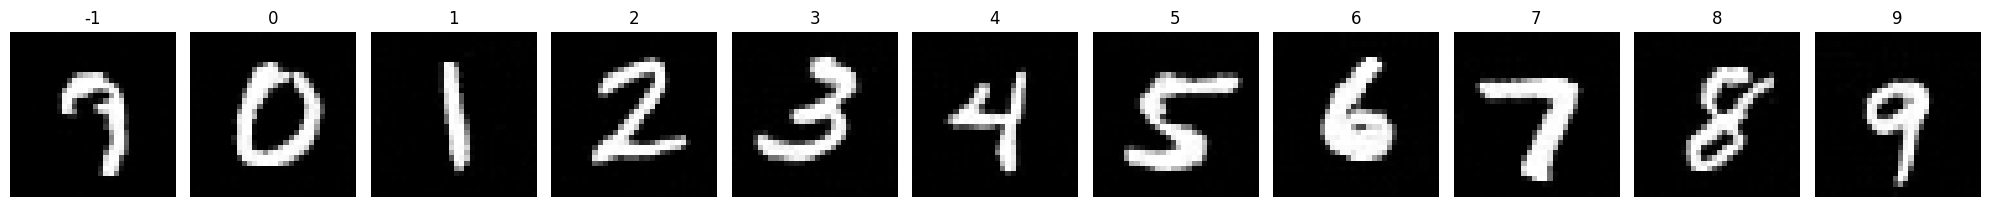

Epoch 93/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0216 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1642 - learning_rate: 0.0028


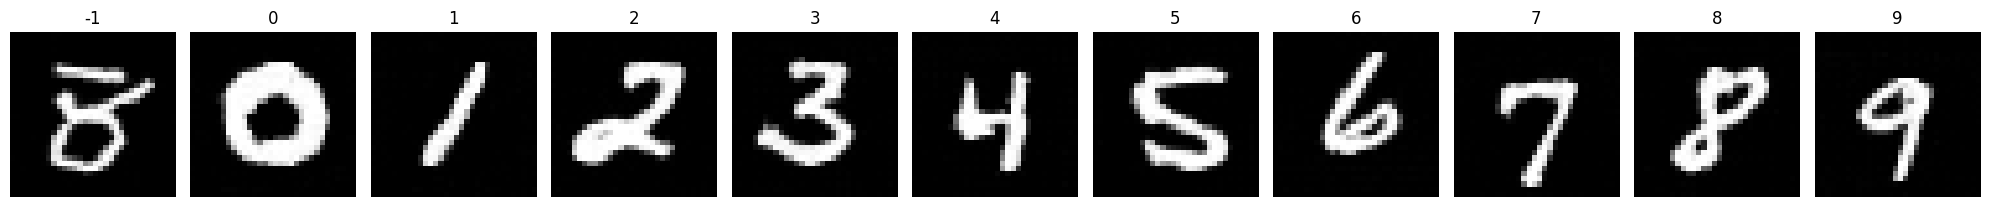

Epoch 94/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0216 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1661 - learning_rate: 0.0027


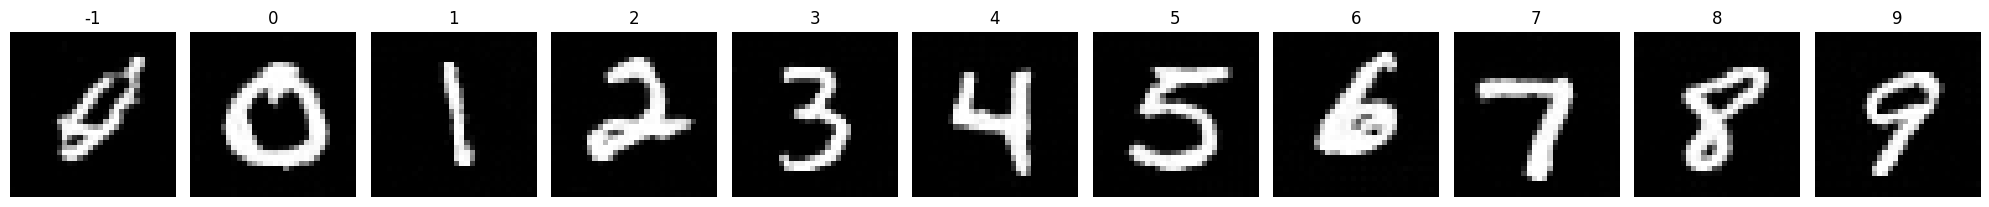

Epoch 95/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0216 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1681 - learning_rate: 0.0027


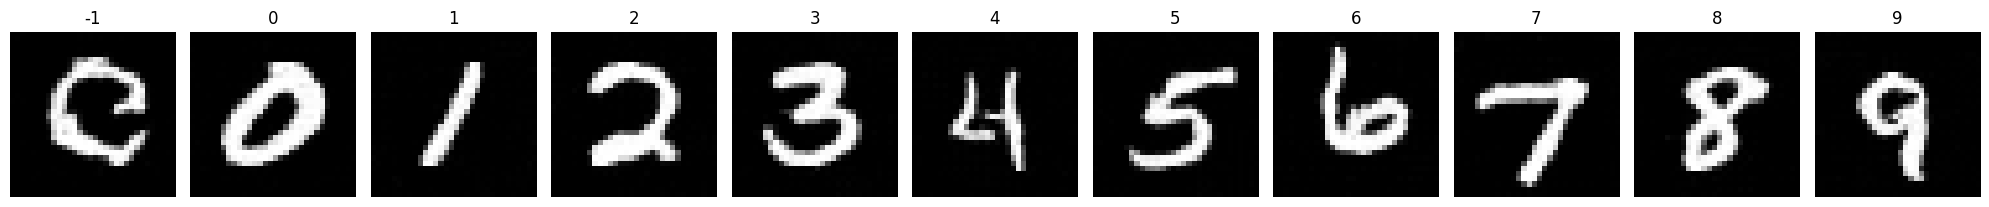

Epoch 96/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0216 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1684 - learning_rate: 0.0027


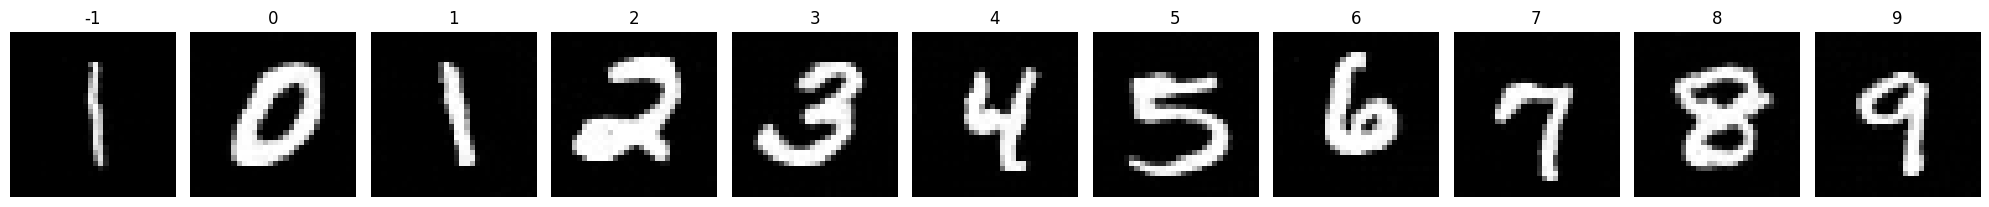

Epoch 97/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0214 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1650 - learning_rate: 0.0026


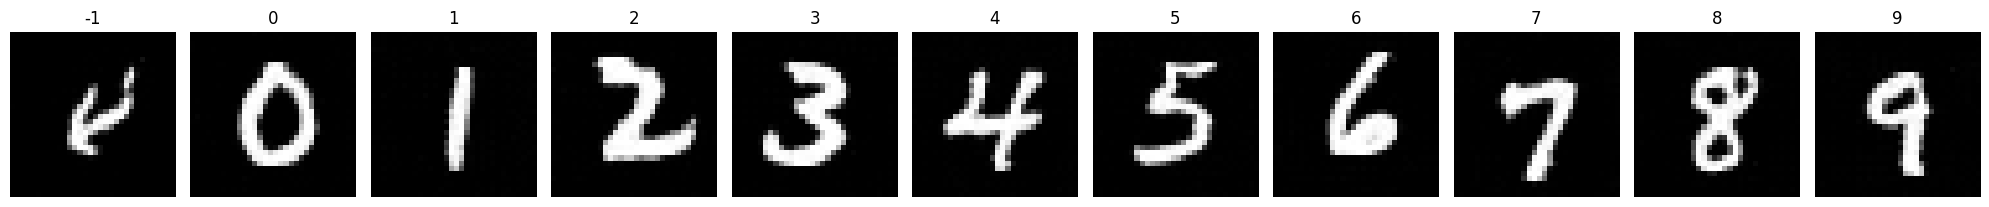

Epoch 98/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0215 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1660 - learning_rate: 0.0026


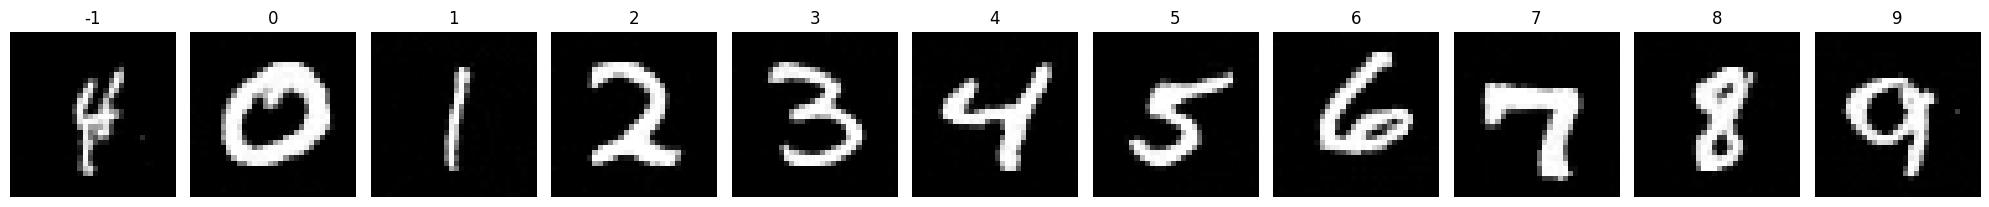

Epoch 99/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0214 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1664 - learning_rate: 0.0025


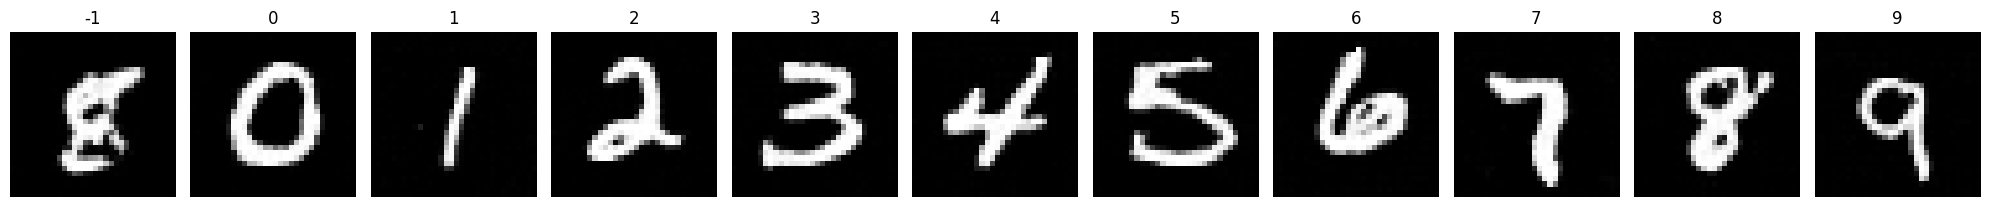

Epoch 100/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0215 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1642 - learning_rate: 0.0025


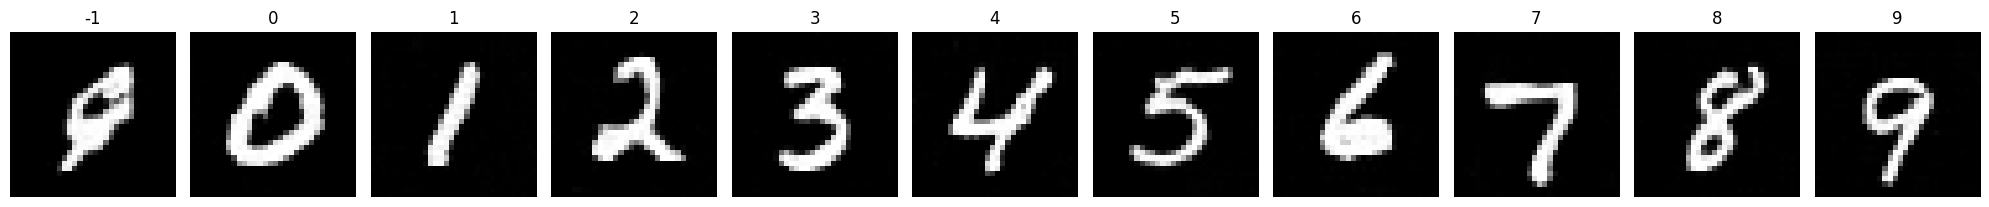

Epoch 101/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0215 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1693 - learning_rate: 0.0025


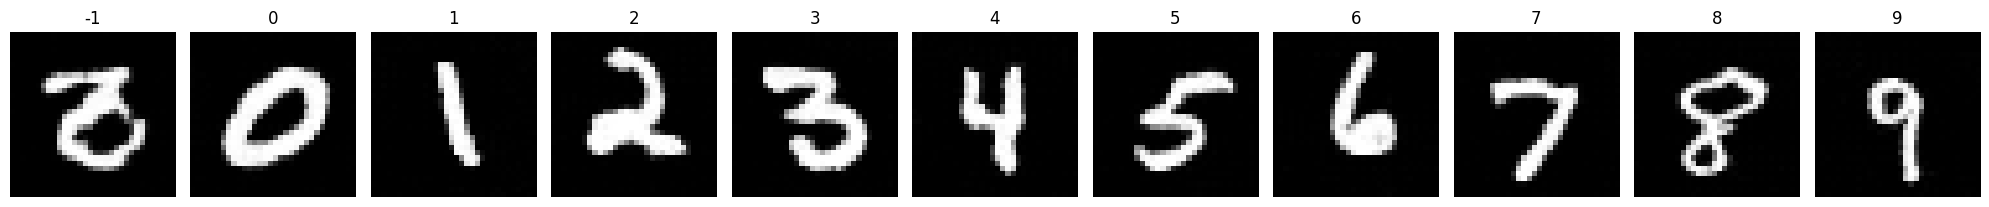

Epoch 102/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0214 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1641 - learning_rate: 0.0024


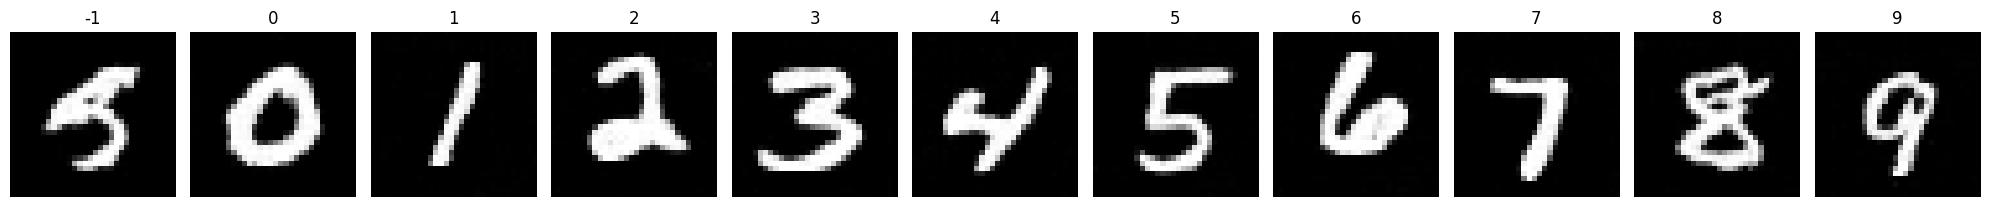

Epoch 103/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0213 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1672 - learning_rate: 0.0024


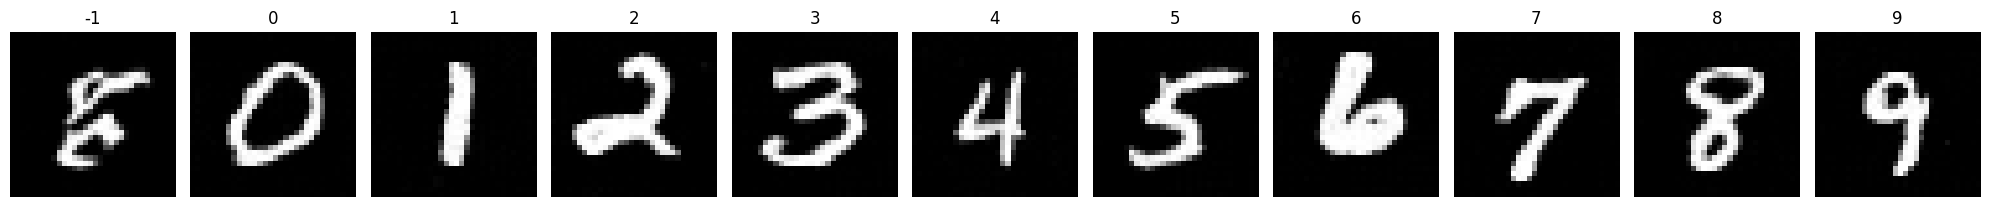

Epoch 104/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0214 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1630 - learning_rate: 0.0023


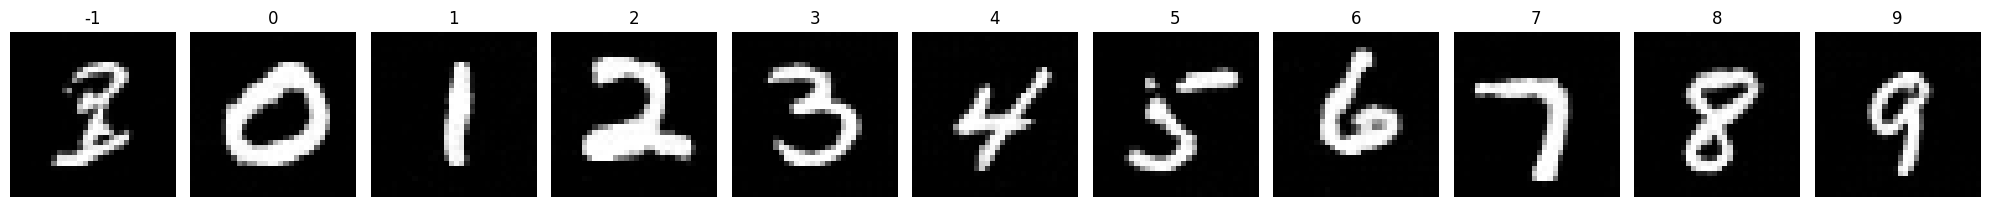

Epoch 105/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0214 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1647 - learning_rate: 0.0023


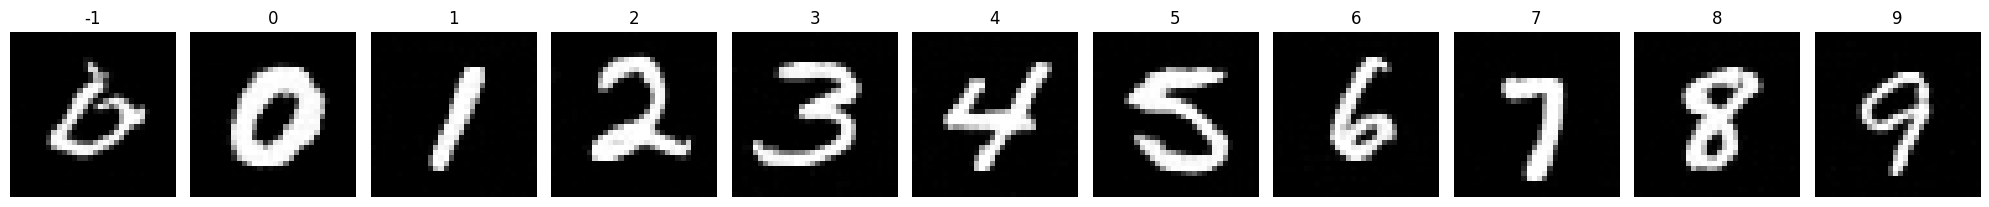

Epoch 106/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0213 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1619 - learning_rate: 0.0023


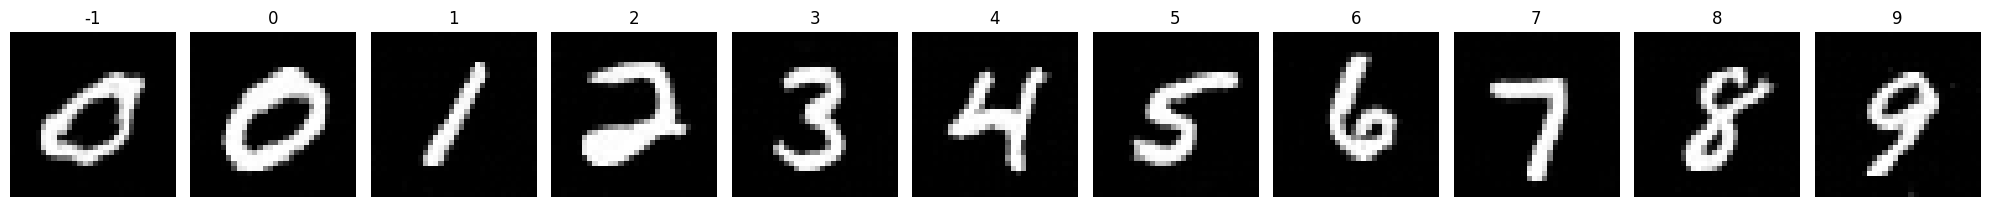

Epoch 107/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0212 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1660 - learning_rate: 0.0022


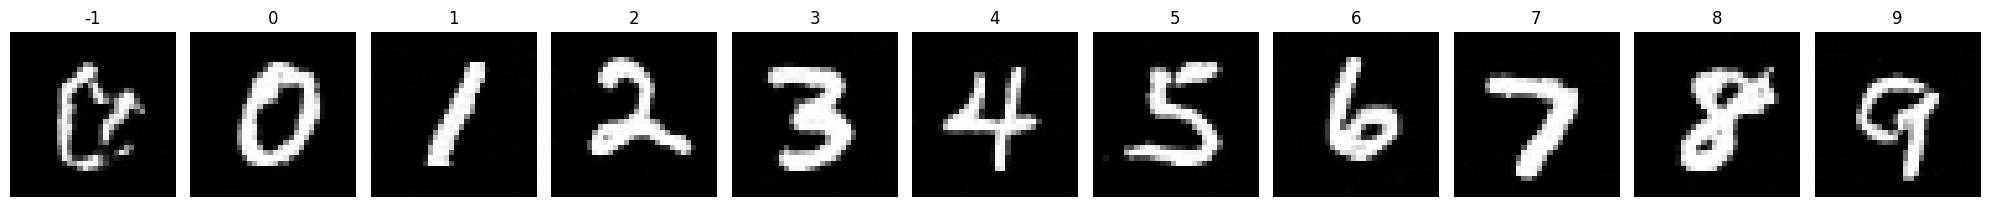

Epoch 108/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0213 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1647 - learning_rate: 0.0022


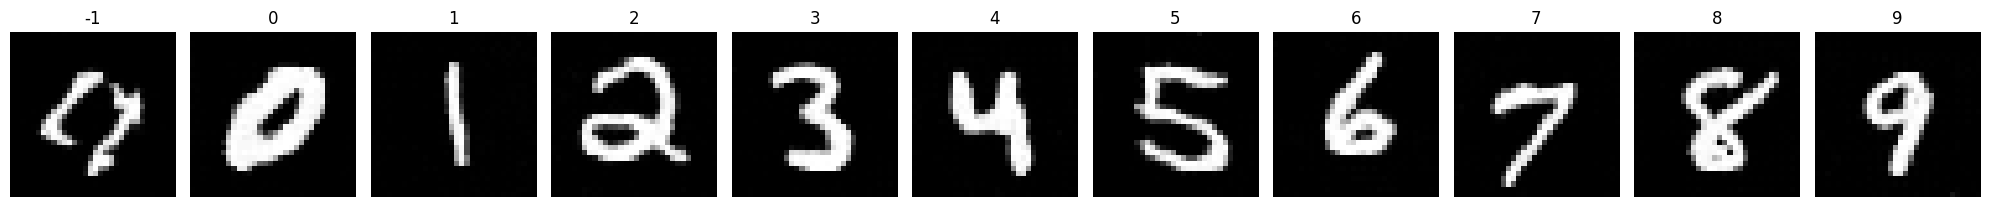

Epoch 109/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0212 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1651 - learning_rate: 0.0021


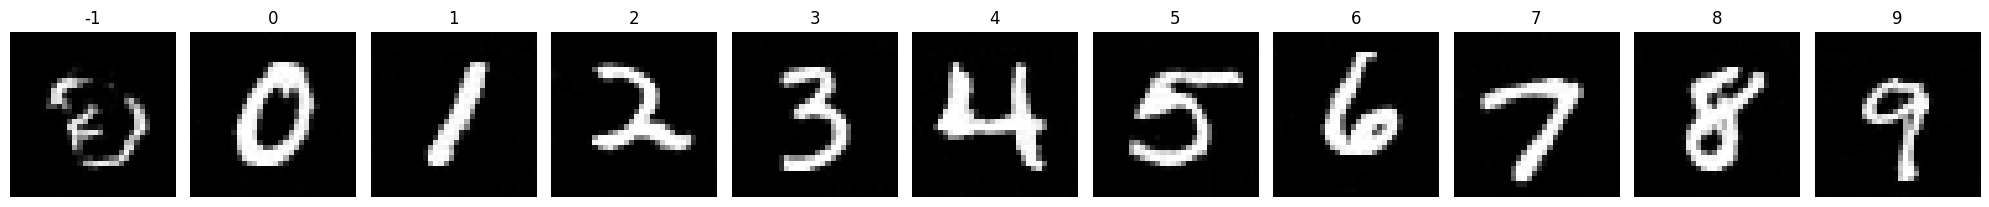

Epoch 110/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0213 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1639 - learning_rate: 0.0021


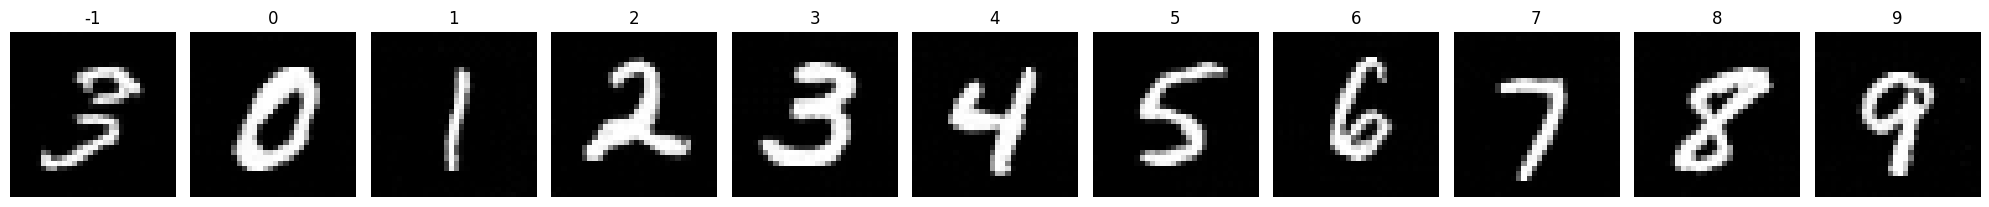

Epoch 111/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0212 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1671 - learning_rate: 0.0021


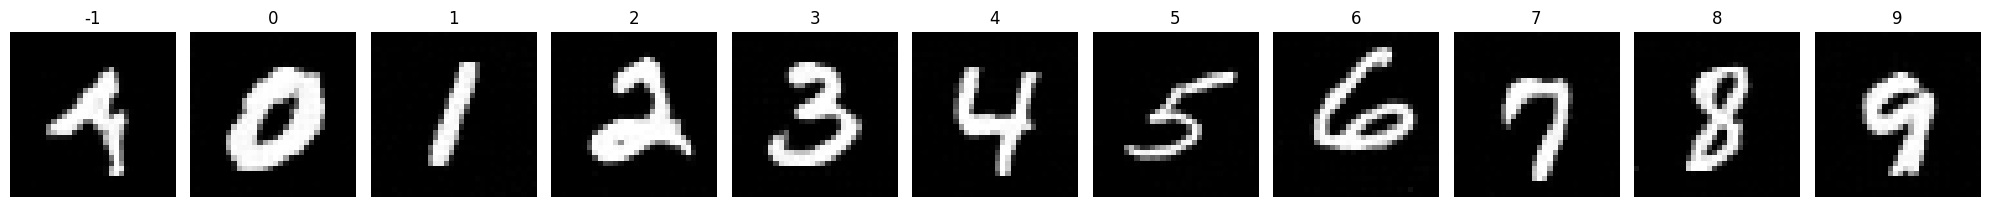

Epoch 112/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0211 - val_loss: 0.0340 - val_noise_loss: 0.0340 - val_image_loss: 0.1717 - learning_rate: 0.0020


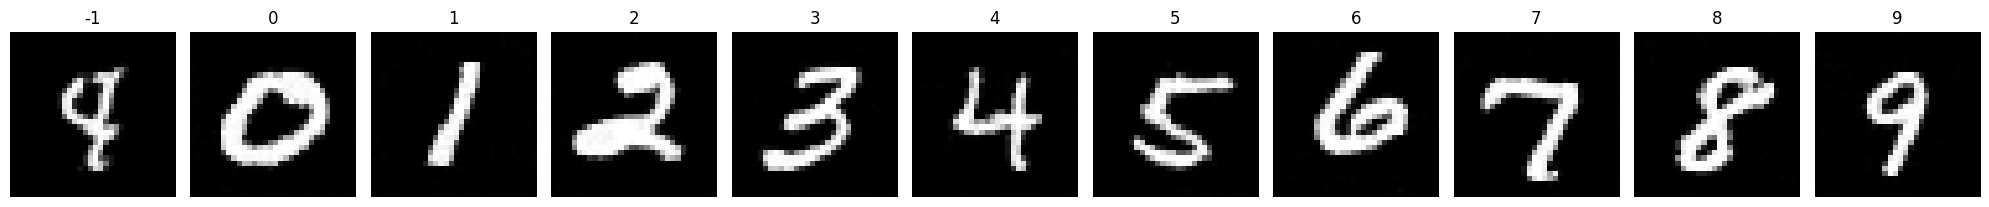

Epoch 113/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0211 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1664 - learning_rate: 0.0020


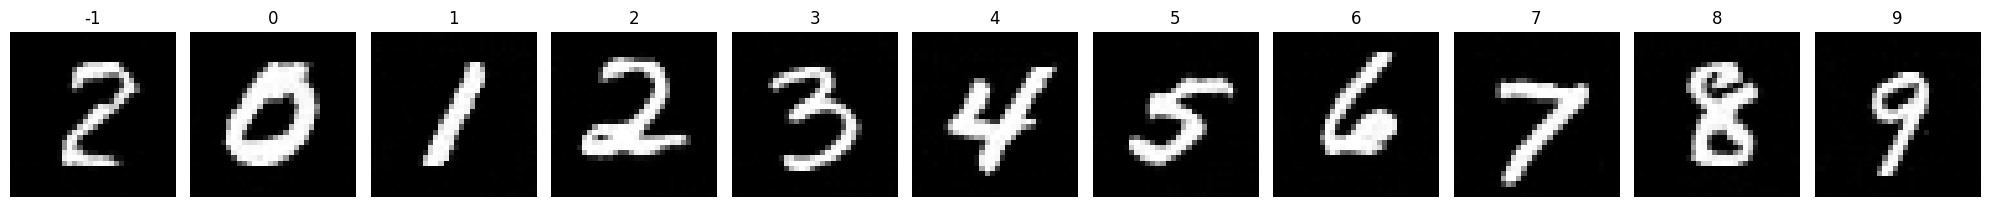

Epoch 114/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0212 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1648 - learning_rate: 0.0020


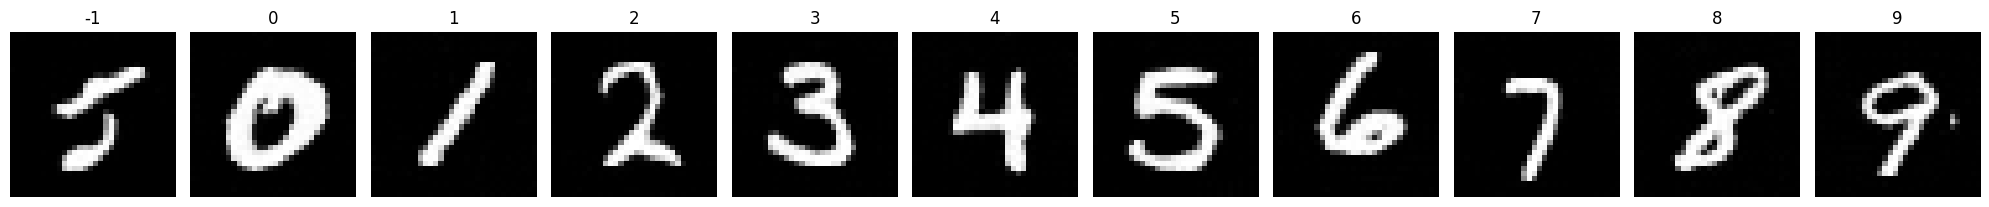

Epoch 115/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0212 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1664 - learning_rate: 0.0019


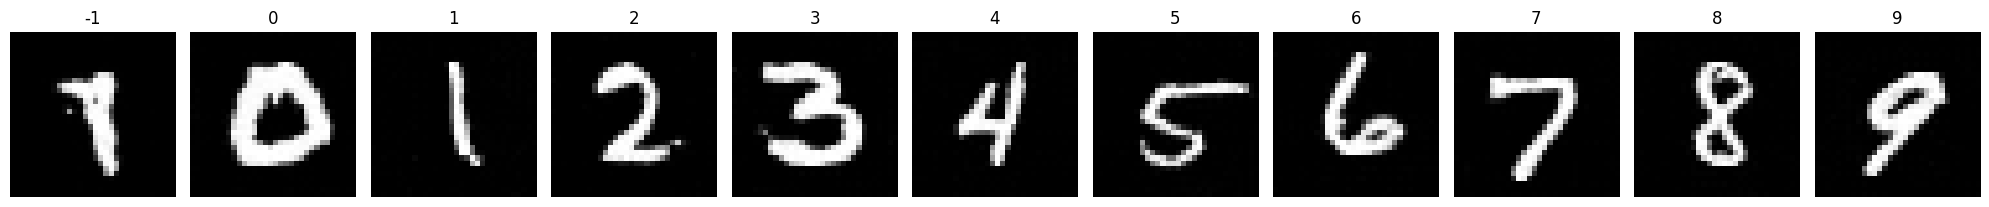

Epoch 116/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0211 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1626 - learning_rate: 0.0019


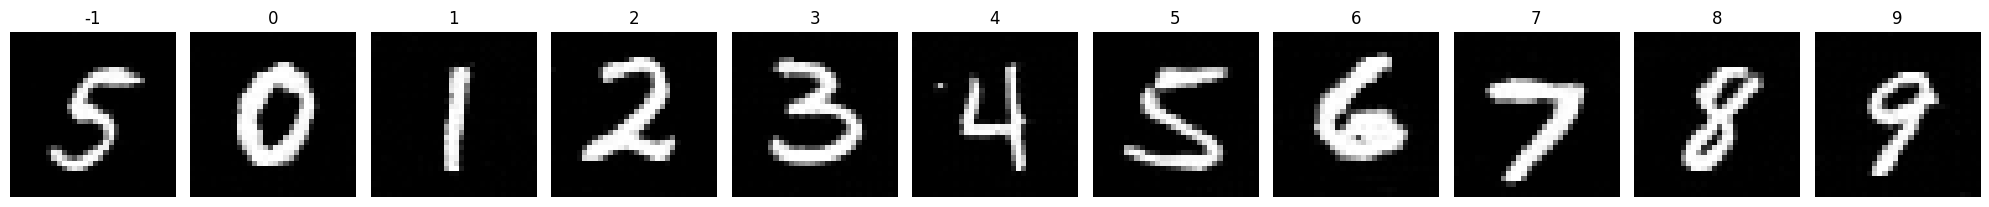

Epoch 117/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1673 - learning_rate: 0.0018


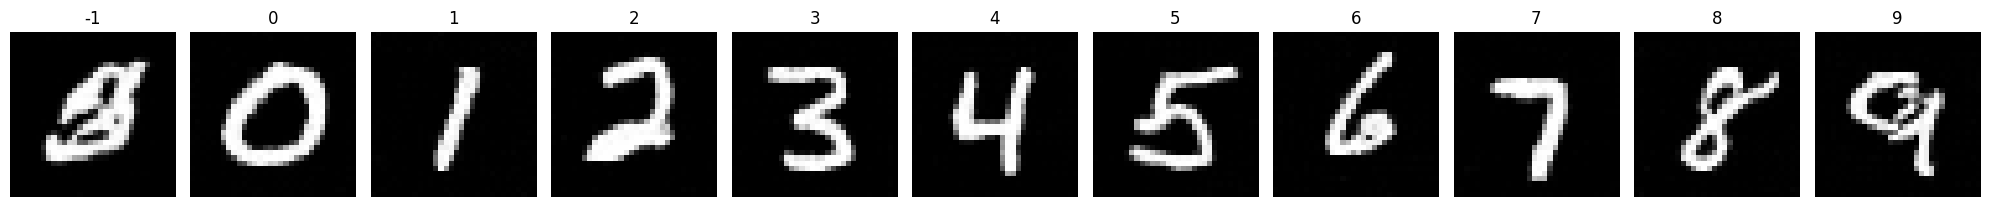

Epoch 118/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0211 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1611 - learning_rate: 0.0018


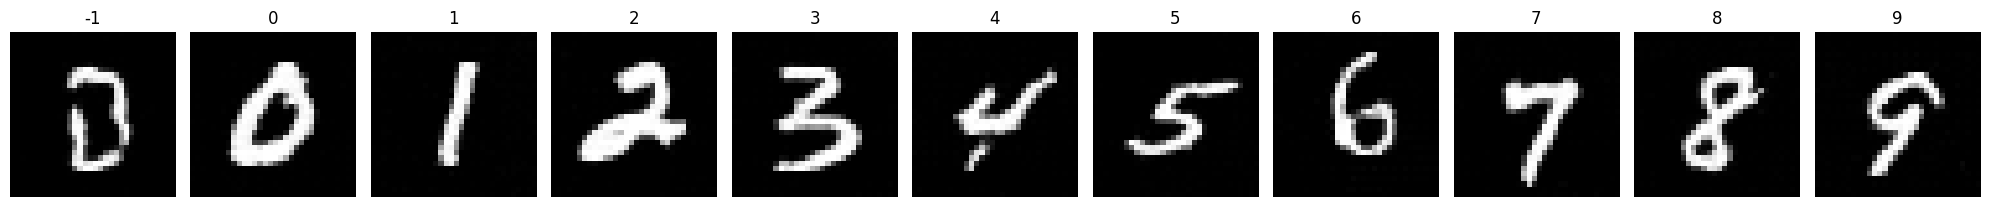

Epoch 119/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1660 - learning_rate: 0.0018


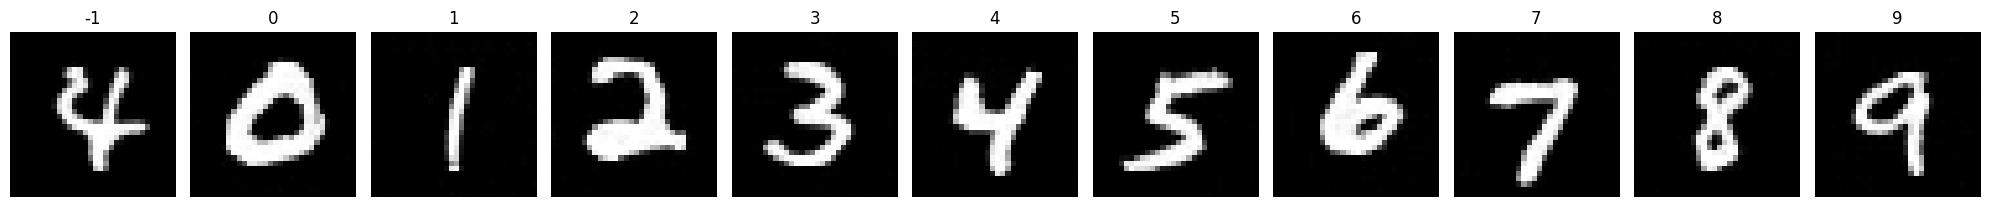

Epoch 120/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0211 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1643 - learning_rate: 0.0017


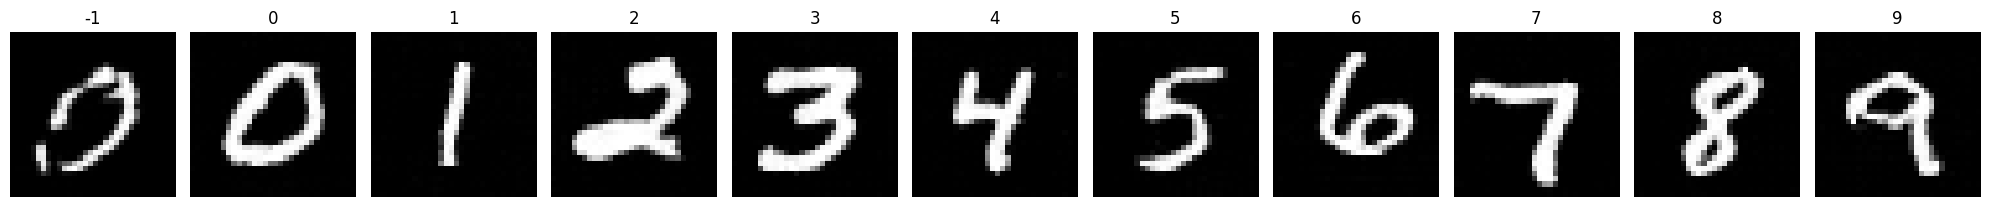

Epoch 121/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0210 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1650 - learning_rate: 0.0017


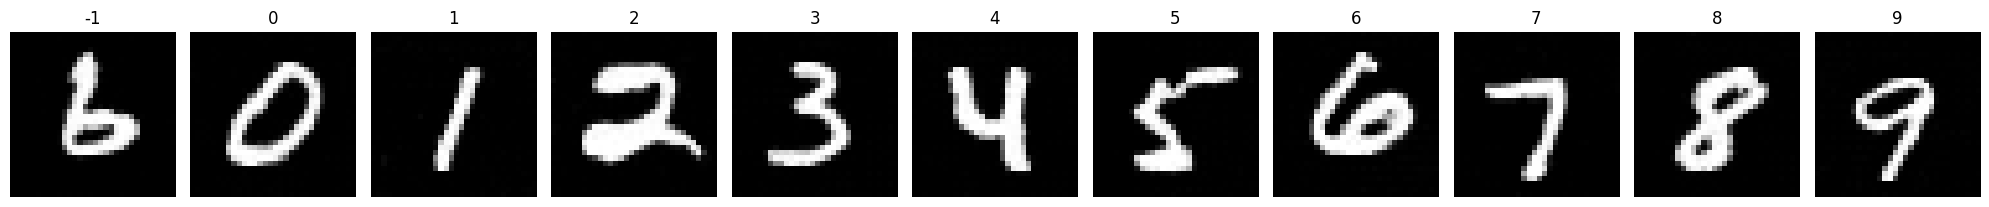

Epoch 122/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1652 - learning_rate: 0.0017


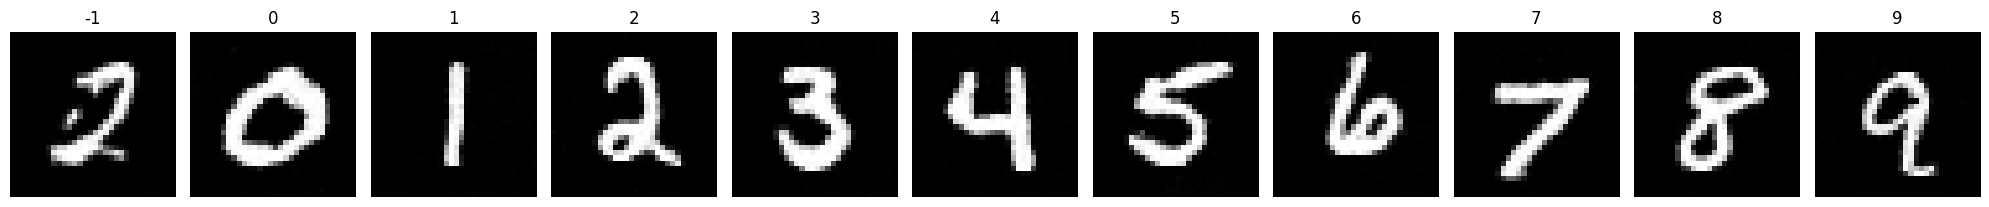

Epoch 123/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1659 - learning_rate: 0.0016


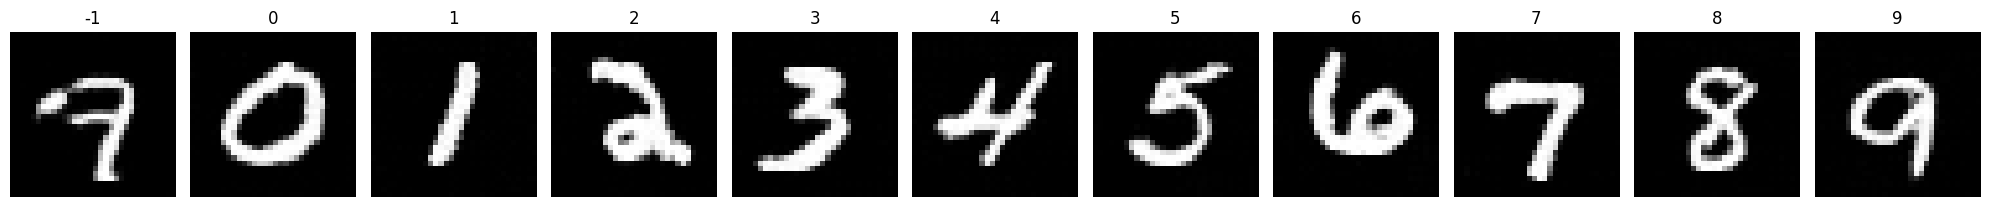

Epoch 124/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1678 - learning_rate: 0.0016


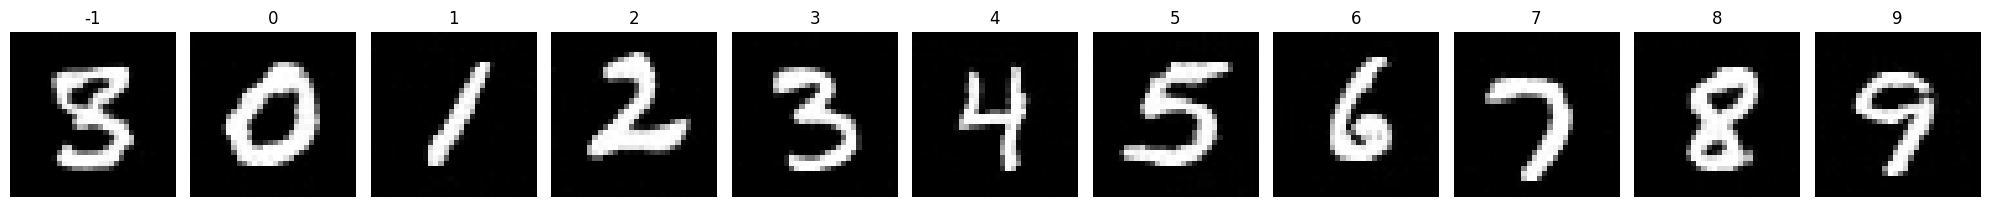

Epoch 125/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1640 - learning_rate: 0.0015


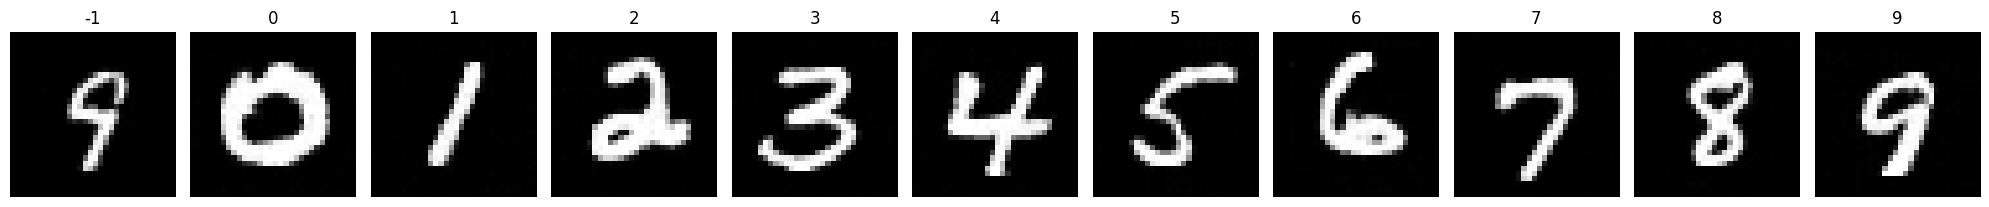

Epoch 126/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0210 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1615 - learning_rate: 0.0015


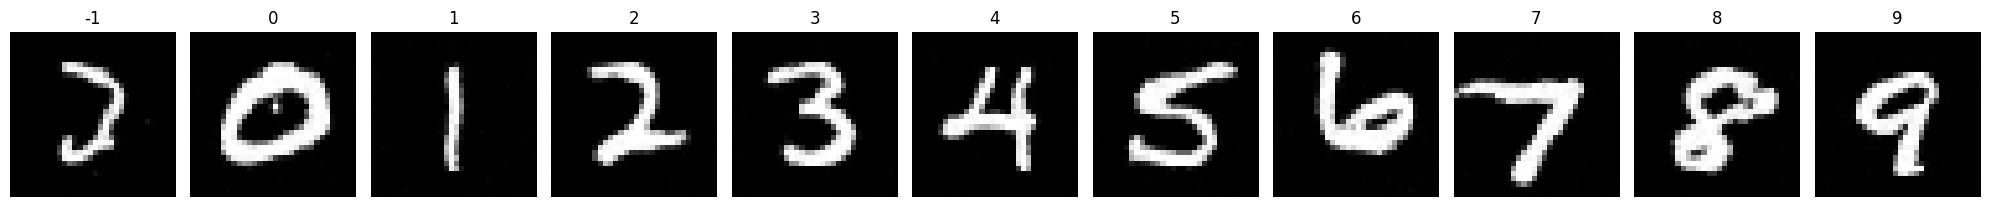

Epoch 127/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0210 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1642 - learning_rate: 0.0015


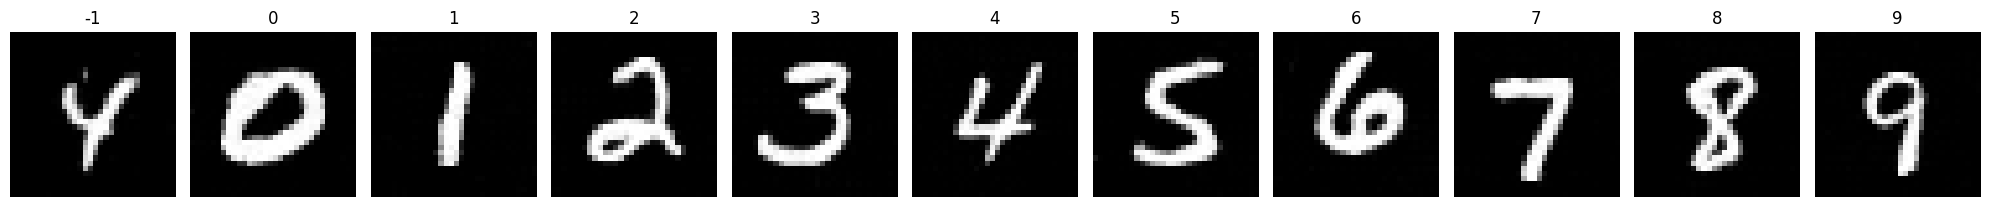

Epoch 128/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0209 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1684 - learning_rate: 0.0014


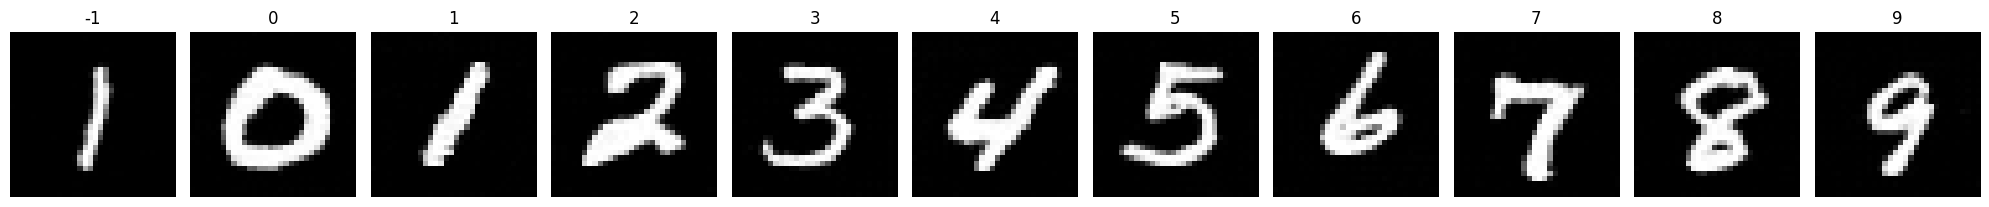

Epoch 129/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0209 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1679 - learning_rate: 0.0014


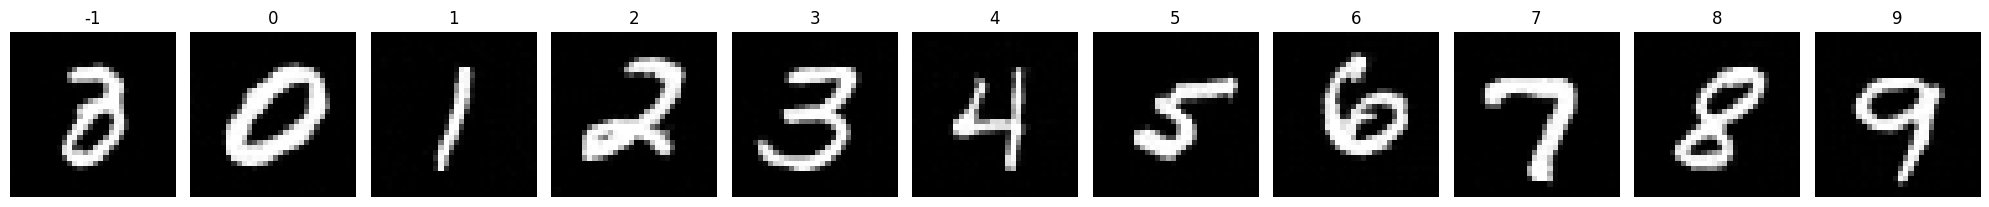

Epoch 130/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0209 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1658 - learning_rate: 0.0014


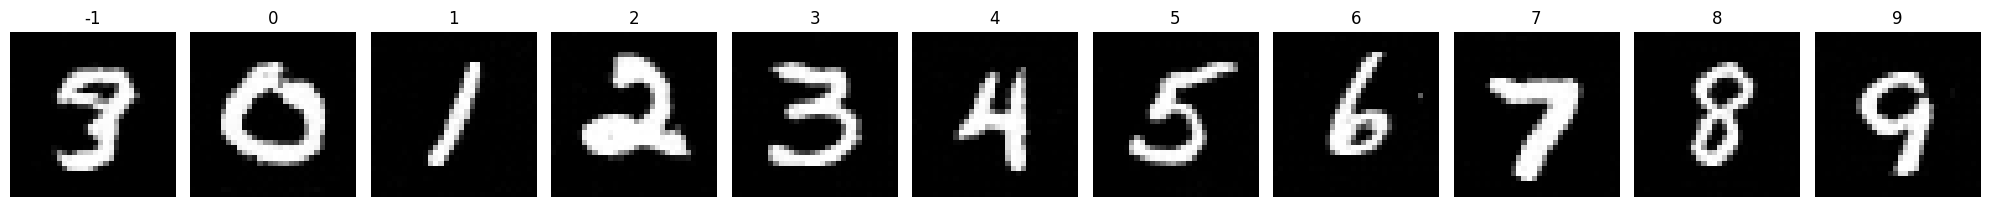

Epoch 131/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0208 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1645 - learning_rate: 0.0013


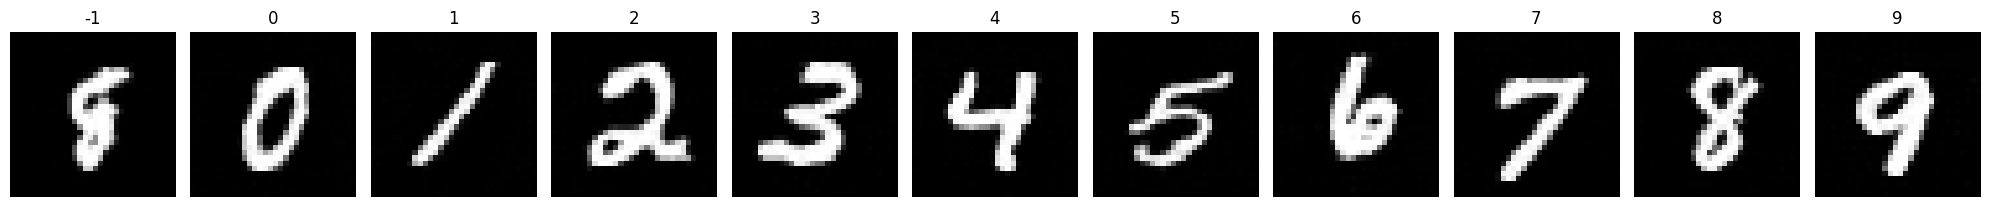

Epoch 132/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0208 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1624 - learning_rate: 0.0013


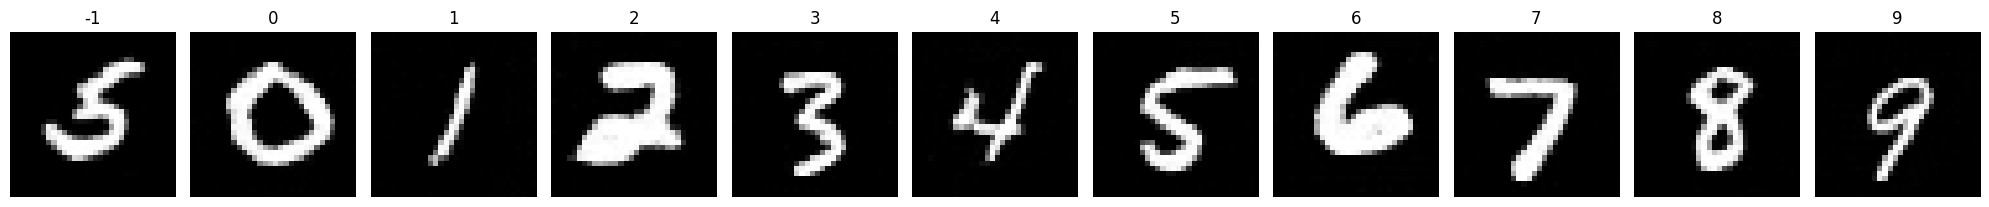

Epoch 133/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0208 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1673 - learning_rate: 0.0013


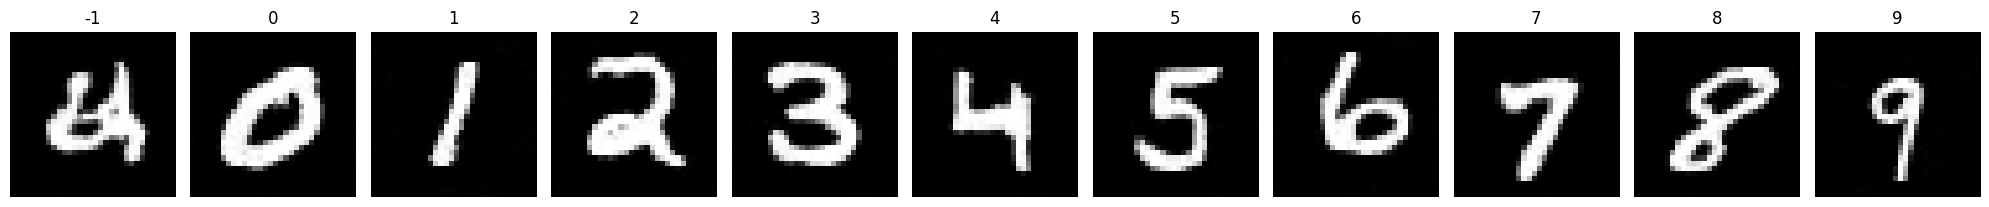

Epoch 134/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0208 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1631 - learning_rate: 0.0012


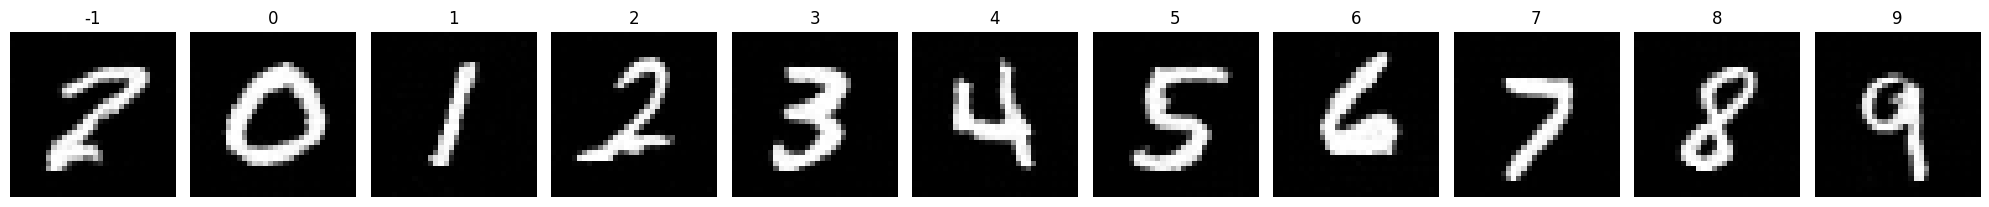

Epoch 135/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0208 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1633 - learning_rate: 0.0012


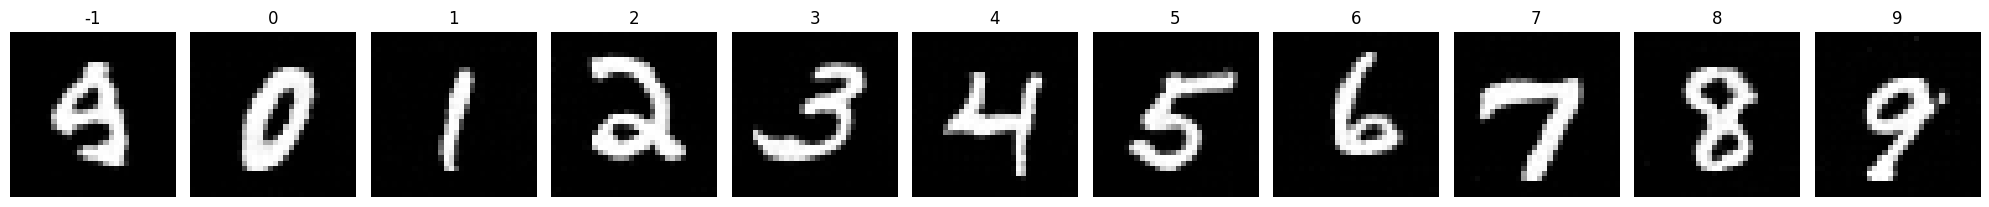

Epoch 136/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0207 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1644 - learning_rate: 0.0012


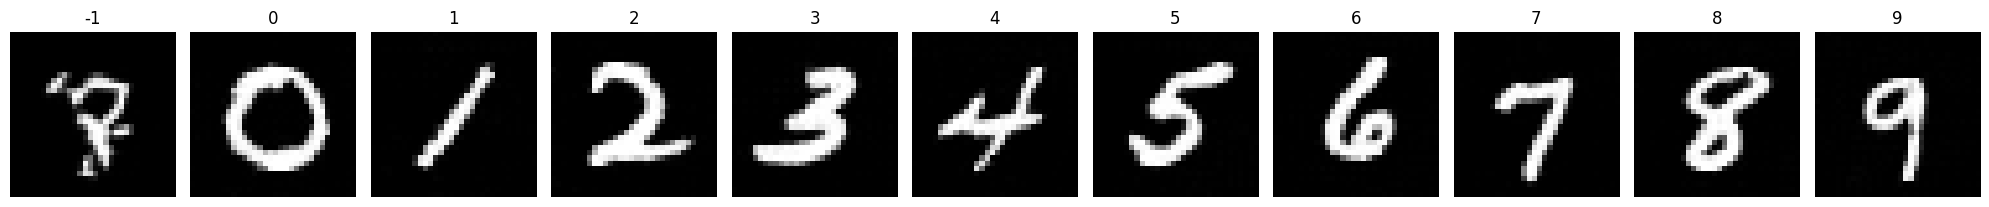

Epoch 137/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0206 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1670 - learning_rate: 0.0011


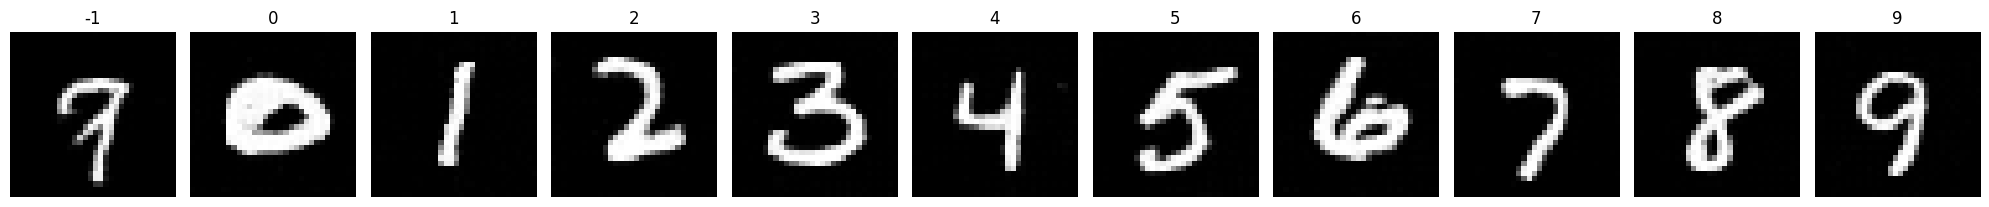

Epoch 138/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0207 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1626 - learning_rate: 0.0011


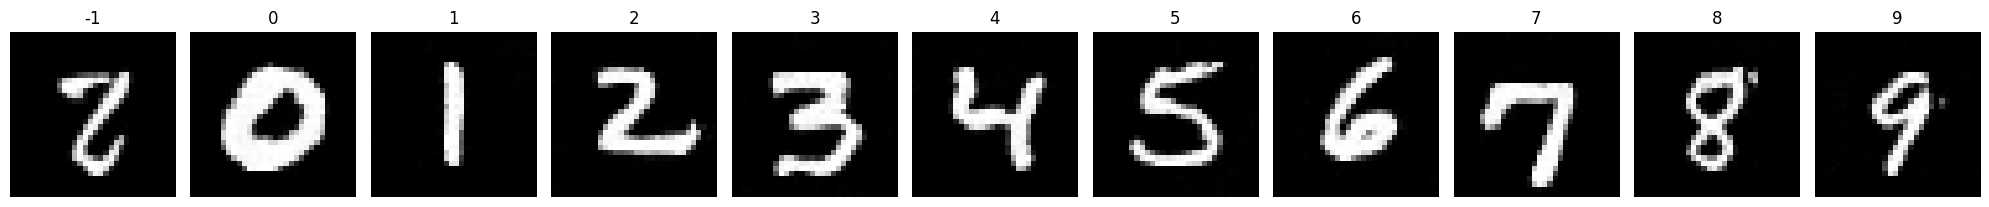

Epoch 139/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0206 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1699 - learning_rate: 0.0011


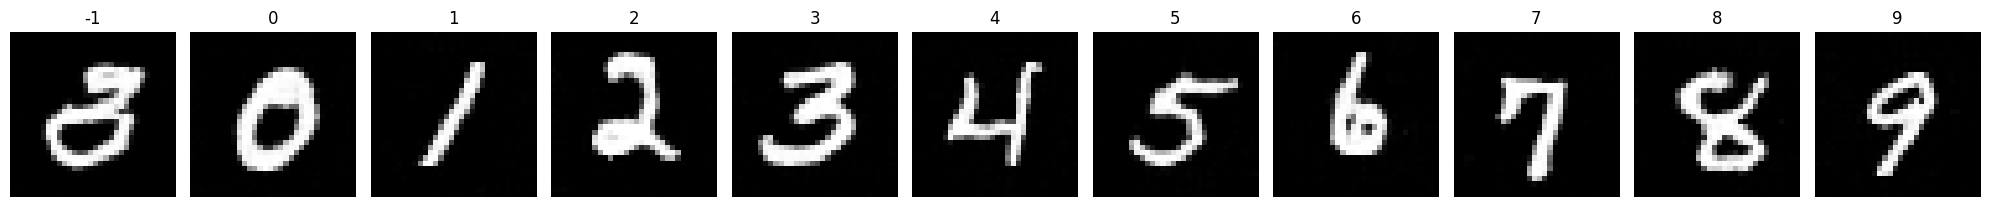

Epoch 140/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0207 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1628 - learning_rate: 0.0010


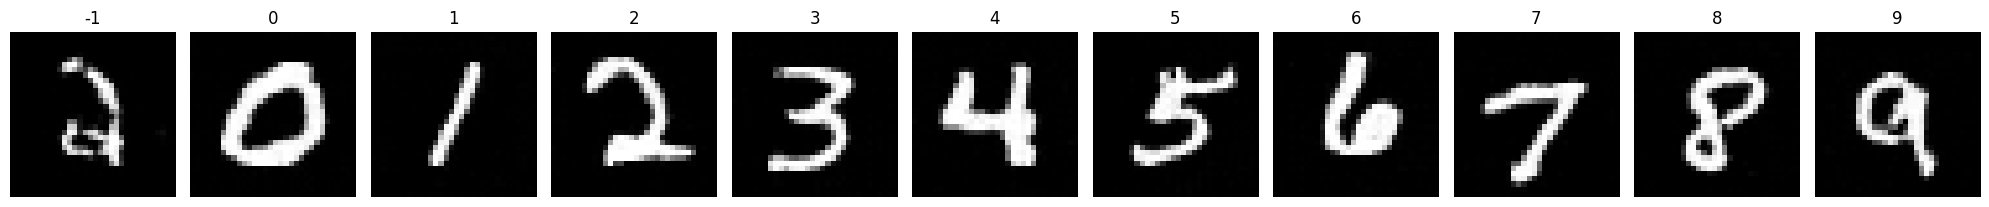

Epoch 141/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0206 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1660 - learning_rate: 9.9895e-04


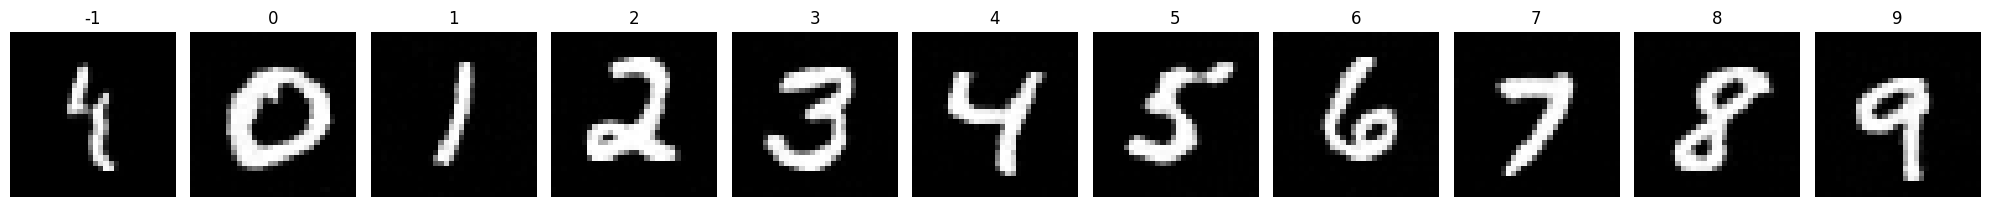

Epoch 142/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0206 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1637 - learning_rate: 9.6773e-04


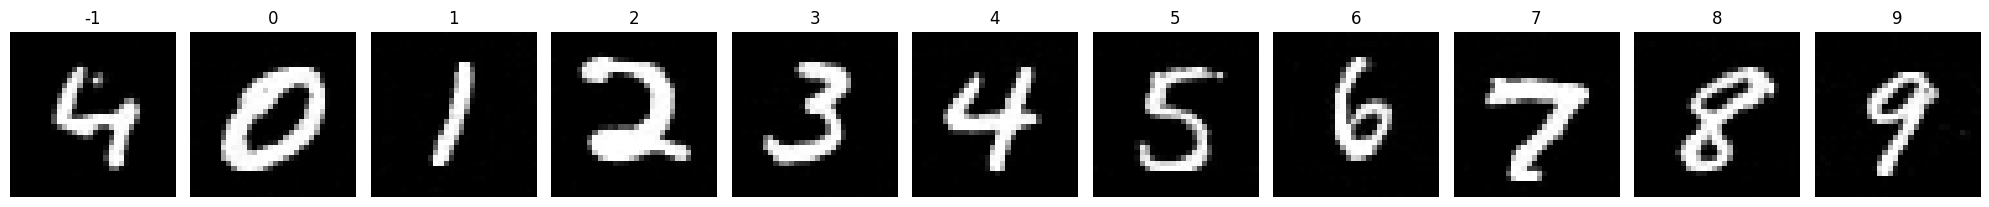

Epoch 143/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0207 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1665 - learning_rate: 9.3689e-04


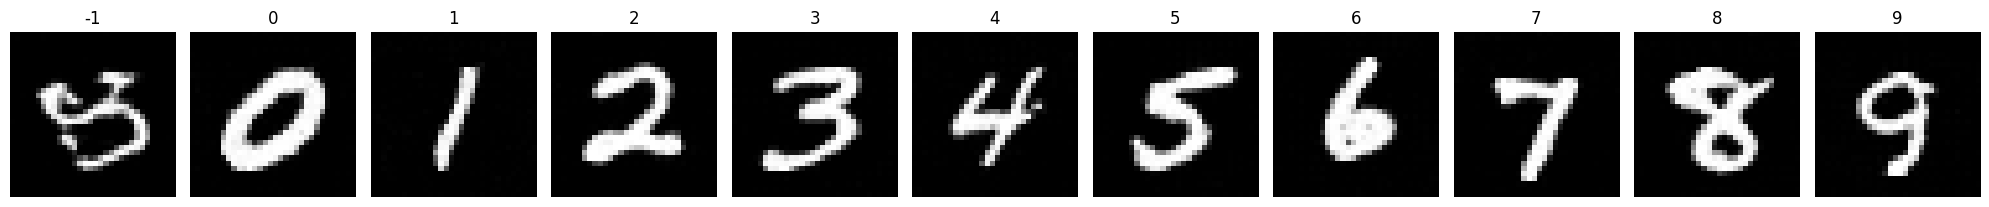

Epoch 144/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1661 - learning_rate: 9.0644e-04


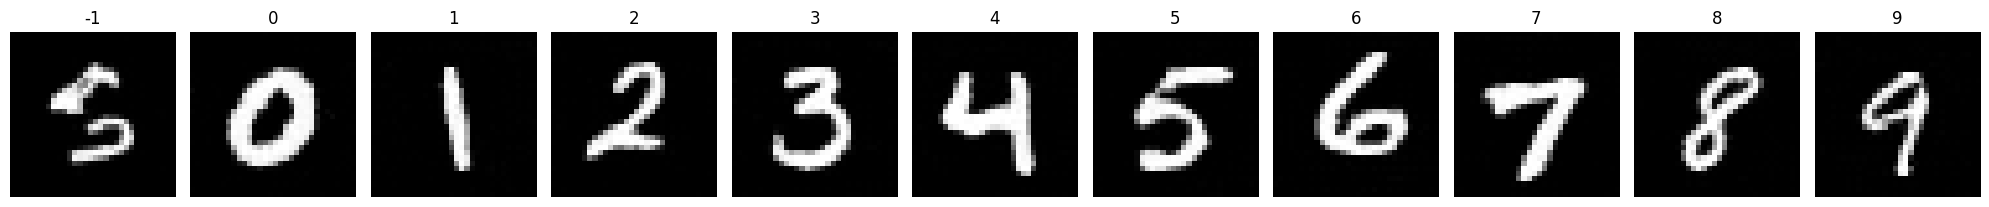

Epoch 145/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1648 - learning_rate: 8.7638e-04


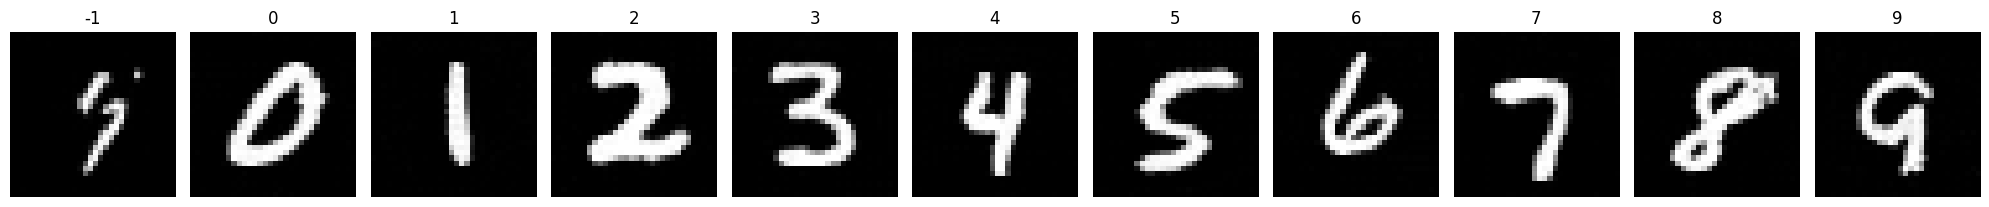

Epoch 146/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0205 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1661 - learning_rate: 8.4672e-04


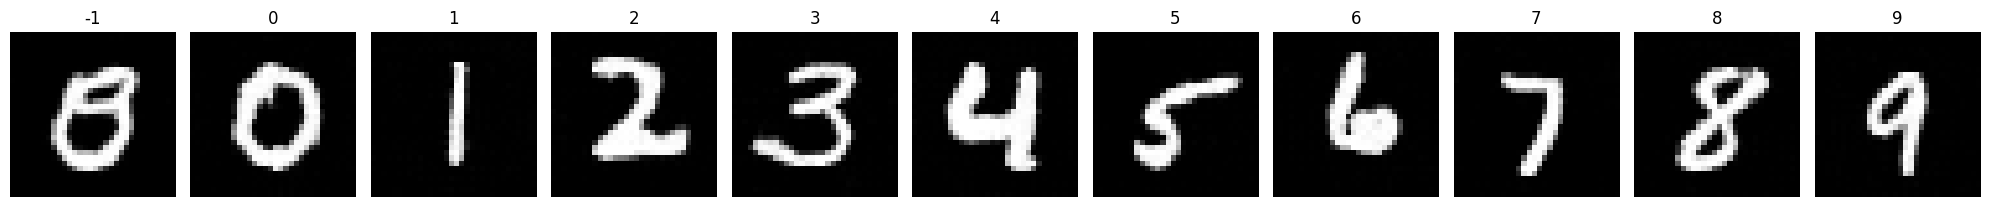

Epoch 147/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1645 - learning_rate: 8.1747e-04


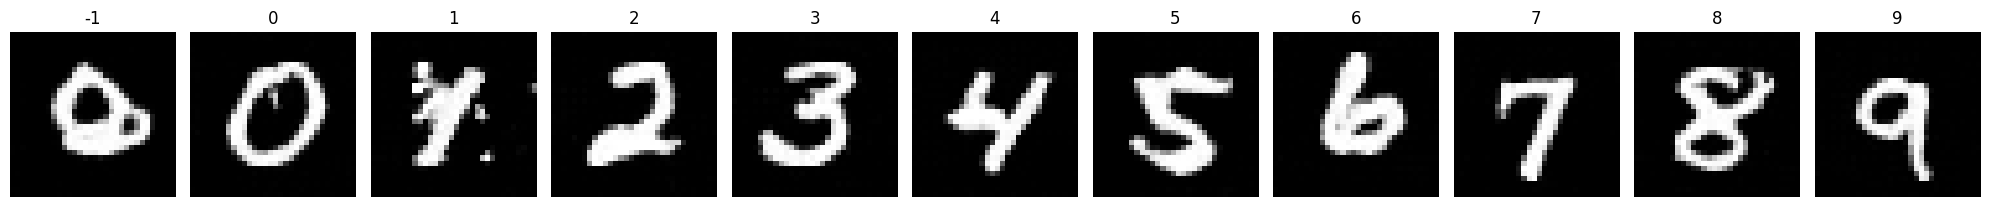

Epoch 148/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0206 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1641 - learning_rate: 7.8863e-04


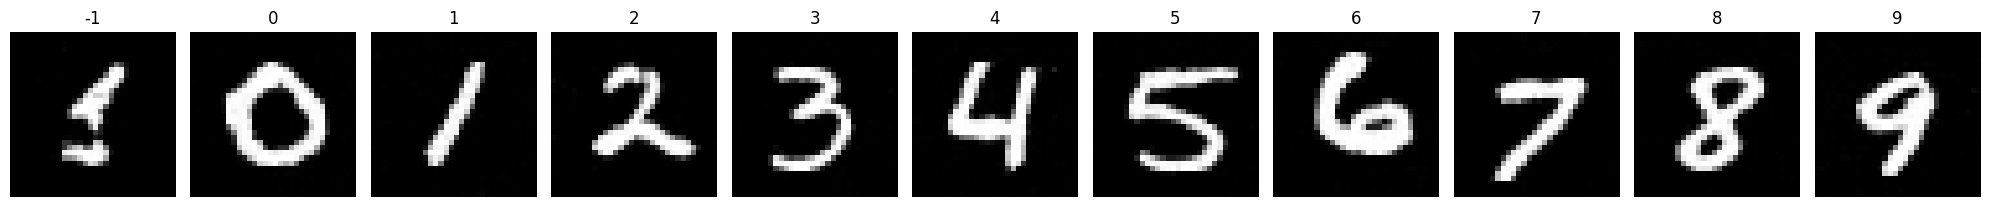

Epoch 149/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0341 - val_noise_loss: 0.0341 - val_image_loss: 0.1686 - learning_rate: 7.6022e-04


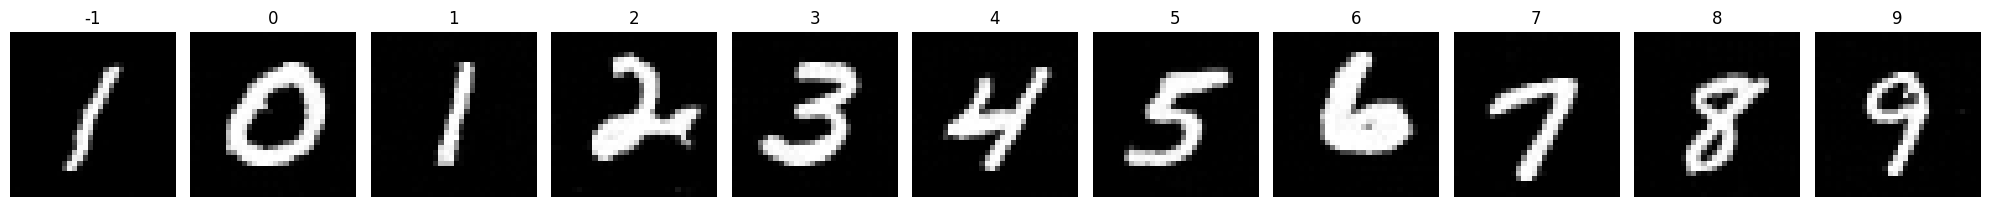

Epoch 150/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1673 - learning_rate: 7.3223e-04


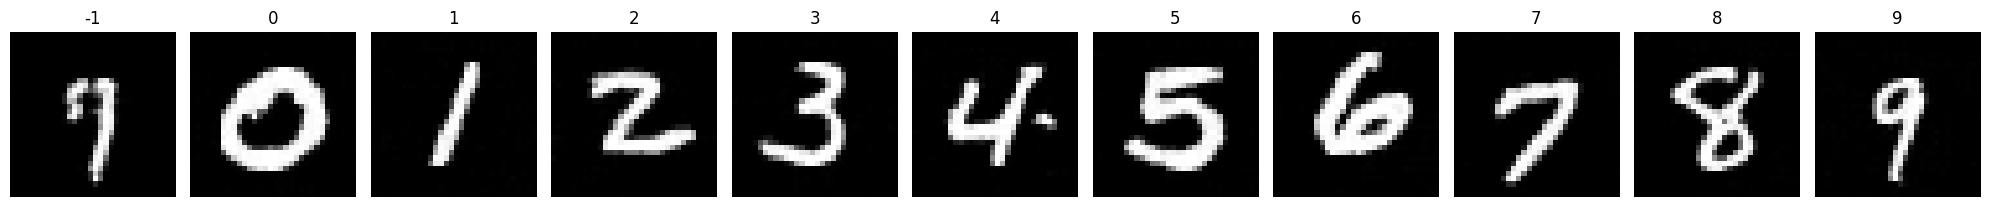

Epoch 151/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0206 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1641 - learning_rate: 7.0468e-04


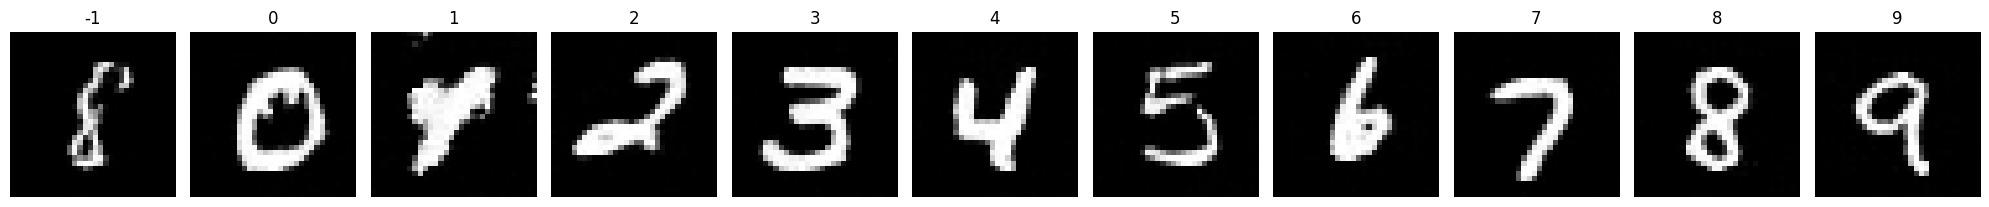

Epoch 152/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0206 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1654 - learning_rate: 6.7758e-04


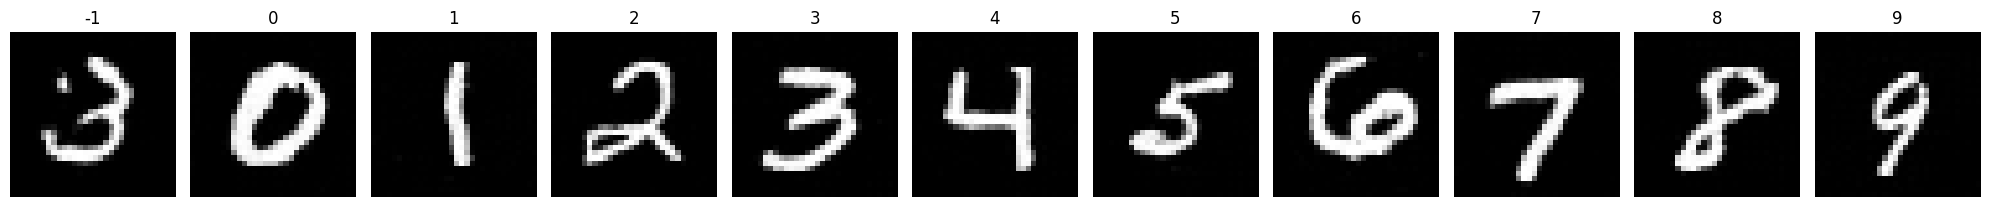

Epoch 153/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1657 - learning_rate: 6.5092e-04


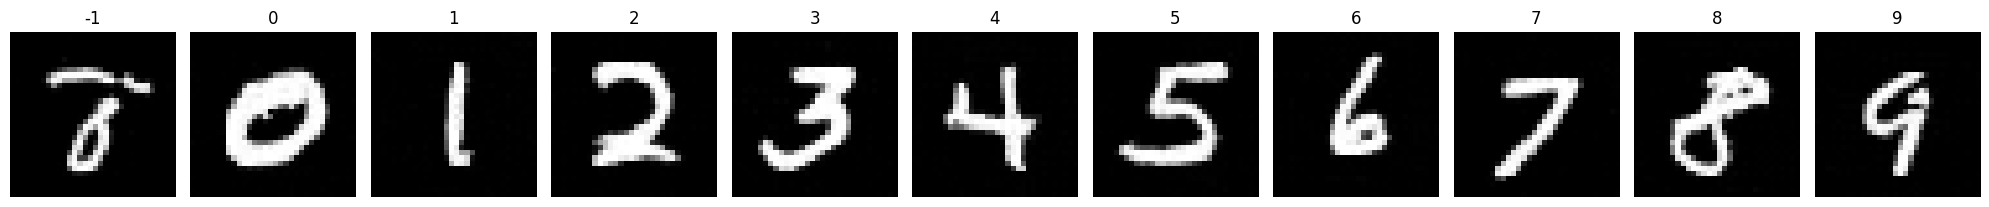

Epoch 154/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0204 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1629 - learning_rate: 6.2472e-04


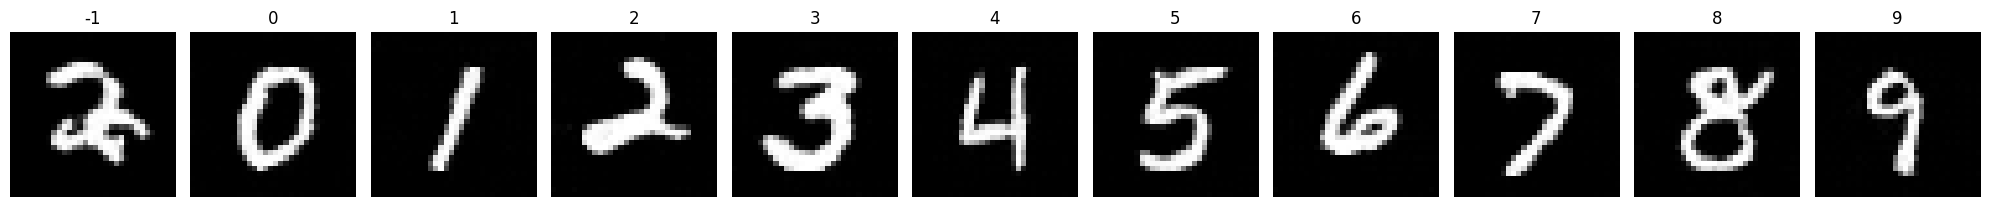

Epoch 155/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0204 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1675 - learning_rate: 5.9898e-04


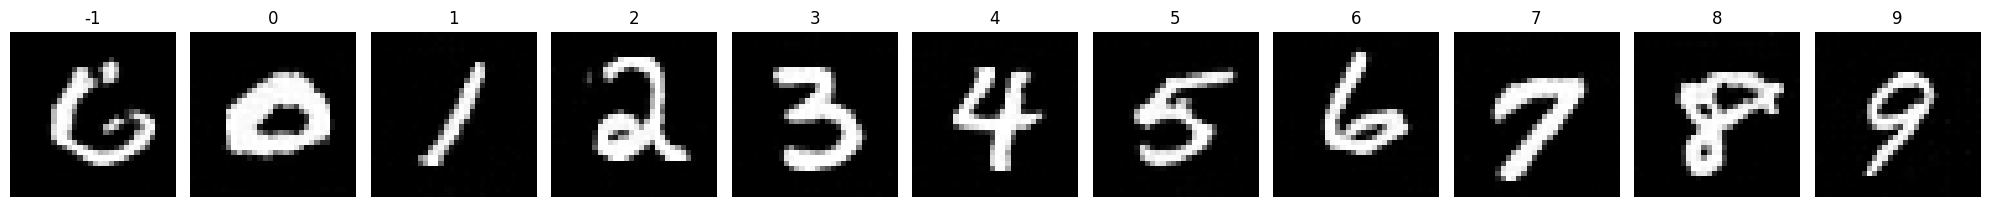

Epoch 156/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0204 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1638 - learning_rate: 5.7372e-04


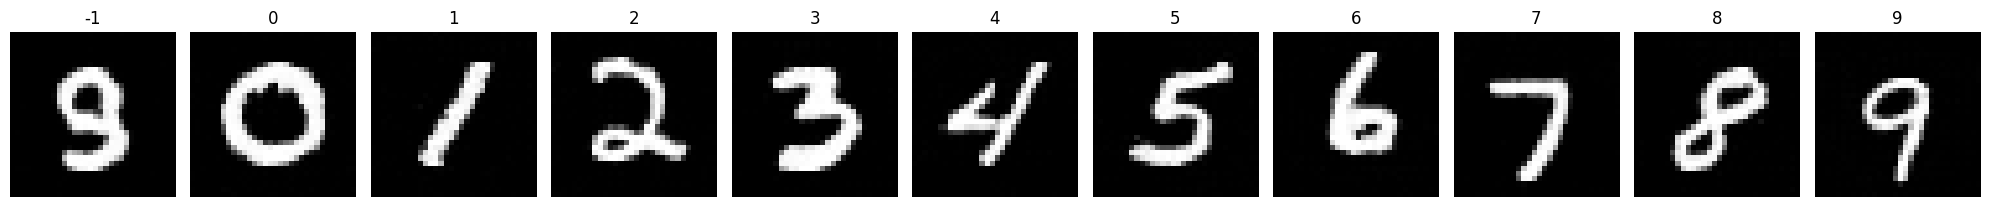

Epoch 157/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0205 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1666 - learning_rate: 5.4892e-04


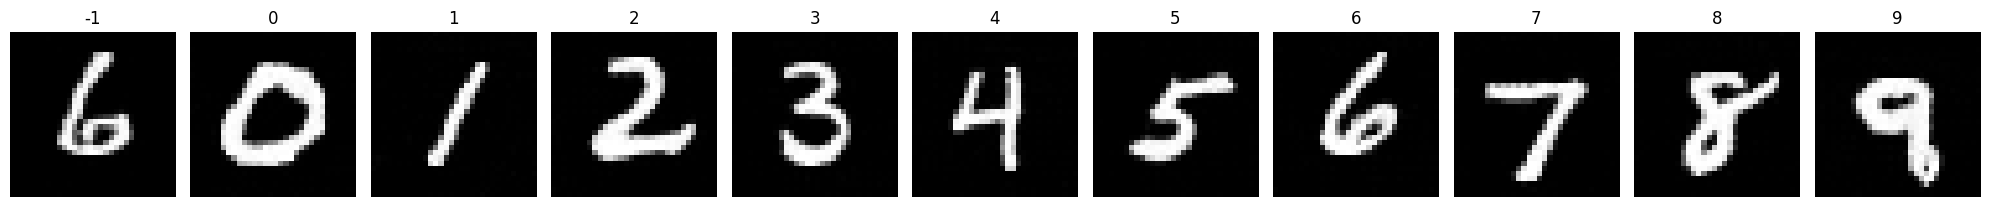

Epoch 158/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0205 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1646 - learning_rate: 5.2461e-04


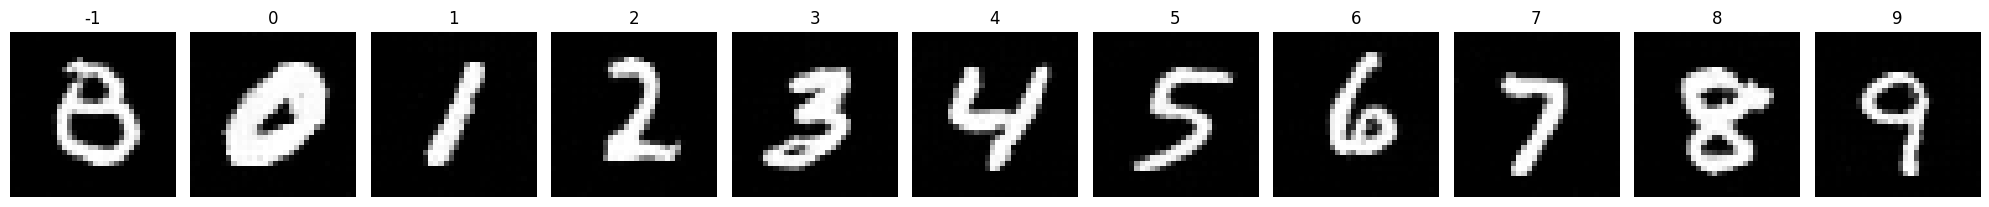

Epoch 159/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0205 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1663 - learning_rate: 5.0079e-04


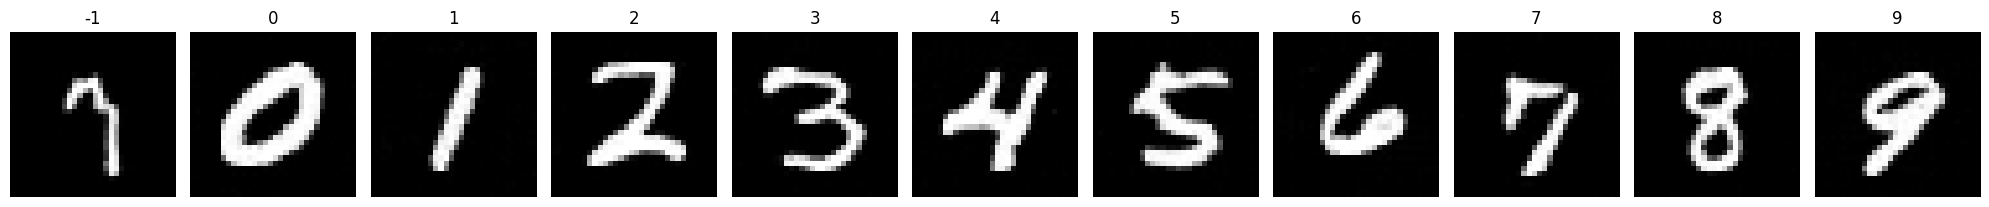

Epoch 160/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1675 - learning_rate: 4.7746e-04


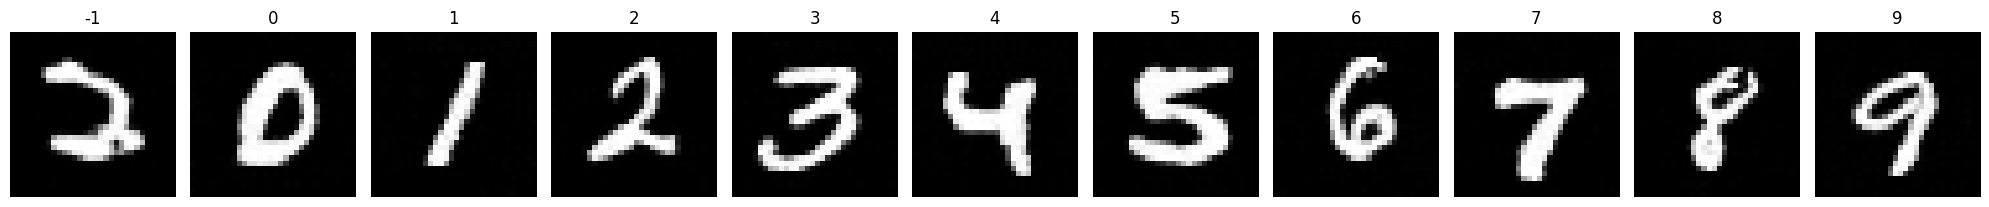

Epoch 161/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0204 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1636 - learning_rate: 4.5463e-04


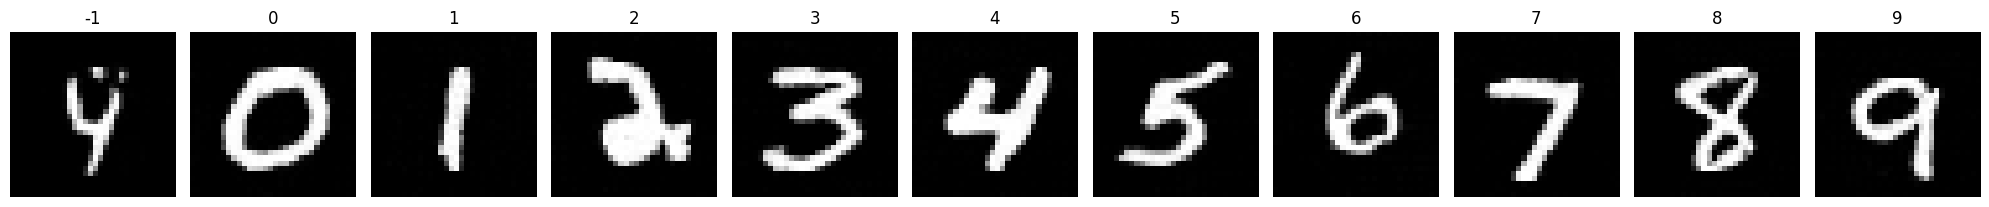

Epoch 162/200
468/468 [==============================] - 48s 102ms/step - noise_loss: 0.0203 - val_loss: 0.0344 - val_noise_loss: 0.0344 - val_image_loss: 0.1661 - learning_rate: 4.3230e-04


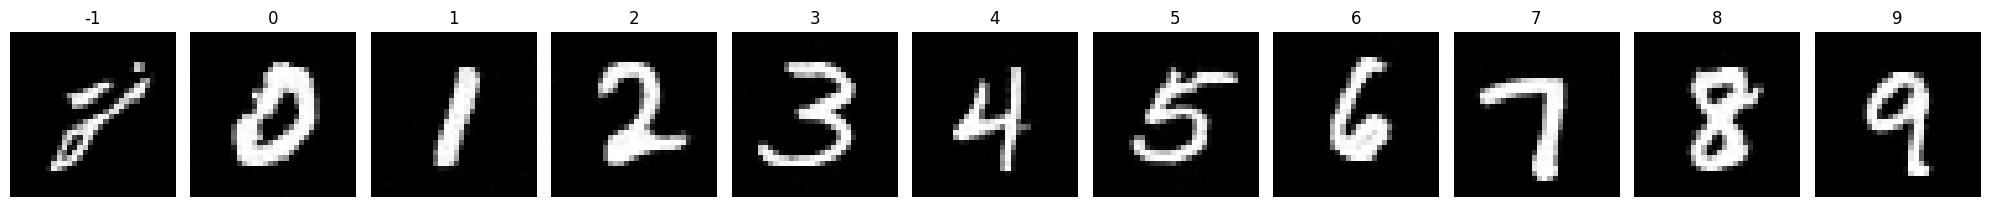

Epoch 163/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0204 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1659 - learning_rate: 4.1048e-04


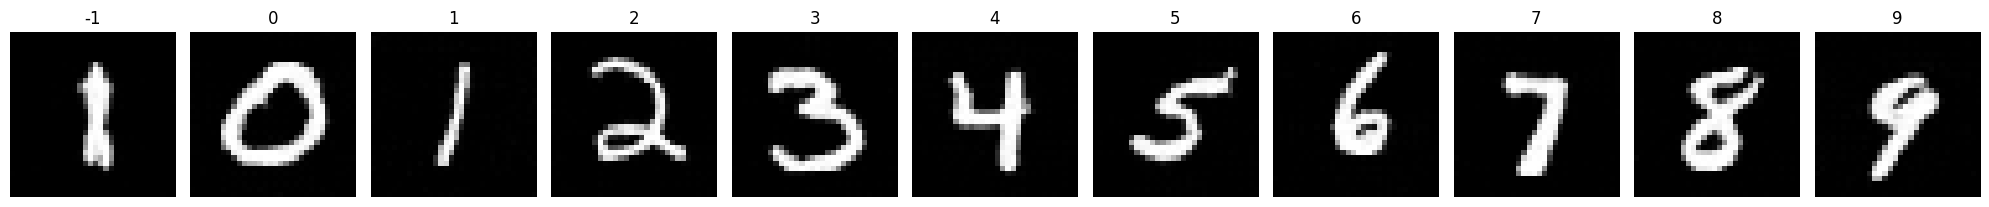

Epoch 164/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1610 - learning_rate: 3.8918e-04


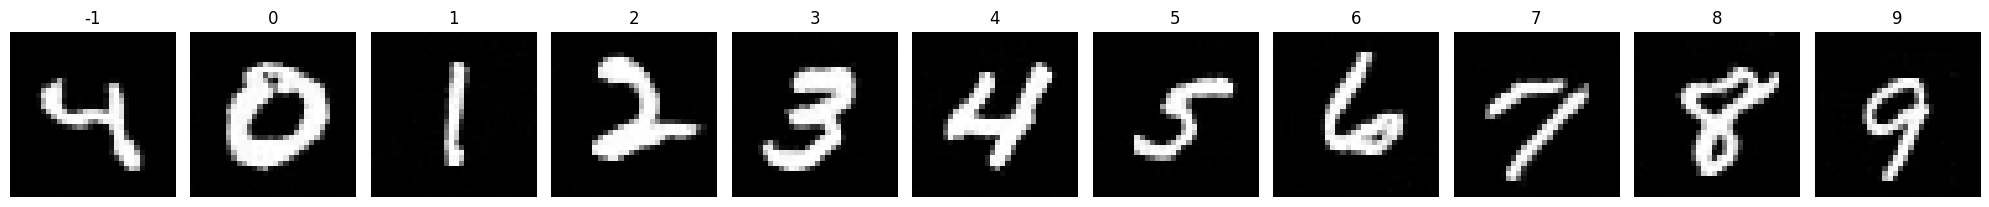

Epoch 165/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1686 - learning_rate: 3.6840e-04


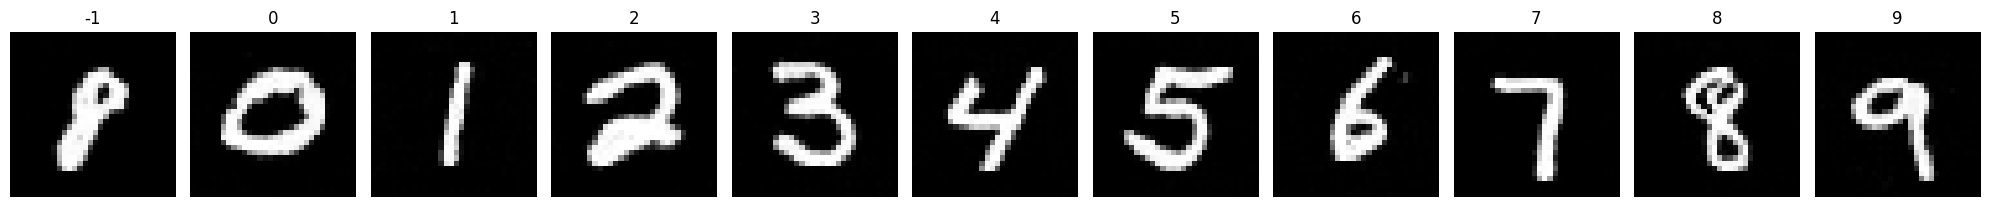

Epoch 166/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0342 - val_noise_loss: 0.0342 - val_image_loss: 0.1670 - learning_rate: 3.4814e-04


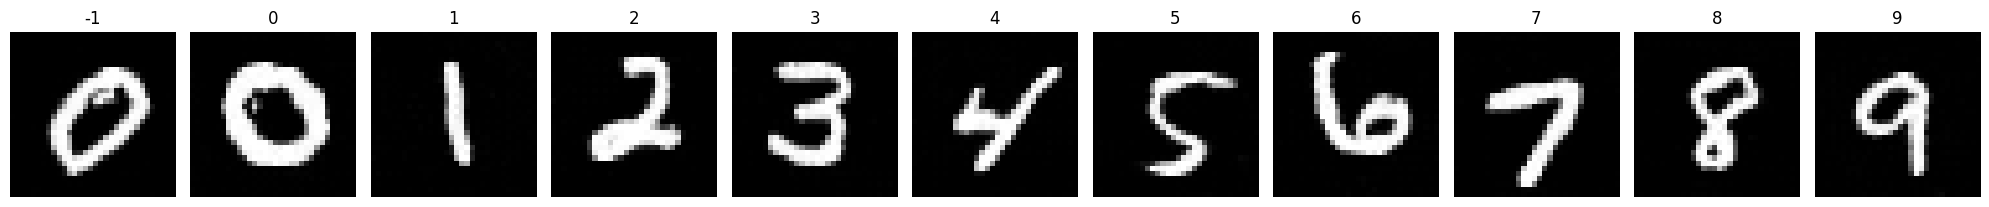

Epoch 167/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1727 - learning_rate: 3.2842e-04


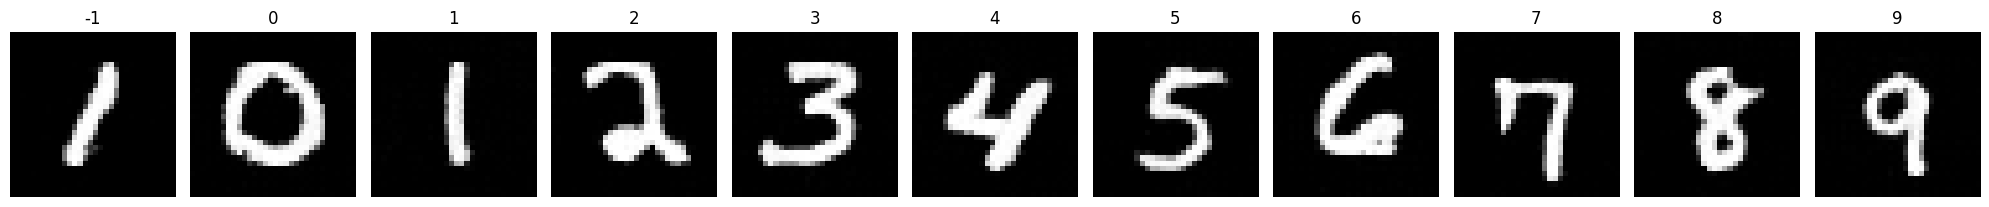

Epoch 168/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0343 - val_noise_loss: 0.0343 - val_image_loss: 0.1670 - learning_rate: 3.0923e-04


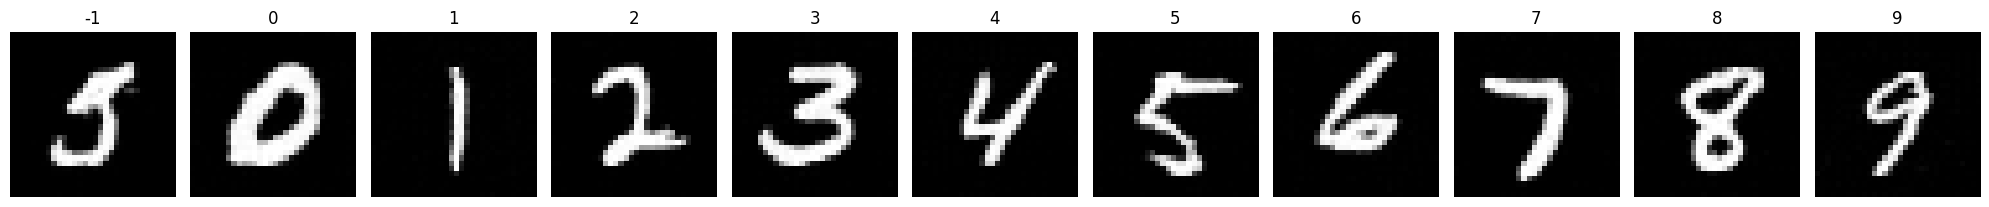

Epoch 169/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0202 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1687 - learning_rate: 2.9059e-04


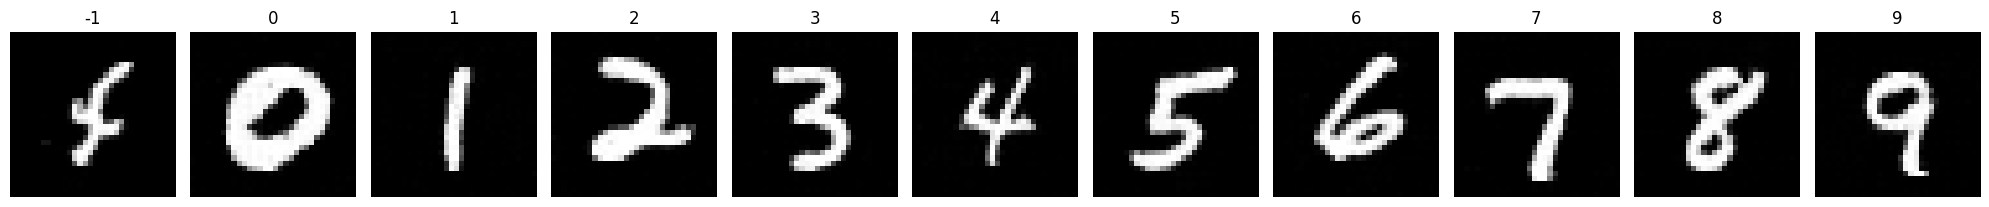

Epoch 170/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1674 - learning_rate: 2.7248e-04


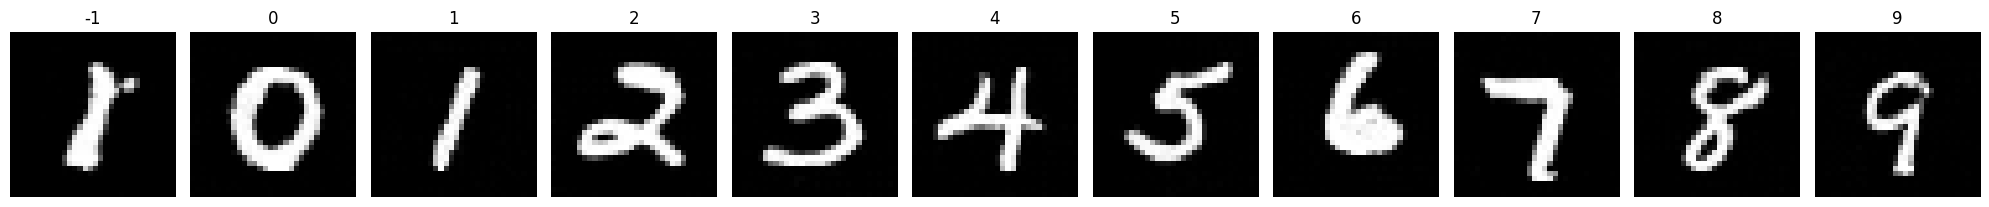

Epoch 171/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0203 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1653 - learning_rate: 2.5493e-04


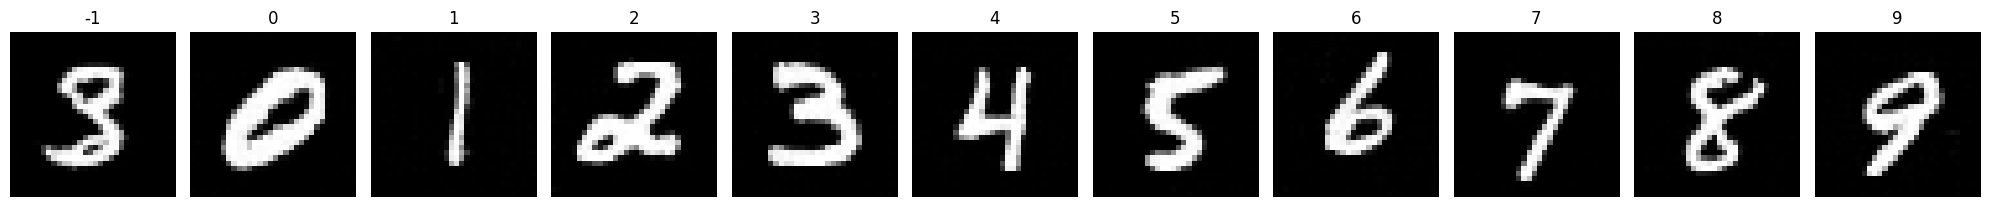

Epoch 172/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1681 - learning_rate: 2.3793e-04


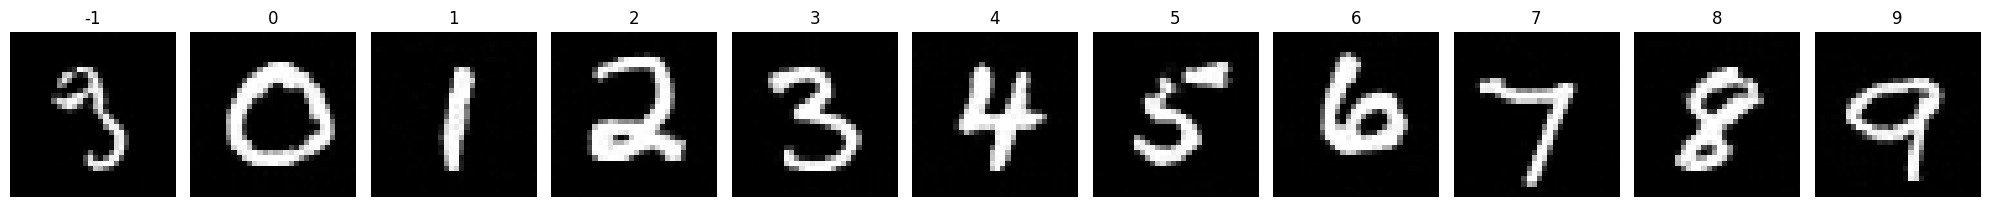

Epoch 173/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0204 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1696 - learning_rate: 2.2149e-04


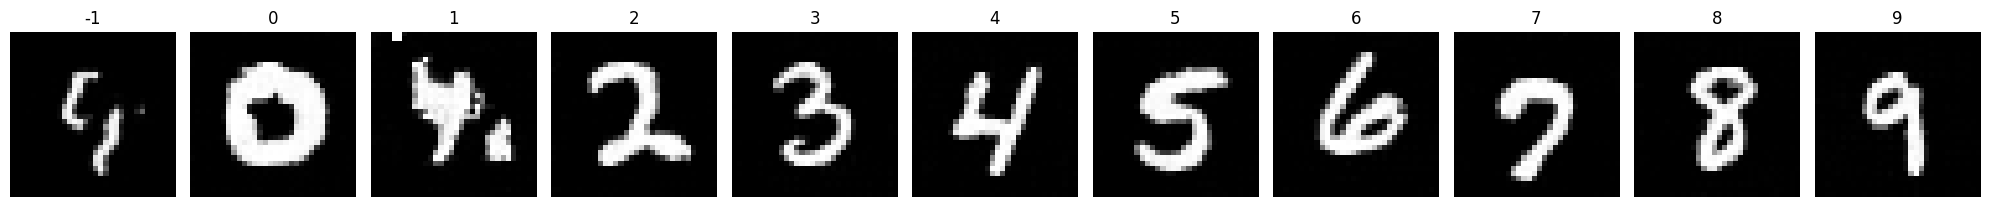

Epoch 174/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1643 - learning_rate: 2.0561e-04


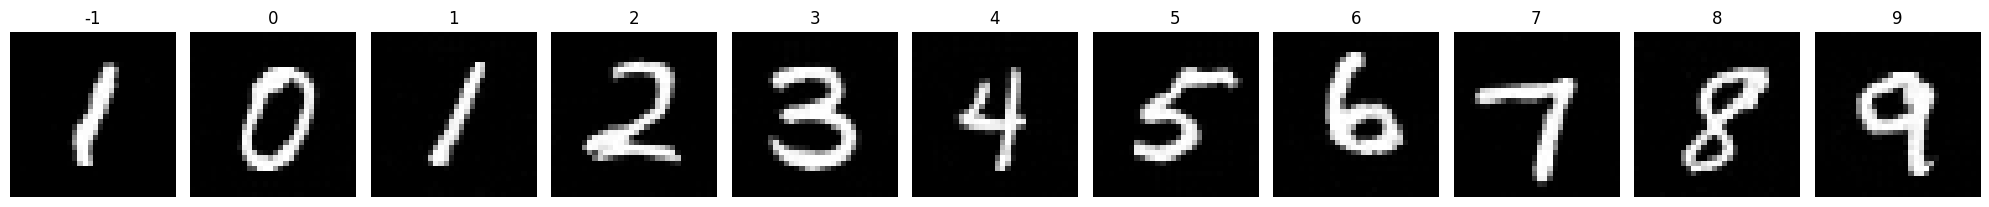

Epoch 175/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0203 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1685 - learning_rate: 1.9030e-04


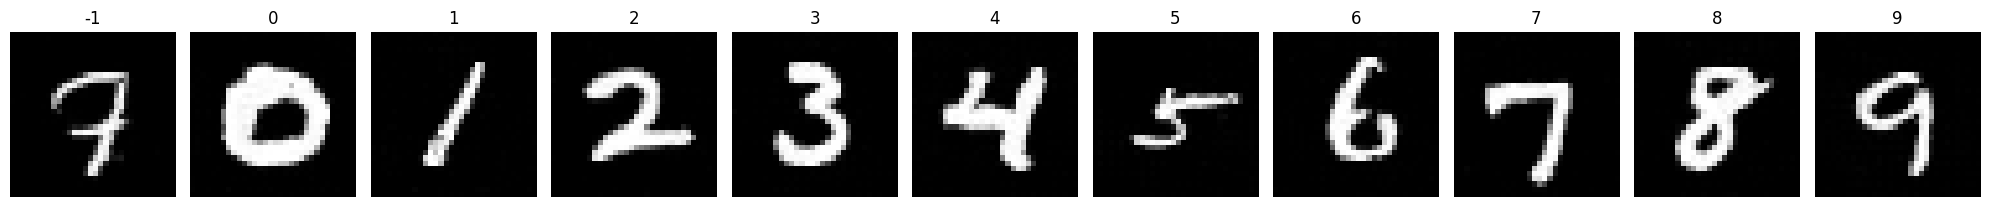

Epoch 176/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1692 - learning_rate: 1.7556e-04


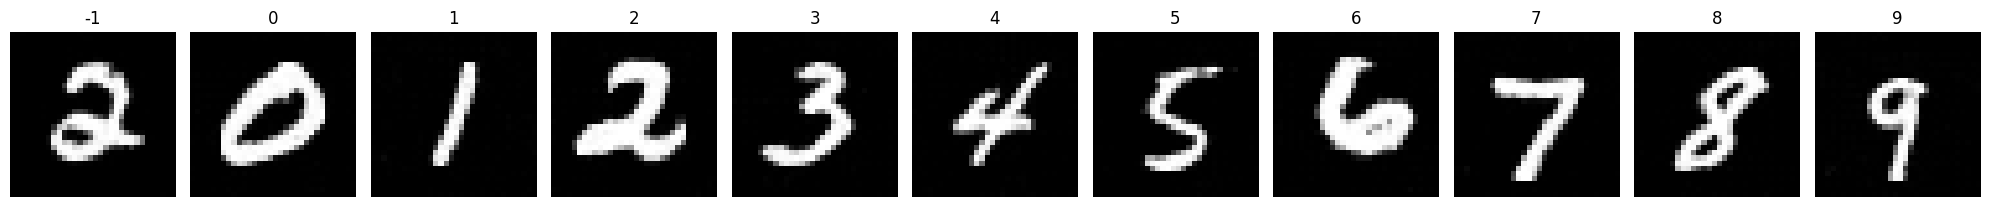

Epoch 177/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0201 - val_loss: 0.0345 - val_noise_loss: 0.0345 - val_image_loss: 0.1645 - learning_rate: 1.6139e-04


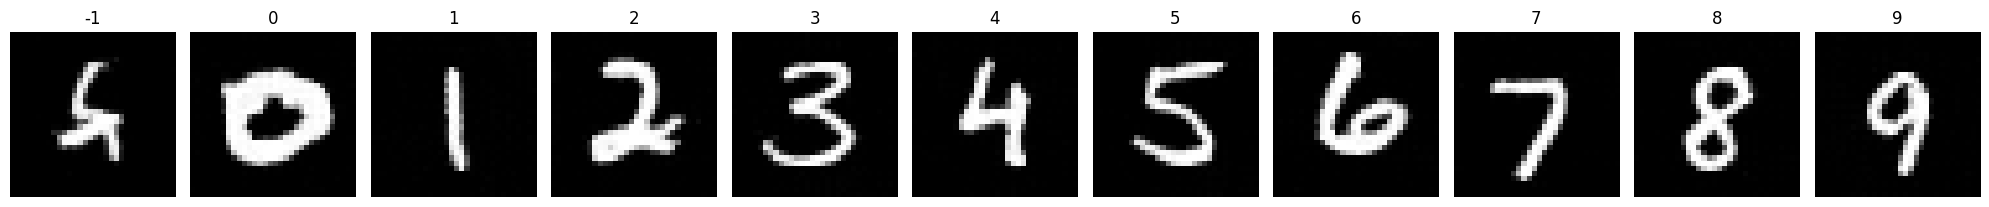

Epoch 178/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1669 - learning_rate: 1.4780e-04


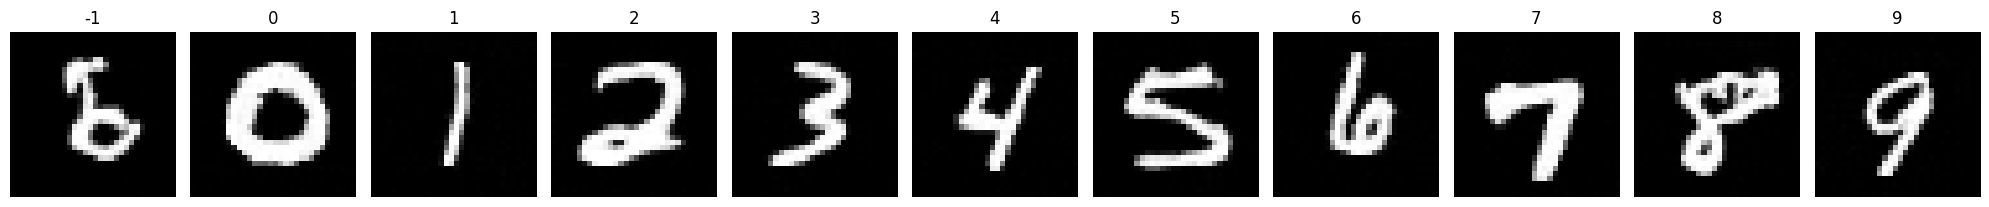

Epoch 179/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1675 - learning_rate: 1.3479e-04


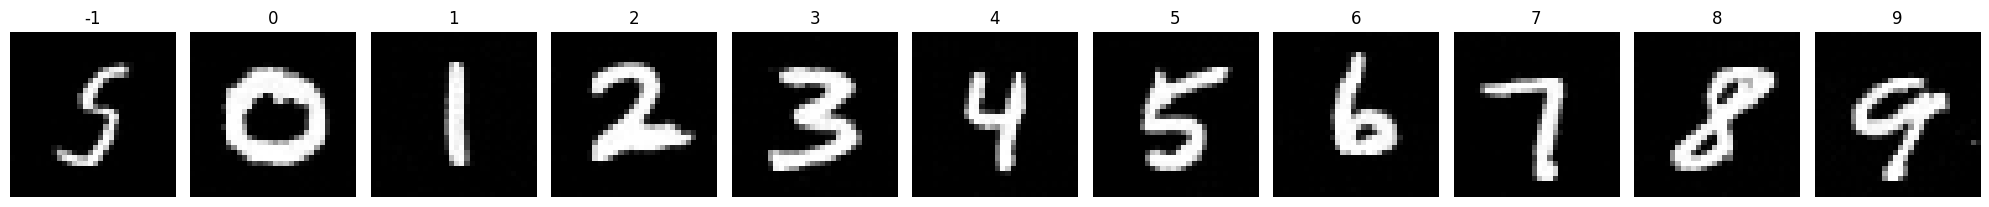

Epoch 180/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1659 - learning_rate: 1.2236e-04


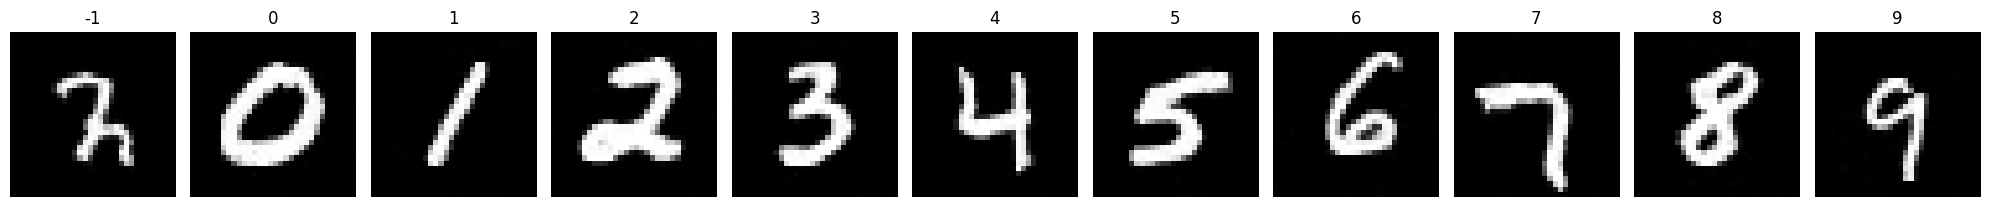

Epoch 181/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0351 - val_noise_loss: 0.0351 - val_image_loss: 0.1642 - learning_rate: 1.1052e-04


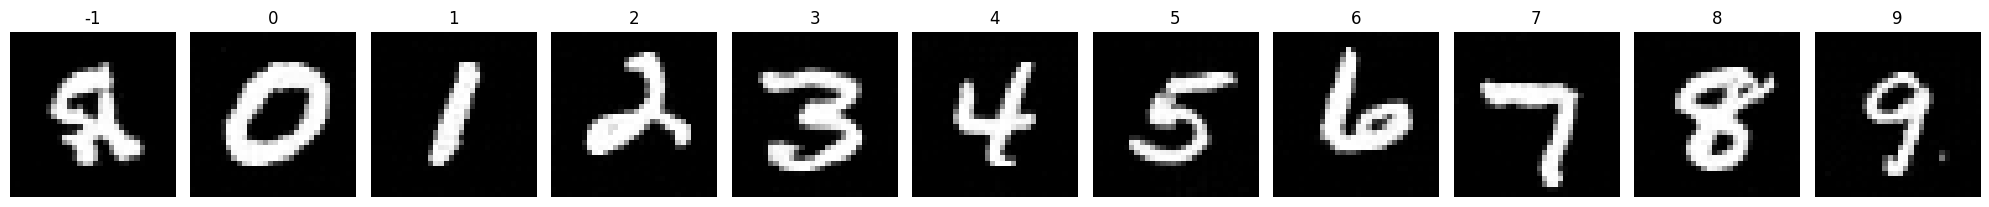

Epoch 182/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0202 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1681 - learning_rate: 9.9266e-05


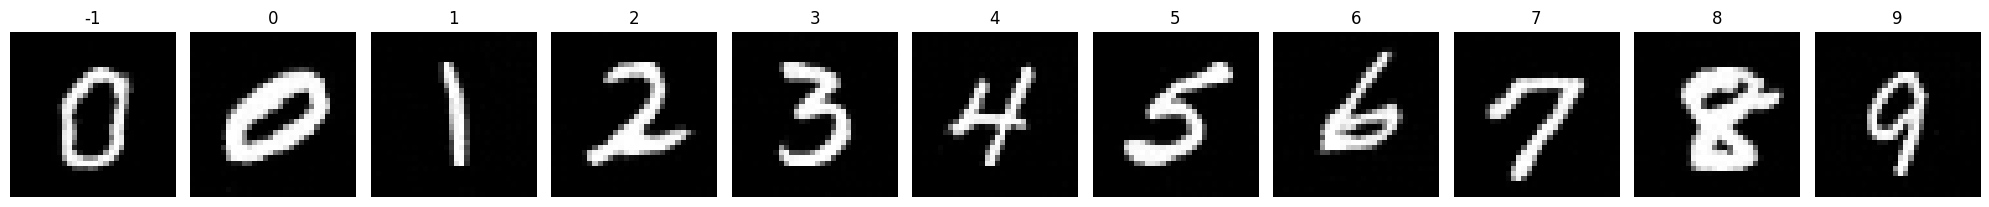

Epoch 183/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1706 - learning_rate: 8.8606e-05


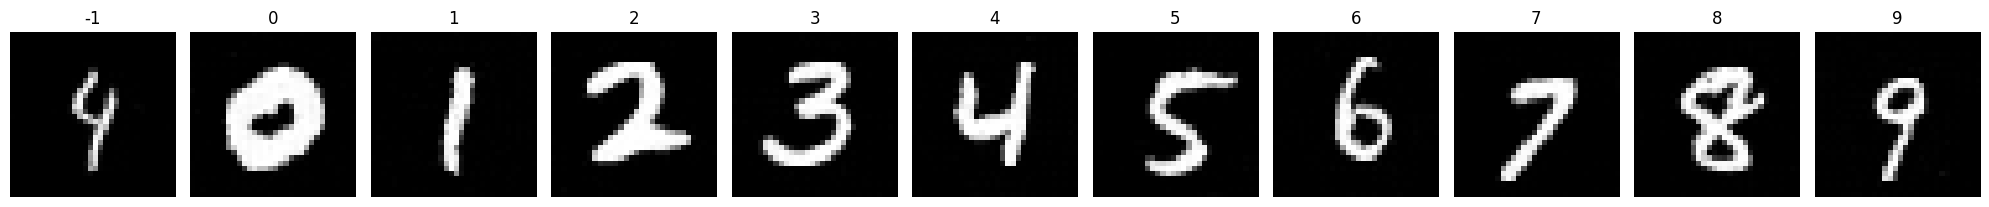

Epoch 184/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1647 - learning_rate: 7.8542e-05


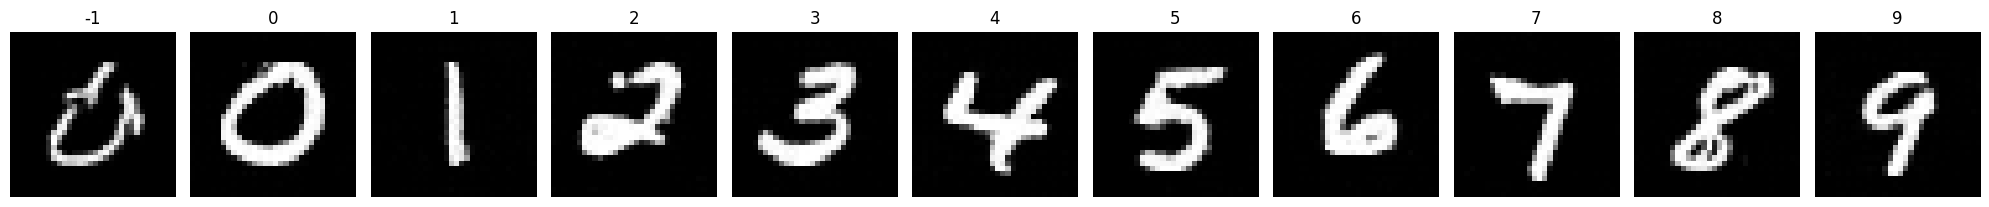

Epoch 185/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0201 - val_loss: 0.0352 - val_noise_loss: 0.0352 - val_image_loss: 0.1602 - learning_rate: 6.9075e-05


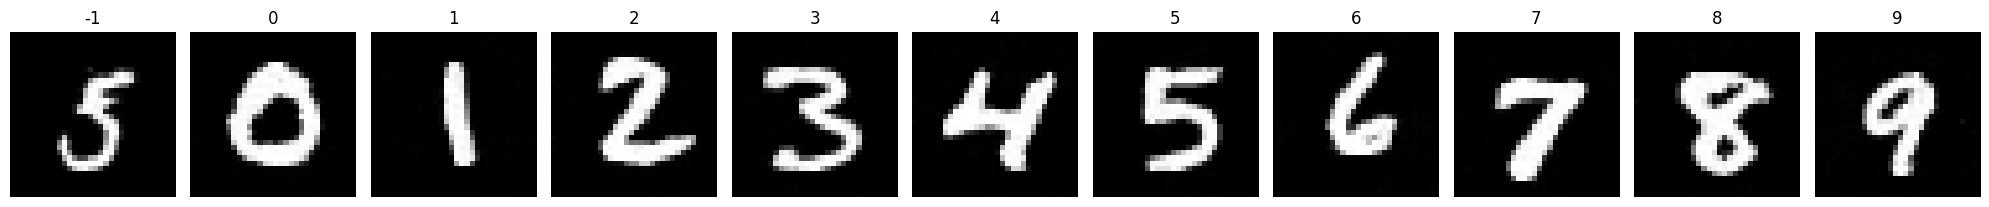

Epoch 186/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0353 - val_noise_loss: 0.0353 - val_image_loss: 0.1597 - learning_rate: 6.0208e-05


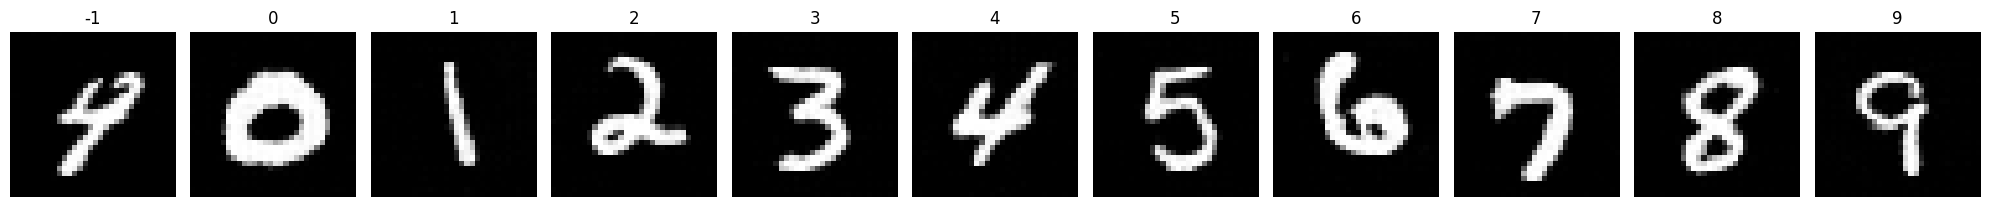

Epoch 187/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1671 - learning_rate: 5.1943e-05


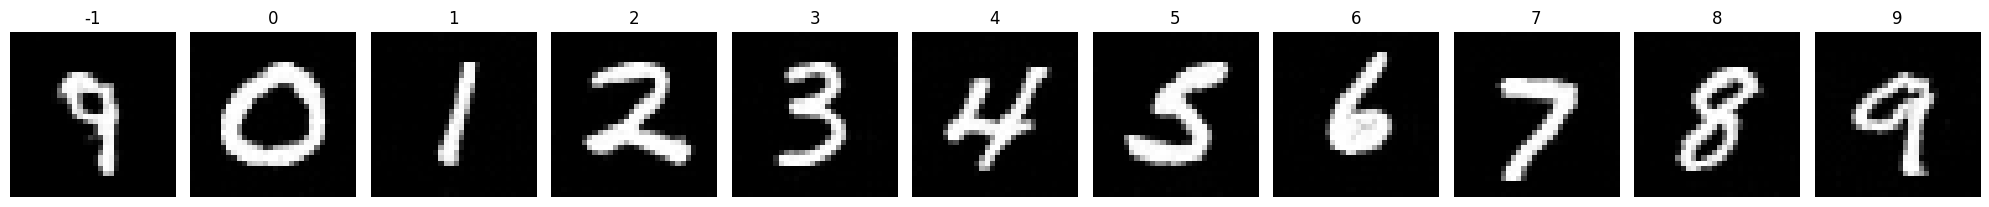

Epoch 188/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1642 - learning_rate: 4.4282e-05


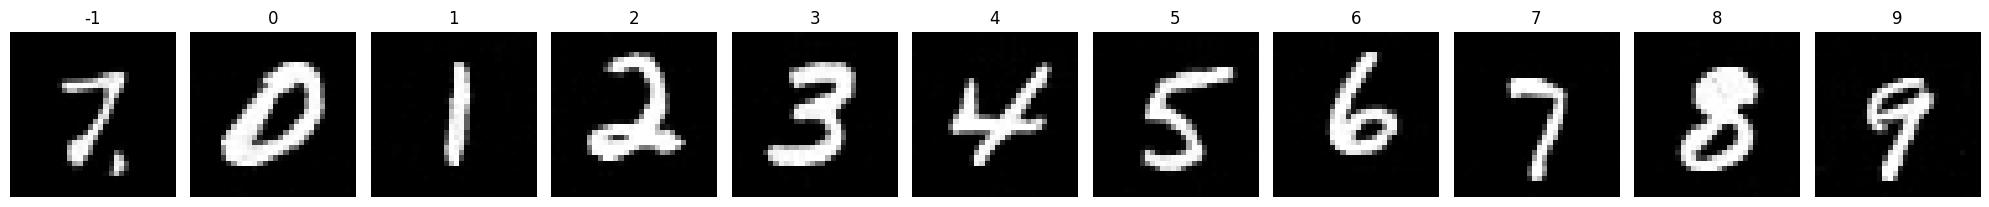

Epoch 189/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1660 - learning_rate: 3.7227e-05


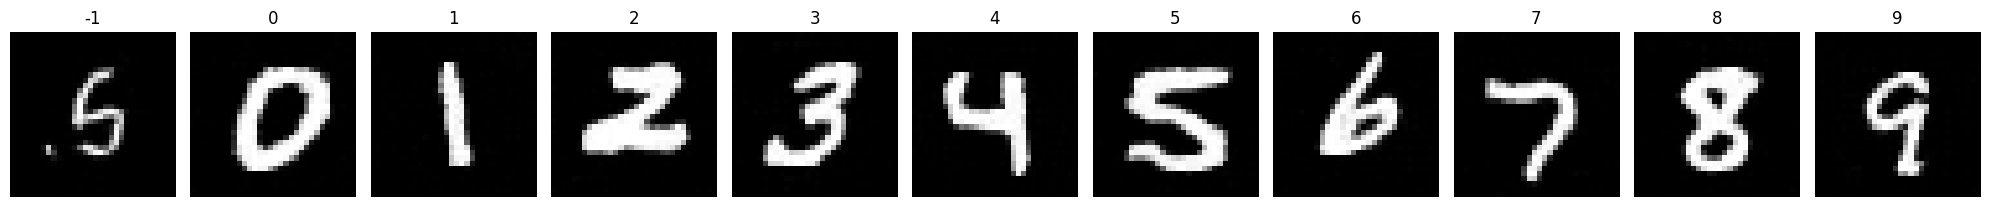

Epoch 190/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1698 - learning_rate: 3.0779e-05


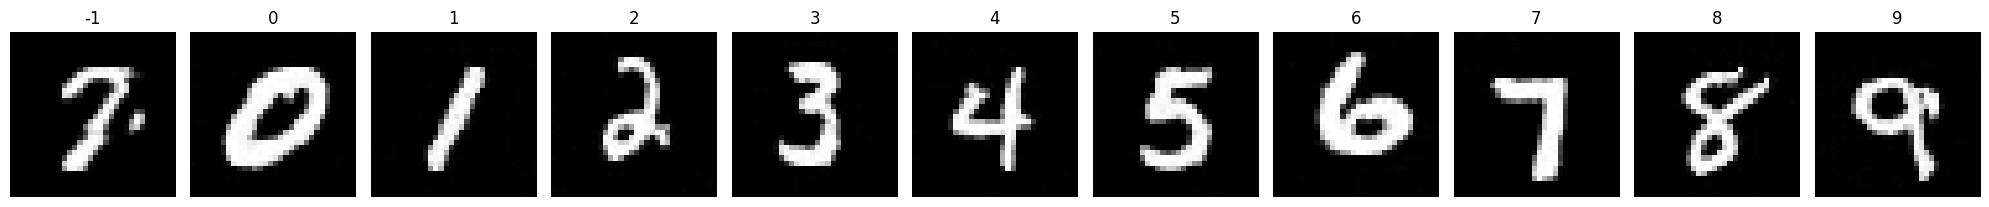

Epoch 191/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1649 - learning_rate: 2.4941e-05


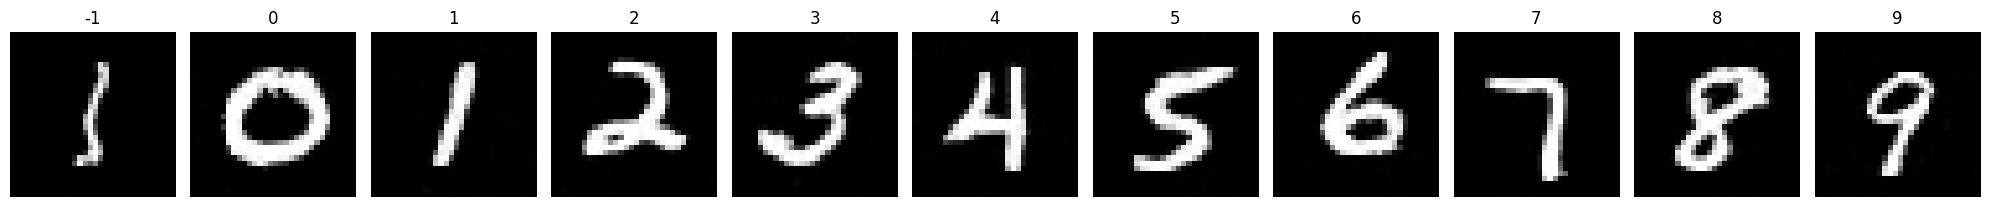

Epoch 192/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1698 - learning_rate: 1.9713e-05


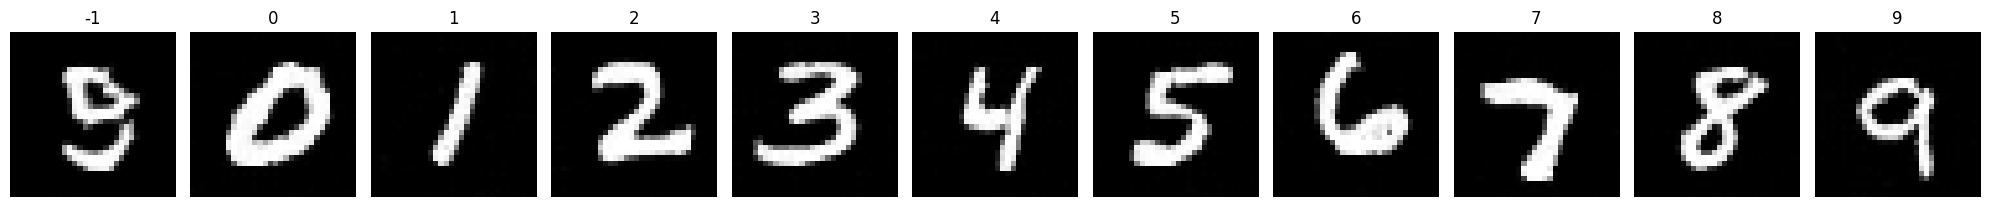

Epoch 193/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0200 - val_loss: 0.0347 - val_noise_loss: 0.0347 - val_image_loss: 0.1737 - learning_rate: 1.5098e-05


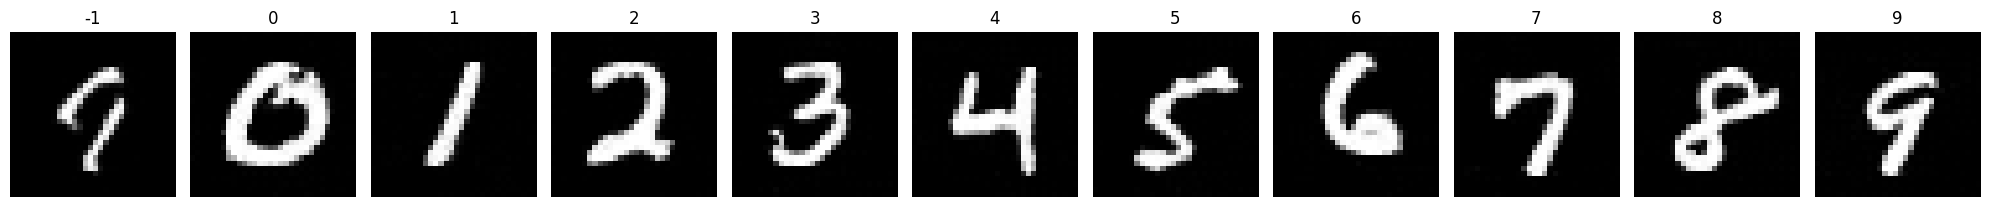

Epoch 194/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0202 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1672 - learning_rate: 1.1095e-05


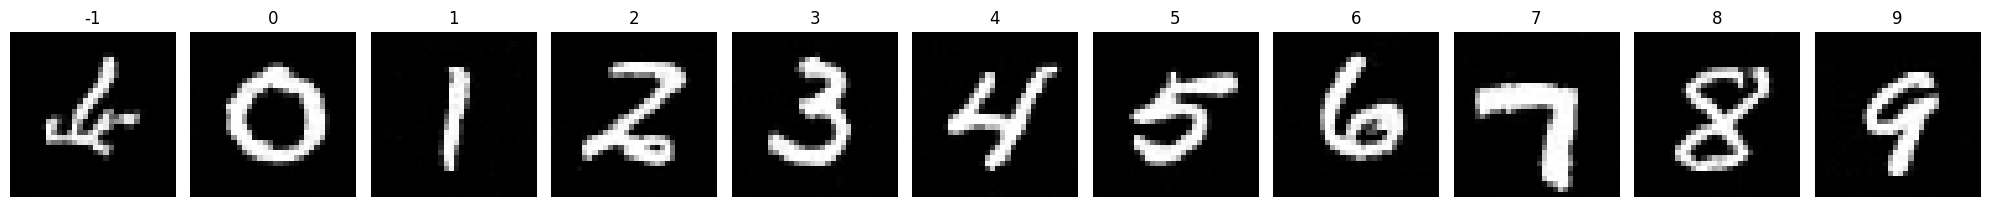

Epoch 195/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0201 - val_loss: 0.0348 - val_noise_loss: 0.0348 - val_image_loss: 0.1681 - learning_rate: 7.7066e-06


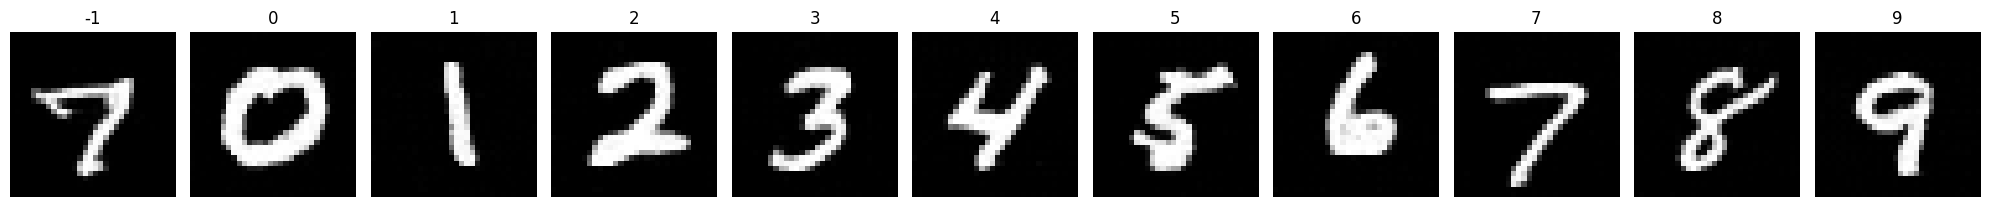

Epoch 196/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0201 - val_loss: 0.0349 - val_noise_loss: 0.0349 - val_image_loss: 0.1701 - learning_rate: 4.9332e-06


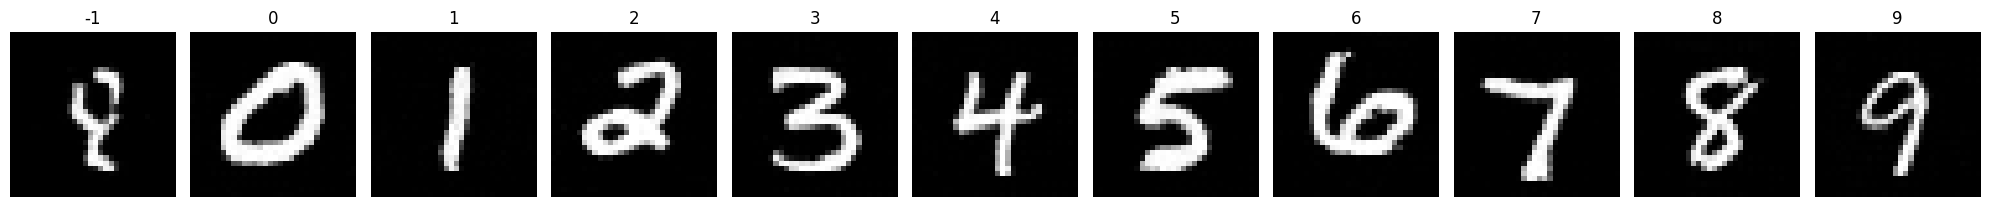

Epoch 197/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0201 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1696 - learning_rate: 2.7753e-06


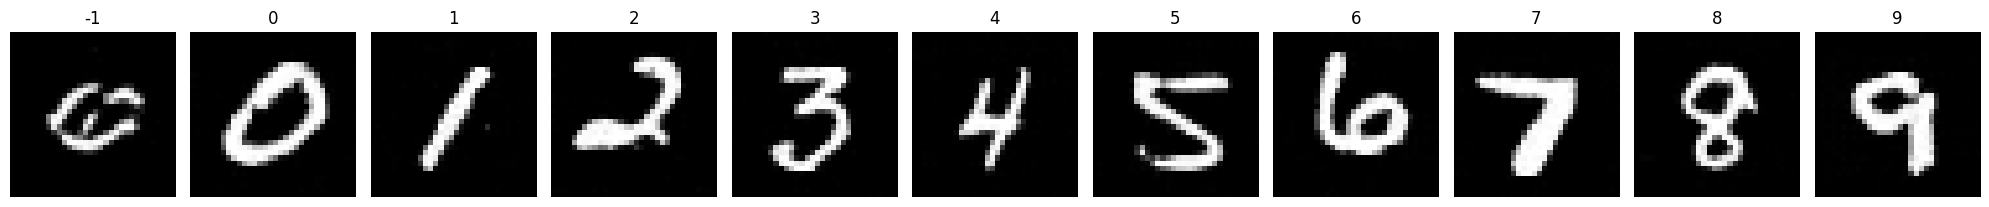

Epoch 198/200
468/468 [==============================] - 47s 101ms/step - noise_loss: 0.0203 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1687 - learning_rate: 1.2337e-06


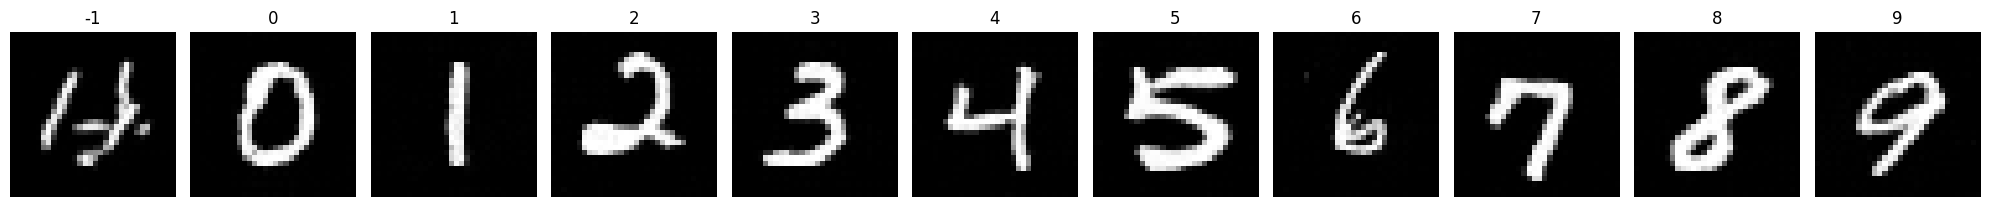

Epoch 199/200
468/468 [==============================] - 48s 101ms/step - noise_loss: 0.0201 - val_loss: 0.0350 - val_noise_loss: 0.0350 - val_image_loss: 0.1673 - learning_rate: 3.0845e-07


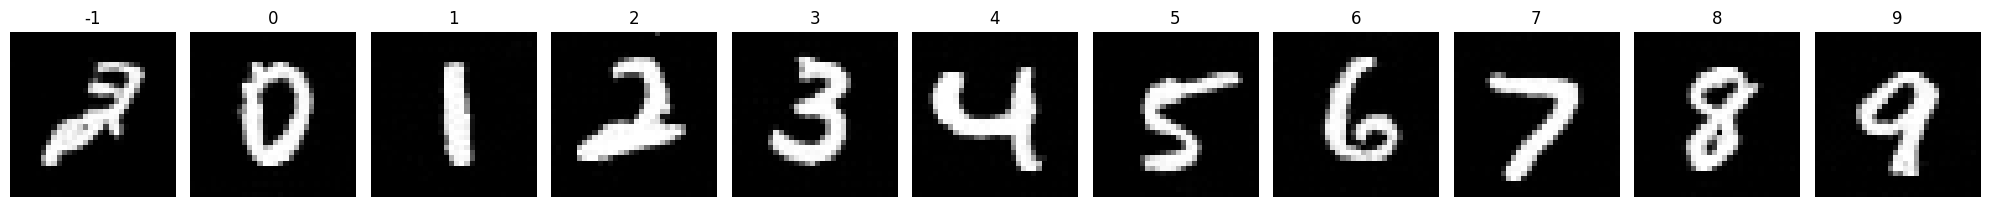

Epoch 200/200
468/468 [==============================] - 47s 100ms/step - noise_loss: 0.0201 - val_loss: 0.0346 - val_noise_loss: 0.0346 - val_image_loss: 0.1696 - learning_rate: 0.0000e+00


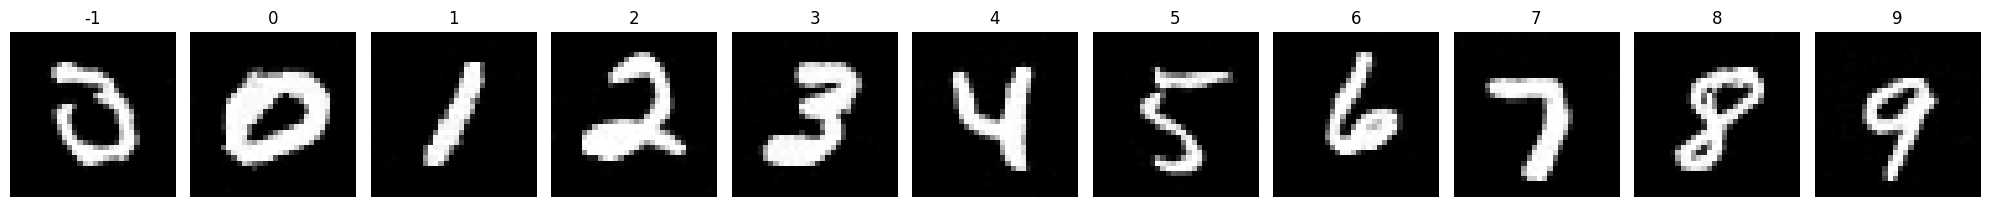

In [8]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [ ]:
model.save_weights("./models/U-DiT/model.weights.h5")

In [10]:
model.evaluate(valset, network_name="ema")

79/79 [==============================] - 6s 77ms/step - loss: 0.0349 - noise_loss: 0.0349 - image_loss: 0.1676


[0.03493165969848633, 0.03493165969848633, 0.16762803494930267]

In [11]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 9s 77ms/step - loss: 0.0352 - noise_loss: 0.0352 - image_loss: 0.1626


[0.03521593660116196, 0.03521593660116196, 0.16255630552768707]

Steps: 1000/1000


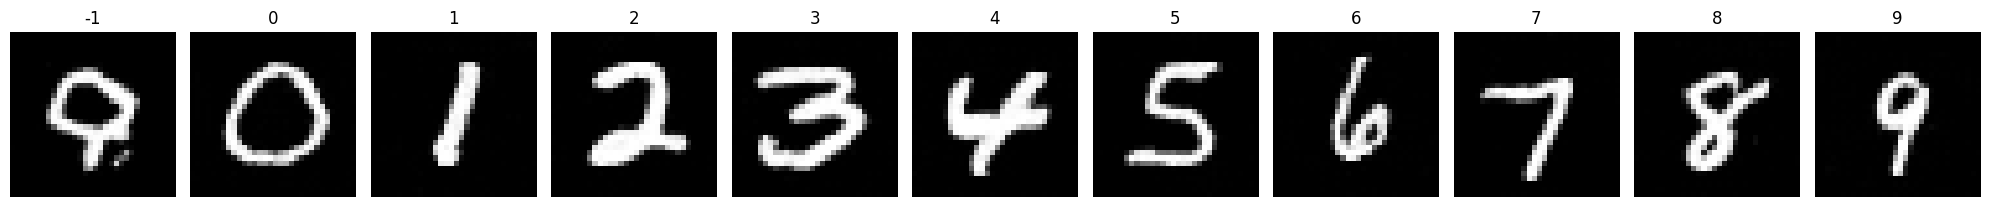

In [12]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


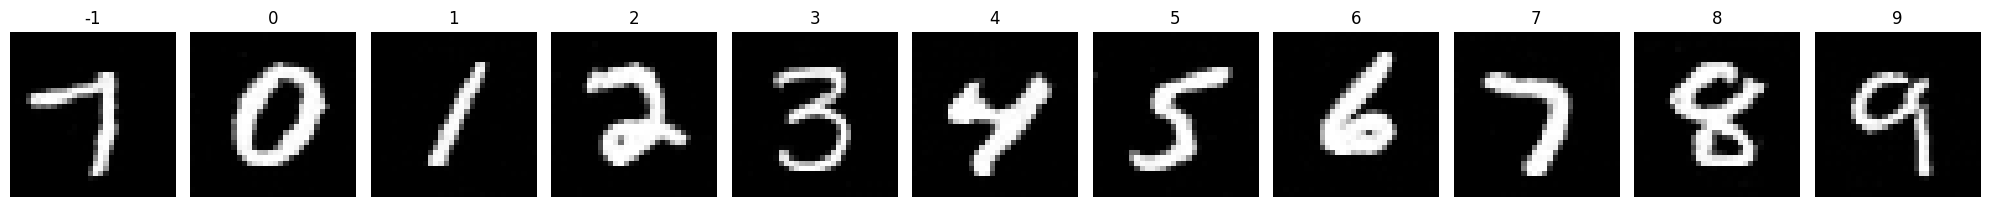

In [13]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


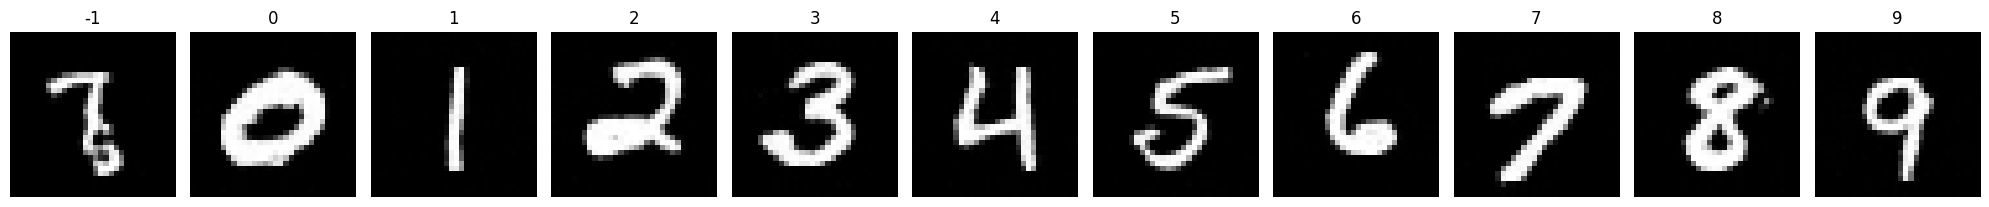

In [14]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


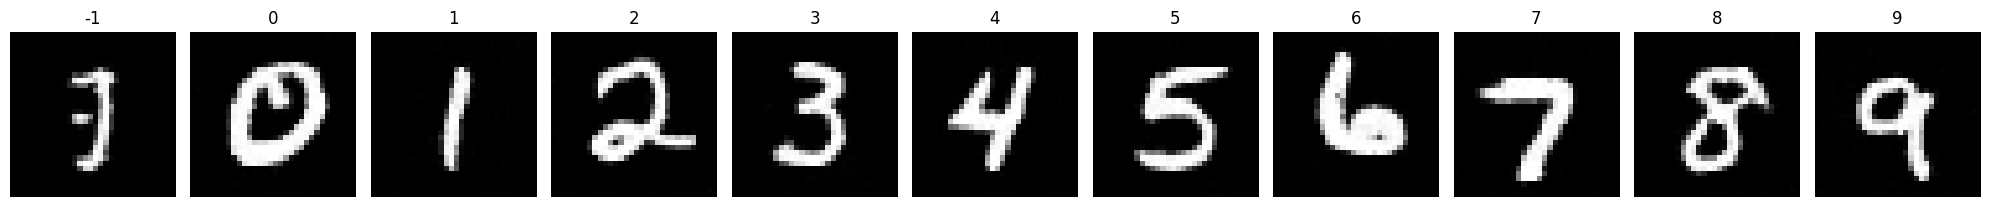

In [15]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

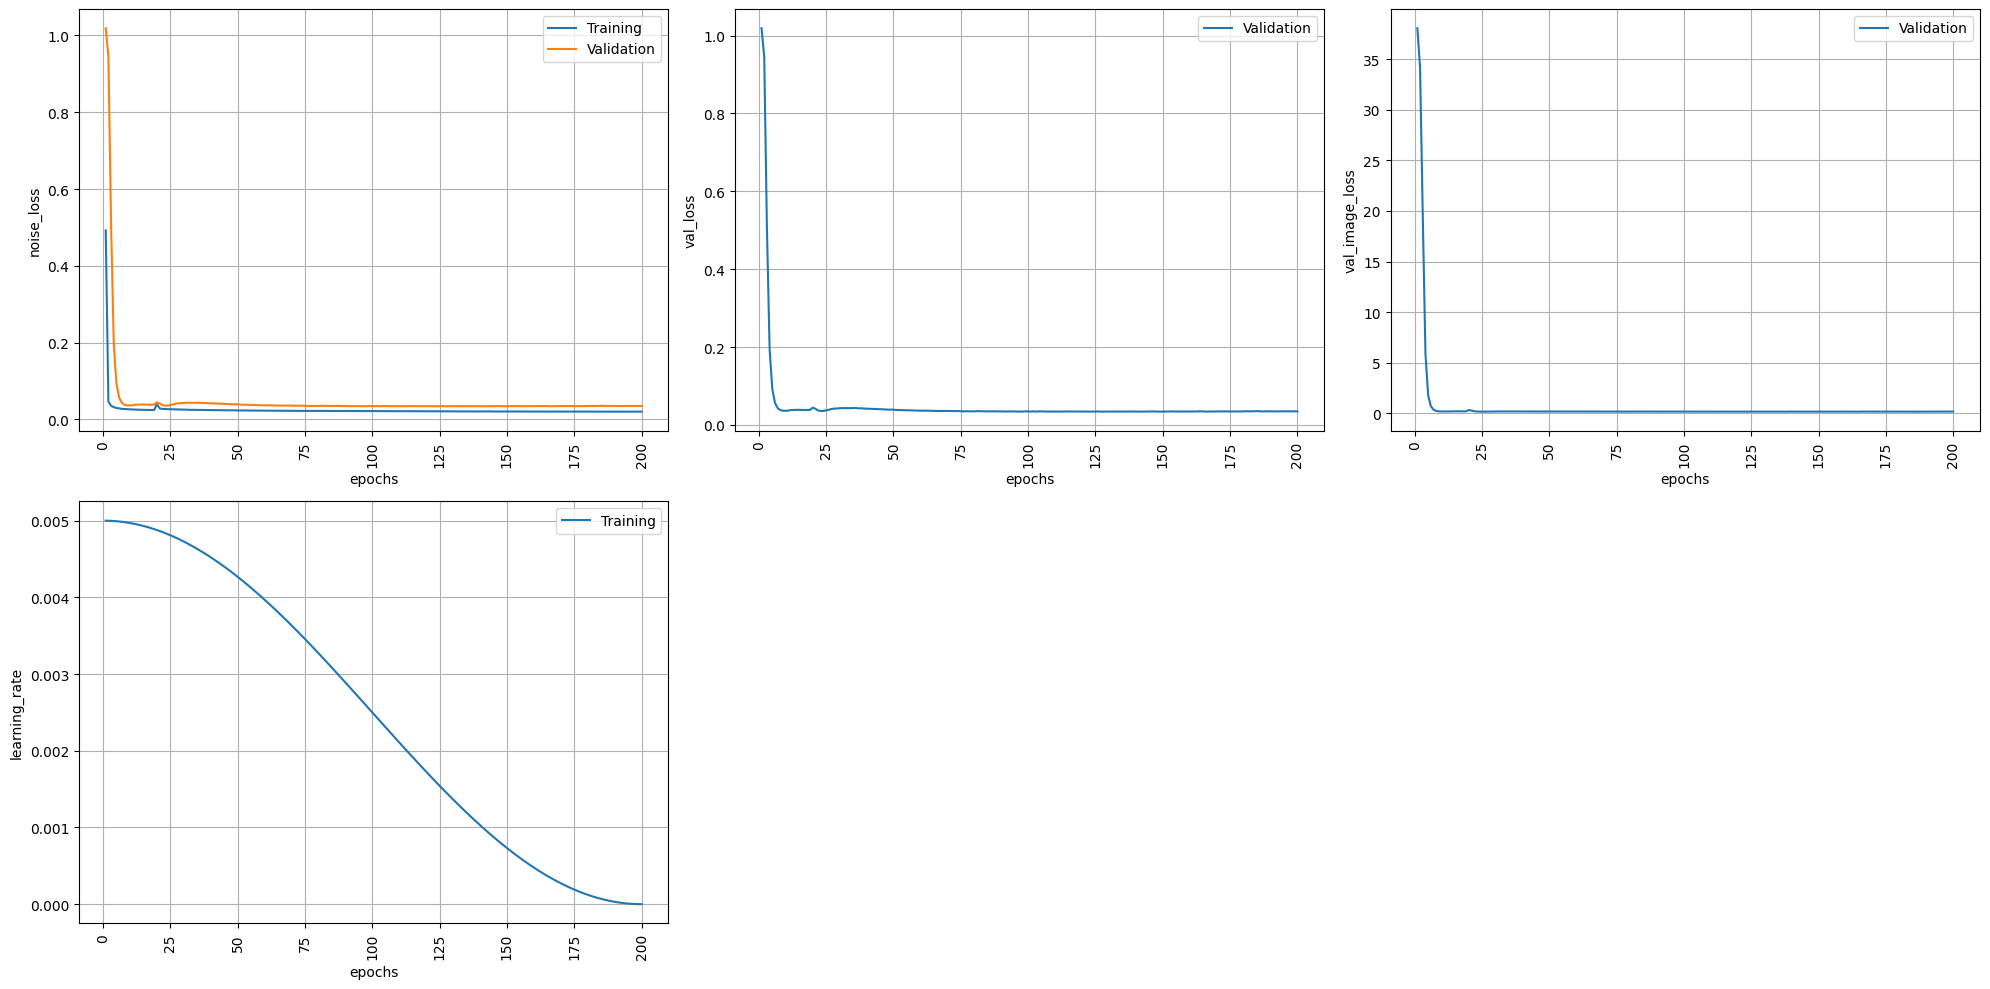

In [16]:
from common.utils import plot_history


plot_history(history)

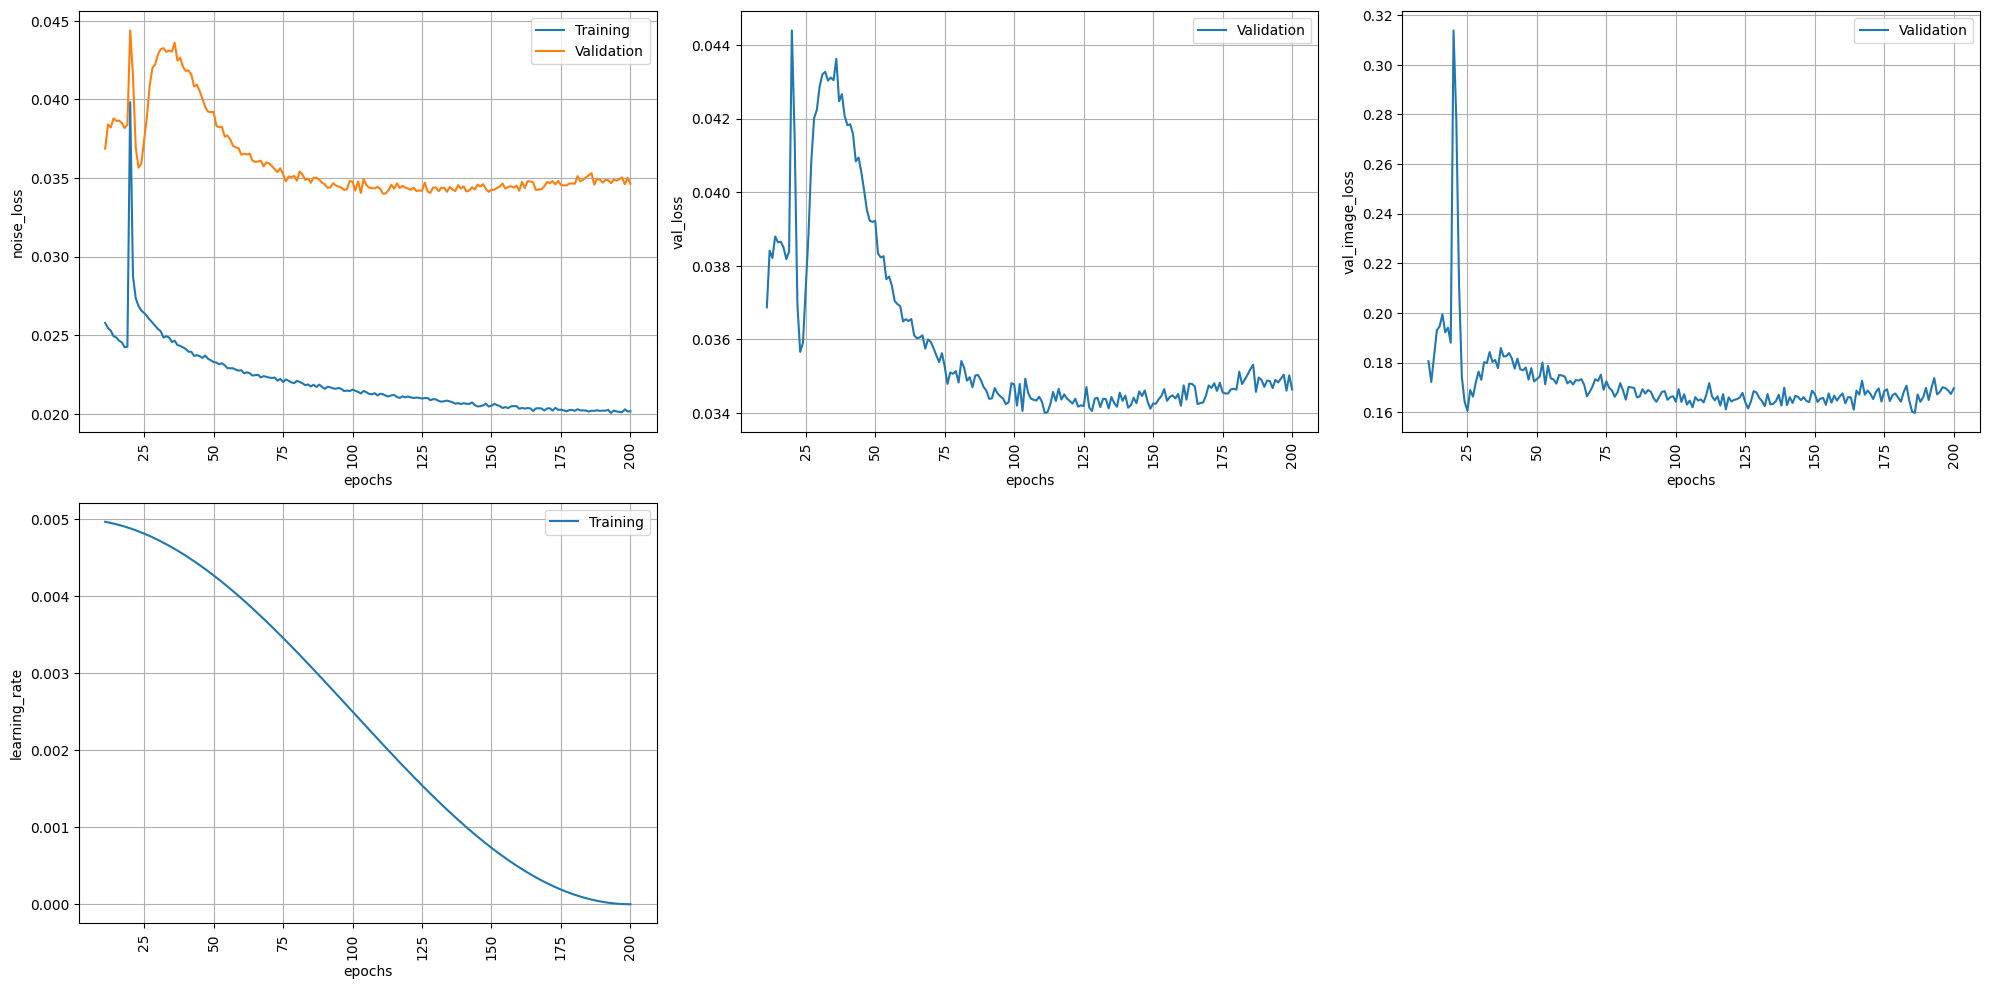

In [18]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))